# LMM-based Structured Data Extraction

This notebook uses large multimodal models (LMMs) to extract structured data from Colombian public procurement contracts (SECOP I). It benchmarks several OpenAI and Anthropic models on accuracy and cost, then applies the best-performing model to extract contract details at scale from ~15,000 procurement processes.

The notebook is organized in five phases:
1. **Dataset preparation** — annotated ground truth, PDF corpus reconciliation, and difficulty classification.
2. **Model benchmarking** — parallel extraction with OpenAI and Anthropic models against human-annotated labels.
3. **Detailed extraction** — full-schema contract extraction on the complete SECOP I corpus using the selected model.
4. **Auxiliary file triage** — prefix-based filtering and LLM triage of supplementary documents.
5. **Auxiliary extraction** — goods extraction from triaged auxiliary files.

## Setup

Standard library imports, visualization defaults, project path resolution, and environment variable loading. The project follows a fixed directory layout (`02-DATA_RAW`, `03-DATA_PROCESSED`, etc.) rooted two levels above this notebook.

### Imports and Configuration

Core libraries: `seaborn`/`matplotlib` for visualization, `pandas`/`numpy` for data manipulation, `fitz` (PyMuPDF) for PDF processing, `rich` for console formatting, `dotenv` for environment variables.

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import display, HTML
import matplotlib.ticker as mticker
from matplotlib import colors
import os
import base64
import re
from openai import OpenAI
from pathlib import Path
from pydantic import BaseModel, Field
from dotenv import load_dotenv
from rich.console import Console, Group
from rich.tree import Tree
from rich.markdown import Markdown
import pandas as pd
from typing import Optional, Any
import ast
import json
from joblib import Parallel, delayed
import numpy as np
from tqdm.auto import tqdm
import warnings; warnings.filterwarnings("ignore", "Using.*tqdm.autonotebook")
from tqdm_joblib import tqdm_joblib
import textwrap
from tenacity import retry, stop_after_attempt, wait_random_exponential, retry_if_exception, before_sleep_log, after_log, wait_fixed
import logging
from concurrent.futures import ThreadPoolExecutor, as_completed
from decimal import Decimal, ROUND_HALF_UP
import logging, os
from logging.handlers import RotatingFileHandler

import cv2
import fitz  # PyMuPDF
from pdfminer.high_level import extract_text


# ---- Safe Excel export (strips ALL XML-illegal characters) ----
import re as _re_xlsx

# Comprehensive pattern: control chars + Unicode non-characters
# (surrogates handled separately via encode/decode roundtrip)
_XLSX_UNSAFE_RE = _re_xlsx.compile(
    "["
    "\x00-\x08"       # C0 control chars (NUL through BS)
    "\x0b-\x0c"       # VT, FF
    "\x0e-\x1f"       # SO through US
    "\x7f"             # DEL
    "\x80-\x9f"       # C1 control chars
    "\ufdd0-\ufdef"   # Unicode non-characters
    "\ufffe-\uffff"   # Unicode non-characters
    "]"
)
_XLSX_MAX_CELL_LEN = 32_767  # Excel hard limit per cell

def _clean_cell(val: str) -> str:
    """Strip illegal XML chars, remove surrogates, and enforce Excel cell-length limit."""
    # First remove surrogates by encode/decode roundtrip
    val = val.encode("utf-8", errors="ignore").decode("utf-8")
    val = _XLSX_UNSAFE_RE.sub("", val)
    if len(val) > _XLSX_MAX_CELL_LEN:
        val = val[:_XLSX_MAX_CELL_LEN - 3] + "..."
    return val

def _safe_to_excel(df: pd.DataFrame, path, **kwargs) -> None:
    """Write DataFrame to Excel after stripping all XML-illegal characters
    and truncating cells that exceed Excel's 32,767-char limit."""
    df_clean = df.copy()
    for col in df_clean.select_dtypes(include="object").columns:
        df_clean[col] = df_clean[col].apply(lambda x: _clean_cell(x) if isinstance(x, str) else x)
    df_clean.to_excel(path, **kwargs)

In [2]:
path = Path().resolve()
root_path = path.parents[1]

In [3]:
def build_tree(base_path: Path, max_depth=10, current_depth=0, file_display_limit=2, folder_display_limit=None, root_path: Path = None):
    if root_path is None:
        root_path = base_path

    def add_branch(tree, path: Path, depth: int):
        if depth > max_depth:
            return

        entries = sorted([p for p in path.iterdir()])
        dirs = [p for p in entries if p.is_dir()]
        files = [p for p in entries if not p.is_dir()]

        # Limit folders shown at every level
        shown_dirs = dirs if folder_display_limit is None else dirs[:folder_display_limit]
        for d in shown_dirs:
            branch = tree.add(f"📂[bold]{d.name}[/]")
            add_branch(branch, d, depth + 1)
        if folder_display_limit is not None and len(dirs) > folder_display_limit:
            tree.add("📂[dim]...[/]")

        # Limit files shown
        for f in files[:file_display_limit]:
            tree.add(f.name)
        if len(files) > file_display_limit:
            tree.add("[dim]...[/]")

    # Build tree hierarchy from root_path down to base_path
    if base_path == root_path:
        tree = Tree(f"📂[bold]{base_path.name}/[/]")
        add_branch(tree, base_path, current_depth)
        return tree
    else:
        # Reconstruct tree from root to base_path
        relative_parts = base_path.relative_to(root_path).parts
        tree = Tree(f"📂[bold]{root_path.name}/[/]")
        cursor = tree
        current = root_path

        for part in relative_parts:
            current = current / part
            branch = cursor.add(f"📂[bold]{current.name}/[/]")
            cursor = branch

        # Now base_path == current; apply file/folder listing starting here
        add_branch(cursor, base_path, current_depth)
        return tree

In [4]:
max_depth = 1
project_tree = build_tree(root_path, max_depth=max_depth, file_display_limit=3)
console = Console()
console.print(Group(Markdown(f"# Project Structure ({max_depth+1} levels shown)")), project_tree)

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃                                       Project Structure (2 levels shown)                                        ┃
┗━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┛
📂03-Medidas_emergencia_CO/
├── 📂02-DATA_RAW
│   ├── 📂Manually_annotated_data
│   ├── 📂Precios unitarios
│   ├── 📂SECOP I
│   ├── 📂SECOP II
│   ├── 📂Webscraping
│   └── Tienda_Virtual_del_Estado_Colombiano_-_Consolidado.csv
├── 📂03-DATA_PROCESSED
│   ├── 📂SECOP_I
│   ├── 📂SECOP_II
│   ├── df_secop1_data.xlsx
│   ├── extraction_consolidated_dataset.xlsx
│   ├── extraction_goods_dataset.pkl
│   └── ...
├── 📂04-CODE
│   ├── 📂Base de reporte de precios y cantidades
│   └── 📂Base principal
├── 📂05-TABLES
├── 📂06-DATA_DOCUMENTATION
│   ├── 📂Clasificador bienes y servicios
│   ├── 📂Codigos de division política
│   ├── 📂Misc
│   ├── 📂Tipos de cambio
│   ├── DIVIPOLA.csv
│   └── DIVIPOLA.dta
├── .env
└── .gitignore

### Environment and Directory Layout

API keys are loaded from a `.env` file at the project root. All data paths follow a numbered directory convention (`02-DATA_RAW` for inputs, `03-DATA_PROCESSED` for outputs).

In [5]:
dotenv_path = root_path / ".env"
load_dotenv(dotenv_path)

True

In [6]:
data_raw_path = root_path / "02-DATA_RAW"
data_pro_path = root_path / "03-DATA_PROCESSED"
codes_path = root_path / "04-CODE"
tables_path = root_path / "05-TABLES"
docs_path = root_path / "06-DATA_DOCUMENTATION"

## Annotated Data from Previous Exercise

Five trained annotators independently reviewed a sample of SECOP I procurement processes and answered four binary questions per process:

1. **`es_bien`** — Whether the process involves the procurement of a physical good (as opposed to a service).
2. **`reporto_cantidades`** — Whether quantities are explicitly reported in the contract.
3. **`reporto_precio_sin_division`** — Whether unit prices are explicitly reported without requiring division.
4. **`precios_unitarios_con_division`** — Whether unit prices can be derived (e.g., total value ÷ quantity).

This annotated sample serves as the ground truth for evaluating LMM extraction accuracy. Each annotator processed a distinct subset; annotator-level breakdowns are used later to check for systematic disagreement.

### Loading the Annotated Dataset

Each annotator's responses are stored in a separate Excel file (`Procesamiento de los contratos - P*.xlsx`). These are concatenated into a single dataframe, cleaned of unnamed columns, and filtered to rows with a valid `estrato` field. The SECOP codename is extracted from the URL query parameter `numConstancia`.

In [7]:
previous_data = data_raw_path / "Manually_annotated_data"

In [8]:
excel_files = list(previous_data.glob("Procesamiento de los contratos - P*.xlsx"))
dfs = [pd.read_excel(f) for f in excel_files]
annotated_df = pd.concat(dfs, ignore_index=True)
annotated_df = annotated_df.loc[:, ~annotated_df.columns.str.contains('^Unnamed')]
annotated_df = annotated_df[annotated_df['estrato'].notna()].reset_index(drop=True)

In [9]:
def extract_rutaproceso(link):
    match = re.search(r'numConstancia=([^&]+)', link)
    return match.group(1) if match else None

annotated_df['rutaprocesoensecopi'] = annotated_df['Link'].apply(extract_rutaproceso)
annotated_df = annotated_df.dropna(subset=['rutaprocesoensecopi']).reset_index(drop=True)

In [10]:
annotated_df.sort_values(by='rutaprocesoensecopi', inplace=True)
annotated_df

,rutaprocesoensecopi,estrato,Persona,Link,¿Es un bien?,¿Tiene cantidades?,Reportó el precio (sin division),Se puede saber los precios unitarios con division
2961,19-1-197880,25.0,3.0,https://www.contratos.gov.co/consultas/detalle...,1,0.0,0.0,0.0
1730,19-1-198086,25.0,2.0,https://www.contratos.gov.co/consultas/detalle...,1,0.0,0.0,0.0
3416,19-1-203223,19.0,5.0,https://www.contratos.gov.co/consultas/detalle...,1,0.0,0.0,0.0
0,19-1-207657,1.0,1.0,https://www.contratos.gov.co/consultas/detalle...,1.0,1.0,0.0,1.0
3413,19-11-10098942,25.0,5.0,https://www.contratos.gov.co/consultas/detalle...,1,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...
1033,22-4-12655740,15.0,2.0,https://www.contratos.gov.co/consultas/detalle...,1,1.0,1.0,0.0
1628,22-4-12656149,3.0,2.0,https://www.contratos.gov.co/consultas/detalle...,1,1.0,1.0,0.0
4885,22-4-12658055,9.0,5.0,https://www.contratos.gov.co/consultas/detalle...,1,0.0,1.0,0.0
2505,22-4-12658777,15.0,3.0,https://www.contratos.gov.co/consultas/detalle...,1,1.0,1.0,0.0


Distribution of processes across annotators. Annotator-level breakdowns are used later to check whether agreement with LMM predictions varies systematically by annotator, which would indicate either annotation bias or difficulty imbalance in the assigned subsets.

In [11]:
annotated_df['Persona'].value_counts().sort_index()

Persona
1.0     289
2.0    1472
3.0    1473
4.0     179
5.0    1473
Name: count, dtype: int64

The raw document corpus was webscraped from the SECOP I URLs present in the annotated sample. Only PDF files are retained; other file formats (e.g., `.xls`, `.doc`) are excluded since the extraction pipeline is designed for multimodal PDF processing.

In [12]:
pdfs_dir = previous_data / "PDFs"
all_files = set(pdfs_dir.glob("*"))
pdf_files = set(pdfs_dir.glob("*.pdf"))

In [13]:
print(f"No. of raw files in the PDFs folder:    {len(all_files):,}")
print(f"    - No. of identified PDF files:      {len(pdf_files):,}")
print(f"    - No. of excluded non-pdf files:       {len(all_files - pdf_files):,}")
print(f"\nExcluded file extensions: {list({f.suffix for f in list(all_files - pdf_files)})}")
print(f"\nSubset of identified PDF files:")
[f.name for f in list(pdf_files)[:5]]

No. of raw files in the PDFs folder:    40,284
    - No. of identified PDF files:      40,178
    - No. of excluded non-pdf files:       106

Excluded file extensions: ['.xlsm', '.xls', '.tiff', '.ini', '.tif', '.mp3', '.xlsx']

Subset of identified PDF files:


['CAMC_PROCESO_20-13-11448149_28867813_82923519__20-13-11448149.pdf',
 'ADA_PROCESO_20-11-11287700_225288011_83236877__20-11-11287700.pdf',
 'DA_PROCESO_19-13-10038522_225841011_65697266__19-13-10038522.pdf',
 'DA_PROCESO_20-4-11335873_01002224_81459599__20-4-11335873.pdf',
 'DA_PROCESO_21-4-11903519_241676019_93014404__21-4-11903519.pdf']

Each PDF filename is parsed using a regex pattern to extract the codename (procurement process identifier) and the document role. The regex `C_(.*?)__(.*)\.pdf` captures two groups: the SECOP codename and the internal filename. Files starting with `C_PROCESO_` are contract documents; all others are auxiliary files.

The result is a structured dataset (`contracts_df`) mapping each codename to its list of contract candidate files and any supplementary documents.

In [14]:
data = {}

pattern = re.compile(r"C_(.*?)__(.*)\.(pdf)$", re.IGNORECASE)

for f in sorted(pdf_files, key=lambda p: (p.name.lower(), p.name)):
    filename = f.name
    match = pattern.match(filename)

    if match:
        codename = match.group(2)
        entry = data.setdefault(codename, {
            "codename": codename,
            "contract_candidates": [],
            "extra_file_paths": []
        })

        entry["contract_candidates"].append(filename)

    else:
        if "__" in filename:
            codename = filename.split("__")[1].rsplit(".", 1)[0]
            entry = data.setdefault(codename, {
                "codename": codename,
                "contract_candidates": [],
                "extra_file_paths": [],
            })
            entry["extra_file_paths"].append(filename)

contracts_df = pd.DataFrame(data.values())
contracts_df["num_additional_files"] = contracts_df["extra_file_paths"].apply(len)
contracts_df["num_contract_candidates"] = contracts_df["contract_candidates"].apply(len)
contracts_df["contract_candidates"] = contracts_df["contract_candidates"].apply(
    lambda x: x if len(x) > 0 else pd.NA
)
contracts_df["extra_file_paths"] = contracts_df["extra_file_paths"].apply(
    lambda x: x if len(x) > 0 else pd.NA
)


display(contracts_df)

files_accounted_for = contracts_df['num_additional_files'].sum() + contracts_df['num_contract_candidates'].sum()
unique_codenames = contracts_df['codename'].nunique()
unique_contracts = contracts_df.loc[contracts_df['num_contract_candidates'] > 0,"codename"].nunique()

print(f"No. of files accounter for:                                {files_accounted_for:,}")
print(f"No. of codenames identified:                                {unique_codenames:,}")
print(f"No. of codenames with at least one contract candidate:      {unique_contracts:,}")

,codename,contract_candidates,extra_file_paths,num_additional_files,num_contract_candidates
0,19-1-197880,[C_PROCESO_19-1-197880_225317011_55166262__19-...,[AA_PROCESO_19-1-197880_225317011_52937114__19...,28,1
1,19-1-198086,[C_PROCESO_19-1-198086_205490011_55109704__19-...,[AA_PROCESO_19-1-198086_205490011_53350407__19...,19,1
2,19-1-200503,[C_PROCESO_19-1-200503_273504011_58150518__19-...,[AA_PROCESO_19-1-200503_273504011_56461194__19...,12,1
3,19-1-203223,[C_PROCESO_19-1-203223_208638011_62412069__19-...,[AA_PROCESO_19-1-203223_208638011_60857218__19...,25,1
4,19-1-207657,[C_PROCESO_19-1-207657_28860313_68249258__19-1...,[AA_PROCESO_19-1-207657_28860313_67352388__19-...,5,1
...,...,...,...,...,...
7018,19-4-9328962,<NA>,[v2C_PROCESO_19-4-9328962_266001484_56917930__...,1,0
7019,19-4-9962353,<NA>,[v2C_PROCESO_19-4-9962353_121006003_64535559__...,1,0
7020,20-4-10521849,<NA>,[v2C_PROCESO_20-4-10521849_263001017_71590001_...,1,0
7021,20-4-10756760,<NA>,[v2C_PROCESO_20-4-10756760_223001727_74006500_...,2,0


No. of files accounter for:                                40,178
No. of codenames identified:                                7,023
No. of codenames with at least one contract candidate:      5,586


The file corpus contains more codenames than the annotated sample, so the two must be reconciled. This step counts how many codenames appear in the corpus but not in the annotated data (and vice versa) to quantify the mismatch before the inner join.

In [15]:
print("No. of codenames:")
print(f"    - identified from files that are not in the annotated dataframe:         {len(set(contracts_df['codename']) - set(annotated_df['rutaprocesoensecopi'])):,}")
print(f"    - identified from the annotated dataframe that are not in the files:        {len(set(annotated_df['rutaprocesoensecopi']) - set(contracts_df['codename'])):,}")

No. of codenames:
    - identified from files that are not in the annotated dataframe:         2,176
    - identified from the annotated dataframe that are not in the files:        39


Most mismatches are codenames present in the corpus but absent from the annotated data — likely caused by URLs that included files from neighbouring processes during webscraping. The reverse case (annotated but missing from the corpus) is negligible, meaning the annotated sample has near-complete coverage in the downloaded files.

## Systematic PDF difficulty classification

Each contract PDF is classified by difficulty using two criteria:

1. **Extractable text** (`has_readable_text`): whether the PDF yields more than 500 characters of extractable text.
2. **Contrast score** (`readability_score`): mean foreground-background contrast computed via adaptive thresholding on up to 3 rendered pages. Higher values indicate sharper, more legible documents.

These two axes produce a 2×2 classification (split at the median contrast score):

| Level | Extractable text | Contrast | Interpretation |
|-------|-----------------|----------|----------------|
| 1 | Yes | Above median | Clean, text-based PDF |
| 2 | No | Above median | High-contrast scan without embedded text |
| 3 | Yes | Below median | Text-based but low contrast |
| 4 | No | Below median | Low-quality scan, hardest to process |

Level 99 is assigned when the readability score could not be computed (e.g., corrupted files). The classification is applied separately to contract files and auxiliary files, then combined into a single `difficulty_level_both` column.

### Readability Scoring Functions

Three functions implement the difficulty classification:

1. **`readability_score_single_pdf`** — renders up to 3 pages at 220 DPI, converts to grayscale, applies adaptive thresholding, and computes the mean difference between background and foreground intensity.
2. **`readability_score`** — wrapper that averages scores across multiple PDFs for a given codename.
3. **`classify_pdf`** — combines text extraction (`fitz` text length > 500 chars) with the contrast score to produce the final difficulty classification.

In [16]:
def readability_score_single_pdf(pdf_path, dpi=220, max_pages=3):
    # Render scale: 72 dpi es base en PDF
    scale = dpi / 72.0

    try:
        doc = fitz.open(pdf_path)
        n_pages = doc.page_count
        if n_pages <= 0:
            doc.close()
            return np.nan

        if n_pages > max_pages:
            idxs0 = np.linspace(0, n_pages - 1, max_pages, dtype=int)
        else:
            idxs0 = np.arange(n_pages, dtype=int)

        scores = []

        for i in idxs0:
            page = doc.load_page(int(i))
            mat = fitz.Matrix(scale, scale)

            # Render a pixmap in RGB (no alpha) to avoid shape surprises
            pix = page.get_pixmap(matrix=mat, colorspace=fitz.csRGB, alpha=False)
            img = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, 3)

            gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

            gmin, gmax = int(gray.min()), int(gray.max())
            if gmin == gmax:
                scores.append(np.nan)
                continue

            bw = cv2.adaptiveThreshold(
                gray, 255,
                cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                cv2.THRESH_BINARY,
                35, 15
            )

            n_black = int((bw == 0).sum())
            n_white = int((bw == 255).sum())

            if n_black == 0 or n_white == 0:
                med = float(np.median(gray))
                bw = np.where(gray <= med, 0, 255).astype(np.uint8)

            fg = gray[bw == 0]
            bg = gray[bw == 255]

            if fg.size == 0 or bg.size == 0:
                scores.append(np.nan)
                continue

            contrast = (bg.mean() - fg.mean()) / 255.0
            scores.append(float(contrast))

        doc.close()

        if np.all(np.isnan(scores)):
            return float(0.0)
        return float(np.nanmean(scores))

    except Exception:
        try:
            doc.close()
        except Exception:
            pass
        return np.nan


In [17]:
def readability_score(contract_candidates, max_pdfs=100, **kwargs):
    """
    contract_candidates: list[str]
    Returns average readability score across a set of candidates.
    """

    rng = np.random.default_rng(42)  # fixed seed → replicable
    selected = rng.choice(
        contract_candidates,
        size=min(max_pdfs, len(contract_candidates)),
        replace=False
    )
    
    scores = [
        readability_score_single_pdf(p, **kwargs)
        for p in selected
    ]

    if np.all(np.isnan(scores)):
        return np.nan
    else:
        return float(np.nanmean(scores))

In [18]:
def classify_pdf(contract_candidates, min_chars=500):
    """
    Returns an object (dict) with:
    - has_readable_text (bool): True if any contract candidate has extractable text
    - readability_score (float) # average contrast metric averaged across candidates
    """
    
    has_readable_text = False
    for path in contract_candidates:
        try:
            text = extract_text(path)
            if len(text.strip()) > min_chars:
                has_readable_text = True
                break
        except Exception:
            continue

    score = readability_score(contract_candidates)

    return {
        "has_readable_text": bool(has_readable_text),
        "readability_score": np.nan if np.isnan(score) else float(score) 
    }

In [19]:
def classify_row(idx, contract_candidates):
    full_paths = [pdfs_dir / fn for fn in contract_candidates]
    out = classify_pdf(full_paths)
    return idx, out

In [20]:
contracts_df["has_readable_text"] = pd.Series(pd.NA, index=contracts_df.index, dtype="boolean")
contracts_df["readability_score"] = np.nan

tasks = [
    (idx, cands)
    for idx, cands in contracts_df["contract_candidates"].items()
    if cands is not pd.NA
]

cv2.setNumThreads(0)
cv2.ocl.setUseOpenCL(False)

with tqdm_joblib(desc="Classifying PDFs", total=len(tasks)) as bar:
    results = Parallel(n_jobs=8, backend="loky", batch_size=1, pre_dispatch=8)(
        delayed(classify_row)(idx, fn) for idx, fn in tasks
    )

for idx, out in results:
    contracts_df.at[idx, "has_readable_text"]  = out["has_readable_text"]
    contracts_df.at[idx, "readability_score"]  = out["readability_score"]

Classifying PDFs:   0%|          | 0/5586 [00:00<?, ?it/s]

c:\Users\matia\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [21]:
contracts_df["has_readable_" \
"text_extra_files"] = pd.Series(pd.NA, index=contracts_df.index, dtype="boolean")
contracts_df["readability_score_extra_files"] = np.nan

tasks = [
    (idx, cands)
    for idx, cands in contracts_df["extra_file_paths"].items()
    if cands is not pd.NA
]

cv2.setNumThreads(0)
cv2.ocl.setUseOpenCL(False)

with tqdm_joblib(desc="Classifying PDFs", total=len(tasks)) as bar:
    results = Parallel(n_jobs=8, backend="loky", batch_size=1, pre_dispatch=8)(
        delayed(classify_row)(idx, fn) for idx, fn in tasks
    )

for idx, out in results:
    contracts_df.at[idx, "has_readable_text_extra_files"]  = out["has_readable_text"]
    contracts_df.at[idx, "readability_score_extra_files"]  = out["readability_score"]

Classifying PDFs:   0%|          | 0/6264 [00:00<?, ?it/s]

c:\Users\matia\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Distribution of documents across the four difficulty levels, computed separately for contract files and auxiliary files. This breakdown informs expectations about extraction difficulty: level 1 (clean text-based PDFs) should yield high accuracy, while level 4 (low-quality scans without embedded text) may require more robust multimodal processing.

### Compute Difficulty Levels

The readability scores are split at the median contrast value. Combined with the `has_readable_text` flag, this produces four difficulty levels. Level 99 is assigned when computation failed (corrupted files).

In [22]:
contracts_df

,codename,contract_candidates,extra_file_paths,num_additional_files,num_contract_candidates,has_readable_text,readability_score,has_readable_text_extra_files,readability_score_extra_files
0,19-1-197880,[C_PROCESO_19-1-197880_225317011_55166262__19-...,[AA_PROCESO_19-1-197880_225317011_52937114__19...,28,1,True,0.842125,True,0.798969
1,19-1-198086,[C_PROCESO_19-1-198086_205490011_55109704__19-...,[AA_PROCESO_19-1-198086_205490011_53350407__19...,19,1,False,0.765993,True,0.708067
2,19-1-200503,[C_PROCESO_19-1-200503_273504011_58150518__19-...,[AA_PROCESO_19-1-200503_273504011_56461194__19...,12,1,True,0.822915,True,0.770246
3,19-1-203223,[C_PROCESO_19-1-203223_208638011_62412069__19-...,[AA_PROCESO_19-1-203223_208638011_60857218__19...,25,1,False,0.819309,True,0.758307
4,19-1-207657,[C_PROCESO_19-1-207657_28860313_68249258__19-1...,[AA_PROCESO_19-1-207657_28860313_67352388__19-...,5,1,False,0.580419,False,0.618727
...,...,...,...,...,...,...,...,...,...
7018,19-4-9328962,<NA>,[v2C_PROCESO_19-4-9328962_266001484_56917930__...,1,0,<NA>,NaN,False,0.313341
7019,19-4-9962353,<NA>,[v2C_PROCESO_19-4-9962353_121006003_64535559__...,1,0,<NA>,NaN,True,0.803155
7020,20-4-10521849,<NA>,[v2C_PROCESO_20-4-10521849_263001017_71590001_...,1,0,<NA>,NaN,False,0.890832
7021,20-4-10756760,<NA>,[v2C_PROCESO_20-4-10756760_223001727_74006500_...,2,0,<NA>,NaN,True,0.805767


In [23]:
median_score = pd.concat([contracts_df["readability_score"], contracts_df["readability_score_extra_files"]]).median(skipna=True)
contracts_df["difficulty_level_contracts"] = np.nan
contracts_df["difficulty_level_extra"] = np.nan

contracts_df.loc[
    (contracts_df["has_readable_text"] == True) &
    (contracts_df["readability_score"] > median_score),
    "difficulty_level_contracts"
] = 1

contracts_df.loc[
    (contracts_df["has_readable_text"] == False) &
    (contracts_df["readability_score"] > median_score),
    "difficulty_level_contracts"
] = 2

contracts_df.loc[
    (contracts_df["has_readable_text"] == True) &
    (contracts_df["readability_score"] <= median_score),
    "difficulty_level_contracts"
] = 3

contracts_df.loc[
    (contracts_df["has_readable_text"] == False) &
    (contracts_df["readability_score"] <= median_score),
    "difficulty_level_contracts"
] = 4

contracts_df.loc[
    (contracts_df["contract_candidates"].notna()) &
    (contracts_df["readability_score"].isna()),
    "difficulty_level_contracts"
] = 99

# mask_needs_override = contracts_df["difficulty_level"].isna() | (contracts_df["difficulty_level"] == 99)

contracts_df.loc[
    (contracts_df["has_readable_text_extra_files"] == True) &
    (contracts_df["readability_score_extra_files"] > median_score),
    "difficulty_level_extra"
] = 1

contracts_df.loc[
    (contracts_df["has_readable_text_extra_files"] == False) &
    (contracts_df["readability_score_extra_files"] > median_score),
    "difficulty_level_extra"
] = 2

contracts_df.loc[
    (contracts_df["has_readable_text_extra_files"] == True) &
    (contracts_df["readability_score_extra_files"] <= median_score),
    "difficulty_level_extra"
] = 3

contracts_df.loc[
    (contracts_df["has_readable_text_extra_files"] == False) &
    (contracts_df["readability_score_extra_files"] <= median_score),
    "difficulty_level_extra"
] = 4

contracts_df.loc[
    (contracts_df["extra_file_paths"].notna()) &
    (contracts_df["readability_score_extra_files"].isna()),
    "difficulty_level_extra"
] = 99

contracts_df["difficulty_level_both"] = contracts_df["difficulty_level_contracts"]

mask_update = (
    contracts_df["difficulty_level_both"].isna() |
    (contracts_df["difficulty_level_both"] == 99)
) & contracts_df["difficulty_level_extra"].notna()

contracts_df.loc[mask_update, "difficulty_level_both"] = (
    contracts_df.loc[mask_update, "difficulty_level_extra"]
)

In [24]:
diff_lvl_dist = pd.concat(
    [
        contracts_df["difficulty_level_contracts"].value_counts().sort_index(),
        contracts_df["difficulty_level_extra"].value_counts().sort_index(),
        contracts_df["difficulty_level_both"].value_counts().sort_index(),
    ],
    axis=1
)

diff_lvl_dist.columns = [
    "contracts",
    "extra",
    "both"
]

diff_lvl_dist

,contracts,extra,both
1.0,1871,2337,2460
2.0,980,693,1070
3.0,548,1484,1073
4.0,2155,1695,2357
99.0,32,55,63


## Construction of the Master Testing Dataframe

The master testing dataframe merges the annotated data with the file corpus via an inner join on the codename field. Only observations present in both sources, with a valid contract path and no corrupted PDFs, are retained. This produces the final evaluation set used for benchmarking all models.

Observations are excluded if:
- The codename has no matching contract file in the corpus.
- The contract PDF is corrupted or unreadable.
- The codename appears in the corpus but not in the annotated sample.

### Merge and Filter

Inner join between the file corpus and the annotated data on the codename field, followed by exclusion of observations without a valid contract path.

In [26]:
master_df = contracts_df.merge(
    annotated_df,
    left_on="codename",
    right_on="rutaprocesoensecopi",
    how="inner",
    indicator=True
)

master_df['¿Es un bien?'] = master_df['¿Es un bien?'].astype(str).str.extract(r'(\d+)').astype(float)

master_df = master_df.rename(columns={
    '¿Es un bien?': 'es_bien',
    '¿Tiene cantidades?': 'reporto_cantidades',
    'Reportó el precio (sin division)': 'reporto_precio_sin_division',
    'Se puede saber los precios unitarios con division': 'precios_unitarios_con_division'
})

display(master_df)

,codename,contract_candidates,extra_file_paths,num_additional_files,num_contract_candidates,has_readable_text,readability_score,has_readable_text_extra_files,readability_score_extra_files,difficulty_level_contracts,...,difficulty_level_both,rutaprocesoensecopi,estrato,Persona,Link,es_bien,reporto_cantidades,reporto_precio_sin_division,precios_unitarios_con_division,_merge
0,19-1-197880,[C_PROCESO_19-1-197880_225317011_55166262__19-...,[AA_PROCESO_19-1-197880_225317011_52937114__19...,28,1,True,0.842125,True,0.798969,1.0,...,1.0,19-1-197880,25.0,3.0,https://www.contratos.gov.co/consultas/detalle...,1.0,0.0,0.0,0.0,both
1,19-1-198086,[C_PROCESO_19-1-198086_205490011_55109704__19-...,[AA_PROCESO_19-1-198086_205490011_53350407__19...,19,1,False,0.765993,True,0.708067,2.0,...,2.0,19-1-198086,25.0,2.0,https://www.contratos.gov.co/consultas/detalle...,1.0,0.0,0.0,0.0,both
2,19-1-203223,[C_PROCESO_19-1-203223_208638011_62412069__19-...,[AA_PROCESO_19-1-203223_208638011_60857218__19...,25,1,False,0.819309,True,0.758307,2.0,...,2.0,19-1-203223,19.0,5.0,https://www.contratos.gov.co/consultas/detalle...,1.0,0.0,0.0,0.0,both
3,19-1-207657,[C_PROCESO_19-1-207657_28860313_68249258__19-1...,[AA_PROCESO_19-1-207657_28860313_67352388__19-...,5,1,False,0.580419,False,0.618727,4.0,...,4.0,19-1-207657,1.0,1.0,https://www.contratos.gov.co/consultas/detalle...,1.0,1.0,0.0,1.0,both
4,19-11-10098942,[C_PROCESO_19-11-10098942_254000001_68167892__...,[AA_PROCESO_19-11-10098942_254000001_66974835_...,17,1,False,0.656955,True,0.739652,4.0,...,4.0,19-11-10098942,25.0,5.0,https://www.contratos.gov.co/consultas/detalle...,1.0,1.0,1.0,0.0,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4842,21-4-12555653,<NA>,[DP_PROCESO_21-4-12555653_285300019_96920429__...,1,0,<NA>,NaN,False,0.585302,NaN,...,4.0,21-4-12555653,3.0,1.0,https://www.contratos.gov.co/consultas/detalle...,1.0,1.0,1.0,0.0,both
4843,20-13-11429577,<NA>,[OSMC_PROCESO_20-13-11429577_28887360_82661750...,1,0,<NA>,NaN,False,NaN,NaN,...,99.0,20-13-11429577,2.0,1.0,https://www.contratos.gov.co/consultas/detalle...,1.0,1.0,1.0,0.0,both
4844,19-4-9270542,<NA>,[v2C_PROCESO_19-4-9270542_270418017_56330105__...,1,0,<NA>,NaN,True,0.783000,NaN,...,1.0,19-4-9270542,7.0,3.0,https://www.contratos.gov.co/consultas/detalle...,1.0,1.0,1.0,0.0,both
4845,20-4-10756760,<NA>,[v2C_PROCESO_20-4-10756760_223001727_74006500_...,2,0,<NA>,NaN,True,0.805767,NaN,...,1.0,20-4-10756760,14.0,5.0,https://www.contratos.gov.co/consultas/detalle...,0.0,0.0,0.0,0.0,both


In [27]:
total_master = len(contracts_df)
matched = (master_df["_merge"] == "both").sum()
no_contract = master_df['contract_candidates'].isna().sum()
corrupt_pdf = (master_df['difficulty_level_contracts'] == 99).sum()
viable_codenames = (master_df["contract_candidates"].notna() & 
                    master_df['difficulty_level_contracts'].isin([1,2,3,4])).sum()
viable_codenames_all = (master_df['difficulty_level_both'].isin([1,2,3,4])).sum()
corrupt_pdf_all = (master_df['difficulty_level_both'] == 99).sum()

print(f"Matched in both:                                                                                {matched:,}")
print(f"  - No. of codenames that do not have contract candidate PDFs:                                    {no_contract:,}")
print(f"  - No. of codenames with broken PDF file as contract:                                             {corrupt_pdf:,}")
print(f"  - No. of viable observations for performance testing using contracts only:                    {viable_codenames:,}")

print(f"\n  - No. of viable obs. using either contracts or additional files:                              {viable_codenames_all:,}")
print(f"  - No. of codenames without any usable PDF files in both contracts or additional files:           {corrupt_pdf_all:,}")

Matched in both:                                                                                4,847
  - No. of codenames that do not have contract candidate PDFs:                                    928
  - No. of codenames with broken PDF file as contract:                                             23
  - No. of viable observations for performance testing using contracts only:                    3,896

  - No. of viable obs. using either contracts or additional files:                              4,813
  - No. of codenames without any usable PDF files in both contracts or additional files:           34


Difficulty level distribution recalculated on the eligible observations only (after filtering out missing contracts and corrupted files). This final distribution determines how many documents per difficulty level are included in the benchmarking runs.

In [28]:
diff_lvl_dist_post = pd.concat(
    [
        master_df.loc[ 
            master_df['difficulty_level_contracts'].isin([1,2,3,4]),
            'difficulty_level_contracts'
        ].value_counts().sort_index(),
        master_df.loc[ 
            master_df['difficulty_level_extra'].isin([1,2,3,4]),
            'difficulty_level_extra'
        ].value_counts().sort_index(),
        master_df.loc[ 
            master_df['difficulty_level_both'].isin([1,2,3,4]),
            'difficulty_level_both'
        ].value_counts().sort_index(),
    ],
    axis=1
)

diff_lvl_dist_post.columns = [
    "contracts",
    "extra",
    "both"
]

diff_lvl_dist_post

,contracts,extra,both
1.0,1324,1629,1722
2.0,680,480,726
3.0,393,1039,759
4.0,1499,1151,1606


## Summary Table of Dataset Prep

### Dataset Summary

Final counts at each filtering stage, from the raw annotated sample through reconciliation, corruption filtering, and difficulty classification. The last rows show the distribution of the four annotation variables across eligible observations.

In [29]:
NBSP = "\u00A0"
ind = lambda n: NBSP * (6*n)

data = [
    ("No. of codenames in annotated data", annotated_df['rutaprocesoensecopi'].nunique(), True),
    ("", np.nan, False),
    # ("No. of scraped raw files from process URLs", len(all_files), True),
    # (ind(1) + "No. of excluded non-pdf files", len(all_files - pdf_files), False),
    # (ind(1) + "No. of identified PDF files", len(pdf_files), False),
    # ("", np.nan, False),
    ("No. of codenames identified from PDF corpus", unique_codenames, True),
    (ind(1) + "No. of codenames that have PDF files other than contract", (unique_codenames - unique_contracts), False),
    (ind(1) + "No. of codenames that have contract PDF file", unique_contracts, False),
    # (ind(2) + "No. of contracts classified: difficulty level #1", diff_lvl_dist_pre.loc[1], False),
    # (ind(2) + "No. of contracts classified: difficulty level #2", diff_lvl_dist_pre.loc[2], False),
    # (ind(2) + "No. of contracts classified: difficulty level #3", diff_lvl_dist_pre.loc[3], False),
    # (ind(2) + "No. of contracts classified: difficulty level #4", diff_lvl_dist_pre.loc[4], False),
    # (ind(2) + "No. of codenames with corrupt/broken PDF file as contract", diff_lvl_dist_pre.loc[99], False),
    # ("", np.nan, False),
    # ("No. of codenames identified from files that are not in annotated data", (len(set(contracts_df['codename']) - set(annotated_df['rutaprocesoensecopi']))), False),
    # ("No. of codenames identified from the annotated data that are not in files", (len(set(annotated_df['rutaprocesoensecopi']) - set(contracts_df['codename']))), False),
    ("", np.nan, False),
    ("No. of codenames present in both data sources", matched, True),
    (ind(1) + "No. of codenames that do not have contract", no_contract, False),
    (ind(1) + "No. of codenames with corrupt/broken PDF file as contract", corrupt_pdf, False),
    (ind(1) + "No. of viable observations for validation", viable_codenames, True),
    # (ind(2) + "No. of contracts classified: difficulty level #1", diff_lvl_dist_post.loc[1], False),
    # (ind(2) + "No. of contracts classified: difficulty level #2", diff_lvl_dist_post.loc[2], False),
    # (ind(2) + "No. of contracts classified: difficulty level #3", diff_lvl_dist_post.loc[3], False),
    # (ind(2) + "No. of contracts classified: difficulty level #4", diff_lvl_dist_post.loc[4], False),
]

df = pd.DataFrame(data, columns=["Metric", "Count", "Header"])

def row_style(row):
    if row["Metric"] == "":  # blank spacer rows
        return ["height: 10px;", "height: 10px;", ""]
    if row["Header"]:
        return [
            "font-weight: bold; text-align: left;",
            "font-weight: bold; text-align: right;",
            ""
        ]
    return ["text-align: left;", "text-align: right;", ""]

styled = (
    df.style
      .format({"Count": lambda x: f"{x:,.0f}" if pd.notna(x) else ""}, escape=None)  # do NOT escape HTML
      .apply(row_style, axis=1)
      .hide(axis="columns", subset=["Header"])
      .hide(axis="index")
      .set_table_attributes('style="width:100%; table-layout:fixed; margin-left:auto; margin-right:auto; max-width:700px" id="tbl1"')
      .set_table_styles([
          {"selector": "thead th",
           "props": [("border-bottom", "2px solid black"),
                     ("text-align", "center"),
                     ("font-weight", "bold")]},
          {"selector": "tbody td:first-child, thead th:first-child", "props": [("width", "80%"), ("text-align", "left")]},
          {"selector": "tbody td:nth-child(2), thead th:nth-child(2)", "props": [("width", "20%"), ("text-align", "right")]},
      ])
      .set_caption("Table 1. Construction of the validation dataset from annotated data and scraped files")
)

styled.set_table_styles(
    [{"selector": "caption",
      "props": [("caption-side", "top"),
                ("text-align", "center"),
                ("font-size", "120%"),
                ("font-weight", "bold"),
                ("padding", "1.5em 0")]}],
    overwrite=False
)

styled

Metric,Count
No. of codenames in annotated data,"4,886"
,
No. of codenames identified from PDF corpus,"7,023"
No. of codenames that have PDF files other than contract,"1,437"
No. of codenames that have contract PDF file,"5,586"
,
No. of codenames present in both data sources,"4,847"
No. of codenames that do not have contract,928
No. of codenames with corrupt/broken PDF file as contract,23
No. of viable observations for validation,"3,896"


In [30]:
variables = ['es_bien', 'reporto_cantidades', 'reporto_precio_sin_division', 'precios_unitarios_con_division']

viable = (master_df["contract_candidates"].notna() & master_df["difficulty_level_contracts"].isin([1, 2, 3, 4]))
summary = pd.DataFrame({
    "Variable": variables,
    "Non miss. obs.": [master_df[viable][v].notna().sum() for v in variables],
    "Num. of 1s": [int(master_df[viable][v].sum()) for v in variables],
    "Pctg. of 1s": [master_df[viable][v].mean()*100 for v in variables],
    "Num. of missing": [master_df[viable][v].isna().sum() for v in variables]
}).round({"Pctg. of 1s": 2})

styled_summary = (
    summary.style
        .format({
            "Non miss. obs.": lambda x: f"{x:,.0f}" if pd.notna(x) else "",
            "Num. of 1s": lambda x: f"{x:,.0f}" if pd.notna(x) else "",
            "Pctg. of 1s": lambda x: f"{x:,.1f}%" if pd.notna(x) else "",
            "Num. of missing": lambda x: f"{x:,.0f}" if pd.notna(x) else "",
        }, escape=None)
        .hide(axis="index")
        .set_table_attributes('style="width:100%; table-layout:fixed; margin-left:auto; margin-right:auto; max-width:700px" id="tbl_var_summary"')
        .set_table_styles([
            {"selector": "thead th",
             "props": [("border-bottom", "2px solid black"),
                       ("text-align", "center"),
                       ("font-weight", "bold")]},
            {"selector": "tbody td:first-child, thead th:first-child", "props": [("text-align", "left"), ("width", "40%")]},
            {"selector": "tbody td:nth-child(n+2), thead th:nth-child(n+2)", "props": [("text-align", "right")]},
        ])
        .set_caption("Table 2. Summary of binary validation variables")
)

styled_summary.set_table_styles(
    [{"selector": "caption",
      "props": [("caption-side", "top"),
                ("text-align", "center"),
                ("font-size", "120%"),
                ("font-weight", "bold"),
                ("padding", "1.5em 0")]}],
    overwrite=False
)

styled_summary


Variable,Non miss. obs.,Num. of 1s,Pctg. of 1s,Num. of missing
es_bien,"3,895","3,311",85.0%,1
reporto_cantidades,"3,896","2,827",72.6%,0
reporto_precio_sin_division,"3,895","2,385",61.2%,1
precios_unitarios_con_division,"3,895",408,10.5%,1


## OpenAI Models' Validation Extraction

Each OpenAI model is tasked with extracting structured answers to the four annotation questions from eligible contract PDFs. The extracted binary variables are compared directly with human labels to compute per-variable and per-model accuracy rates. This enables model selection based on both accuracy and cost.

### Setup

Logging configuration with rotating file handler, followed by OpenAI client initialization.

In [20]:
LOGFILE = "openai_extraction.log"

retry_logger = logging.getLogger("retry")
retry_logger.setLevel(logging.INFO)
retry_logger.propagate = False

retry_logger.handlers.clear()

fh = RotatingFileHandler(LOGFILE, maxBytes=2_000_000, backupCount=3, encoding="utf-8")
fh.setFormatter(logging.Formatter("%(asctime)s | %(name)s | %(levelname)s | %(message)s"))
retry_logger.addHandler(fh)

In [21]:
client = OpenAI()

Utility class for tracking token usage and computing API costs per extraction call. Separates input, cached, and output tokens, and applies per-model pricing to compute the dollar cost of each API call. This is used across all extraction functions to accumulate total spend.

In [22]:
class CostBreakdown(BaseModel):
    input_tokens: int
    cached_input_tokens: int
    billable_input_tokens: int
    output_tokens: int
    cost_input_usd: float
    cost_cached_input_usd: float
    cost_output_usd: float

    @property
    def total_usd(self) -> float:
        return round(self.cost_input_usd + self.cost_cached_input_usd + self.cost_output_usd,6)

    def pretty(self) -> str:
        lines = [
            "┌─ Cost breakdown ──────────────────────────────",
            f"│ Total:        {self.total_usd:.6f}$",
            f"│ Input tokens: {self.input_tokens}",
            f"│   Cached:     {self.cached_input_tokens} → {self.cost_cached_input_usd:.6f}$",
            f"│   Billable:   {self.billable_input_tokens} → {self.cost_input_usd:.6f}$",
            f"│ Output:       {self.output_tokens} → {self.cost_output_usd:.6f}$",
            "└───────────────────────────────────────────────",
        ]
        return "\n".join(lines)

### Model Pricing

Per-million token costs for each model, scraped from OpenAI's pricing page using Selenium. The scraper renders the pricing page in a headless Chrome instance, parses the pricing table, and extracts input, cached input, and output costs per model. These rates are used by `CostBreakdown` to compute per-call and total extraction costs.

In [23]:
import re
import time
from bs4 import BeautifulSoup
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.common.by import By

URL = "https://platform.openai.com/docs/pricing"
HTML_DEBUG_PATH = "pricing_debug.html"

def money(s: str):
    s = s.strip()
    return None if s in {"-", "\ufffd"} else float(s.replace("$", "").replace(",", ""))

is_token_price = lambda s: bool(re.fullmatch(r"\$?\d+(?:\.\d+)?|-|\ufffd", s.strip()))

opts = Options()
opts.add_argument("--window-size=1400,900")

driver = webdriver.Chrome(options=opts)
wait = WebDriverWait(driver, 120)

try:
    driver.get(URL)
    wait.until(lambda d: len(d.find_elements(By.CSS_SELECTOR, "table")) > 0)

    # Find the Standard section marker, then its All models button
    try:
        std_el = driver.find_element(By.XPATH,
            '//div[contains(@class,"hidden") and normalize-space()="Standard"]')
        panel = std_el.find_element(By.XPATH, '..')
        view_btn = panel.find_element(By.XPATH,
            './/button[.//span[normalize-space()="All models"]]')
        driver.execute_script("arguments[0].scrollIntoView(true);", view_btn)
        time.sleep(0.5)
        driver.execute_script("arguments[0].click();", view_btn)
        time.sleep(2)
    except Exception:
        pass

    html = driver.page_source

    soup = BeautifulSoup(html, "html.parser")

    std_marker = soup.find(
        "div",
        class_="hidden",
        string=re.compile(r"^\s*Standard\s*$", re.I)
    )
    if not std_marker:
        raise RuntimeError("Could not find <div class='hidden'>Standard</div>.")

    # Find the 4-col expanded table in the Standard panel
    panel = std_marker.parent
    candidates = panel.find_all("table") if panel else [std_marker.find_next("table")]

    standard_table = None
    for t in candidates:
        ths = [th.get_text(strip=True).lower() for th in t.select("thead tr:last-child th")]
        if ths[:4] == ["model", "input", "cached input", "output"] and len(ths) == 4:
            standard_table = t
            break

    if not standard_table:
        raise RuntimeError("Could not find 4-column Standard pricing table. "
                           "All models button may not have expanded.")

    MODEL_PRICING = {}
    for tr in standard_table.select("tbody tr"):
        tds = [td.get_text(strip=True) for td in tr.find_all("td")]
        if len(tds) != 4:
            continue
        model, inp, cached, out = tds

        if not (is_token_price(inp) and is_token_price(cached) and is_token_price(out)):
            continue
        if "$" not in (inp + cached + out):
            continue

        MODEL_PRICING[model] = {
            "input_per_million": money(inp),
            "cached_input_per_million": money(cached),
            "output_per_million": money(out),
        }

    MODEL_PRICING

finally:
    driver.quit()


In [24]:
MODEL_PRICING

{'gpt-5.2': {'input_per_million': 1.75,
  'cached_input_per_million': 0.175,
  'output_per_million': 14.0},
 'gpt-5.2-pro': {'input_per_million': 21.0,
  'cached_input_per_million': None,
  'output_per_million': 168.0},
 'gpt-5.1': {'input_per_million': 1.25,
  'cached_input_per_million': 0.125,
  'output_per_million': 10.0},
 'gpt-5': {'input_per_million': 1.25,
  'cached_input_per_million': 0.125,
  'output_per_million': 10.0},
 'gpt-5-mini': {'input_per_million': 0.25,
  'cached_input_per_million': 0.025,
  'output_per_million': 2.0},
 'gpt-5-nano': {'input_per_million': 0.05,
  'cached_input_per_million': 0.005,
  'output_per_million': 0.4},
 'gpt-5-pro': {'input_per_million': 15.0,
  'cached_input_per_million': None,
  'output_per_million': 120.0},
 'gpt-4.1': {'input_per_million': 2.0,
  'cached_input_per_million': 0.5,
  'output_per_million': 8.0},
 'gpt-4.1-mini': {'input_per_million': 0.4,
  'cached_input_per_million': 0.1,
  'output_per_million': 1.6},
 'gpt-4.1-nano': {'inpu

### Cost Computation Utilities

Helper functions for computing per-call costs from API usage objects. `_usd` converts token counts to dollars using the per-model pricing table. `_normalize_usage` handles differences between response formats (dict, Pydantic model, named tuple). `_compute_cost_from_usage` produces a full `CostBreakdown` with separate input, cached, and output cost components.

In [25]:
def _usd(cost_per_million, tokens):
    val = (Decimal(str(cost_per_million)) / Decimal(1_000_000)) * Decimal(tokens)
    return float(val.quantize(Decimal("0.000001"), rounding=ROUND_HALF_UP))

In [26]:
def _normalize_usage(usage_obj):
    if usage_obj is None:
        return {}
    if isinstance(usage_obj, dict):
        return usage_obj
    if hasattr(usage_obj, "model_dump"):
        return usage_obj.model_dump()
    if hasattr(usage_obj, "to_dict"):
        return usage_obj.to_dict()
    keys = ("input_tokens","output_tokens","prompt_tokens","completion_tokens",
            "prompt_tokens_details","input_tokens_details")
    return {k: getattr(usage_obj, k) for k in keys if hasattr(usage_obj, k)}

In [27]:
def _compute_cost_from_usage(usage: dict, model: str) -> CostBreakdown:
    input_tokens  = usage.get("input_tokens", 0) or usage.get("prompt_tokens", 0) or 0
    output_tokens = usage.get("output_tokens", 0) or usage.get("completion_tokens", 0) or 0
    details = usage.get("prompt_tokens_details") or usage.get("input_tokens_details") or {}
    cached = details.get("cached_tokens", 0) or 0
    billable_input = max(input_tokens - cached, 0)

    cost_input  = _usd(MODEL_PRICING[model]["input_per_million"], billable_input)
    cost_cached = _usd(MODEL_PRICING[model].get("cached_input_per_million", MODEL_PRICING[model]["input_per_million"]), cached)
    cost_output = _usd(MODEL_PRICING[model]["output_per_million"], output_tokens)

    return CostBreakdown(
        input_tokens=input_tokens,
        cached_input_tokens=cached,
        billable_input_tokens=billable_input,
        output_tokens=output_tokens,
        cost_input_usd=cost_input,
        cost_cached_input_usd=cost_cached,
        cost_output_usd=cost_output,
    )

Retry logic for transient API errors (rate limits, timeouts, server errors). Uses `tenacity` with exponential backoff (multiplier=1, min=5s, max=20s) and a cap of 10 attempts. Non-retryable errors (e.g., unsupported file format, 400 bad requests) are excluded to fail fast on permanent errors.

In [28]:
def _is_retryable(exc: Exception) -> bool:
    try:
        import openai 
        if isinstance(
            exc, 
            (
            openai.RateLimitError,
            openai.APIConnectionError,
            openai.APITimeoutError,
            openai.InternalServerError,
            openai.APIError,
            )
        ):
            return True
    except Exception:
        pass

    try:
        import httpx 
        if isinstance(
            exc,
            (
                httpx.ConnectError,
                httpx.ReadTimeout,
                httpx.WriteError,
                httpx.RemoteProtocolError,
                getattr(httpx, "PoolTimeout", tuple()), 
            ),
        ):
            return True
    except Exception:
        pass

    status = getattr(exc, "status", None) or getattr(exc, "status_code", None)
    if isinstance(status, int) and (
        status == 429
        or status >= 500
        or status in (408, 502, 503, 504)
    ):
        return True

    if isinstance(exc, (TimeoutError, ConnectionError)):
        return True

    return False

In [29]:
@retry(
    retry=retry_if_exception(_is_retryable),
    wait=wait_random_exponential(multiplier=1, min=5, max=20),
    stop=stop_after_attempt(10),  
    before_sleep=before_sleep_log(retry_logger, logging.WARNING),
    # after=after_log(retry_logger, logging.INFO),
    reraise=True
)
def _parse_with_retry(*, client, model, messages, text_format):
    return client.responses.parse(
        model=model,
        input=messages,
        text_format=text_format
    )

The extraction function reads a contract PDF, encodes it as base64, and sends it to the model with the `text_format` argument for structured output parsing via Pydantic schemas. The model receives the PDF as an inline file within the message content. Returns both the extracted data and a `CostBreakdown` object tracking token usage and cost.

In [30]:
class ExtractionResult(BaseModel):
    data: Any
    cost: CostBreakdown

In [31]:
def extract_data_from_pdf(pdf_name: str, base_dir, *, model: str, verbose: bool = False, text_format):
    """
    Extracts data from a PDF file and returns an ExtractionResult (data + cost),
    with automatic retries on transient API errors.
    """
    try:
        full_path = base_dir / pdf_name
        with open(full_path, "rb") as f:
            data = f.read()
        base64_string = base64.b64encode(data).decode("utf-8")

        messages = [
            {"role": "system", "content": "You are an expert in document processing and data extraction."},
            {
                "role": "user",
                "content": [
                    {"type": "input_file", "filename": str(pdf_name),
                     "file_data": f"data:application/pdf;base64,{base64_string}"},
                    {"type": "input_text", "text": "Retrieve structured information from this contract."},
                ],
            },
        ]

        response = _parse_with_retry(
            client=client,
            model=model,
            messages=messages,
            text_format=text_format,
        )

        parsed = response.output_parsed
        usage = _normalize_usage(getattr(response, "usage", None))
        cost = _compute_cost_from_usage(usage or {}, model=model)

        if verbose:
            print(f"Done processing {pdf_name}\n\n" + textwrap.indent(cost.pretty(), "  "))

        return ExtractionResult(data=parsed, cost=cost)

    except Exception as e:
        retry_logger.error(f"[{pdf_name}] Extraction failed: {type(e).__name__}: {e}")
        return None

Parallel extraction across the corpus using a `ThreadPoolExecutor`. Each document is processed independently with a configurable number of workers (default: 20). Results are collected into a dataframe with periodic checkpointing to disk (every 100 documents by default), enabling resume from the last checkpoint after interruptions.

In [32]:
def parallel_extraction(
    items: list[tuple[int, list[str]]],   # (index, contract_candidates)
    base_dir: str,
    model: str,
    text_format,
    max_workers: int = 20,
    checkpoint_every: int = 100,
    checkpoint_path: str = None,
    resume_from: str = None,
) -> pd.DataFrame:
    """
    Parallel extraction with checkpointing and resume capability.
    
    Parameters
    ----------
    max_workers : int
        Concurrent API requests. Default 20 (I/O-bound, not CPU-bound).
    checkpoint_every : int
        Save partial results to disk every N completed documents.
    checkpoint_path : str
        Path for checkpoint file. If None, auto-generated from model name.
    resume_from : str
        Path to a previous checkpoint file to resume from (skips already-processed docs).
    """
    rows = []
    completed_keys = set()

    if resume_from and Path(resume_from).exists():
        prev_df = pd.read_pickle(resume_from)
        rows = prev_df.to_dict("records")
        completed_keys = {(r["index"], r["candidate_i"]) for r in rows}
        print(f"Resumed {len(rows)} results from {resume_from}")

    if checkpoint_path is None:
        checkpoint_path = f"checkpoint_{model.replace('.', '_')}.pkl"

    pending_futures = {}
    running_cost = sum(r.get("total_usd", 0) or 0 for r in rows)
    n_completed_start = len(rows)

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        for idx, candidates in items:
            for cand_i, path in enumerate(candidates):
                if (idx, cand_i) in completed_keys:
                    continue
                fut = ex.submit(
                    extract_data_from_pdf,
                    path,
                    base_dir=base_dir,
                    model=model,
                    verbose=False,
                    text_format=text_format
                )
                pending_futures[fut] = (idx, cand_i, path)

        if not pending_futures:
            print("All documents already processed.")
            return pd.DataFrame(rows).sort_values(["index", "candidate_i"]).reset_index(drop=True)

        n_new = 0
        for fut in tqdm(as_completed(pending_futures), total=len(pending_futures), desc="Extracting"):
            idx, cand_i, path = pending_futures[fut]
            try:
                res = fut.result()
                error = None
            except Exception as e:
                print(f"Worker exception on {path}: {e}")
                res = None
                error = e

            if res is None:
                rows.append({
                    "index": idx,
                    "candidate_i": cand_i,
                    "contract_path": path,
                    "status": "fail",
                    "data": None,
                    "cost": None,
                    "total_usd": None,
                    "error": str(error) if error else "Extraction returned None (see devils_advocate.log for details)",
                })
            else:
                dv = res.data
                cb = res.cost
                doc_cost = getattr(cb, "total_usd", 0) or 0
                running_cost += doc_cost

                rows.append({
                    "index": idx,
                    "candidate_i": cand_i,
                    "contract_path": path,
                    "status": "ok",
                    "data": dv,
                    "cost": cb,
                    "total_usd": doc_cost,
                    "error": None,
                })

            n_new += 1

            if checkpoint_every and n_new % checkpoint_every == 0:
                _tmp_ckpt = checkpoint_path + ".tmp"
                pd.DataFrame(rows).to_pickle(_tmp_ckpt)
                os.replace(_tmp_ckpt, checkpoint_path)  # atomic rename
                n_ok = sum(1 for r in rows if r["status"] == "ok")
                print(f"  [Checkpoint] {len(rows)} docs saved | {n_ok} ok | Running cost: ${running_cost:,.4f}")

    df = pd.DataFrame(rows).sort_values(["index", "candidate_i"]).reset_index(drop=True)
    if checkpoint_every:
        _tmp_ckpt = checkpoint_path + ".tmp"
        df.to_pickle(_tmp_ckpt)
        os.replace(_tmp_ckpt, checkpoint_path)  # atomic rename

    n_ok = (df["status"] == "ok").sum()
    print(f"Total: {n_ok}/{len(df)} ok | Total cost: ${running_cost:,.4f}")
    return df

In [33]:
def extraction_summary(df_results: pd.DataFrame):
    n_ok = (df_results["status"] == "ok").sum()
    n_all = len(df_results)
    total_spend = df_results.loc[df_results["status"] == "ok", "total_usd"].sum()
    mean_spend = df_results.loc[df_results["status"] == "ok", "total_usd"].mean()
    print(f"Done: {n_ok}/{n_all} documents | Total spend: ${total_spend:,.6f} | Average spend: ${mean_spend:,.6f}")


### Broad Data Extraction Template

The `DummyVariables` schema mirrors the four binary annotation questions. Each field is a 0/1 integer with a Spanish-language description matching the annotators' questionnaire. This schema enables direct comparison between model outputs and human labels without any post-processing.

In [34]:
class DummyVariables(BaseModel):
    es_bien: int = Field(default=0, description="¿El contrato es de la compra de un bien (es decir, no es un servicio)?")
    reporto_cantidades: int = Field(default=0, description="¿Se reportan cantidades?")
    reporto_precio_sin_division: int = Field(default=0, description="¿Se reportan los precios unitarios explicitamente (sin tener que inferirlos dividiendo valor total entre cantidad)?")
    precios_unitarios_con_division: int = Field(default=0, description="¿Se pueden inferir los precios unitarios dividiendo valor total entre cantidad (es decir, con division)?")

### Example Single-document Extraction

Quick test on a single contract PDF to verify the extraction pipeline end-to-end: file reading, base64 encoding, API call, structured output parsing, and cost computation. The output is inspected manually before launching full-scale parallel runs.

In [ ]:
event = extract_data_from_pdf(master_df['contract_candidates'][24][0], base_dir=pdfs_dir, model="gpt-5", verbose=True, text_format=DummyVariables)

In [ ]:
event.cost.total_usd

In [ ]:
print(event.cost.model_dump_json(indent=2))

In [ ]:
print(event.data.model_dump_json(indent=2))

In [51]:
master_df.to_excel(data_pro_path / "LMM_testing_master_df.xlsx", index=False)

### Large-Scale Parallel Extraction

Parallel extraction on the full eligible corpus using five OpenAI models: `gpt-5.1`, `gpt-5`, `gpt-5-mini`, `gpt-4.1`, and `gpt-4.1-mini`. Each model processes all eligible contract PDFs independently. Results are saved to Excel files for persistence and later analysis.

### Prepare Extraction Items

Filter the master dataframe to eligible observations (non-null contract candidates, valid difficulty level) and build the items list for parallel processing.

In [52]:
to_process = (
    master_df.loc[
        master_df["contract_candidates"].notna() & master_df['difficulty_level_contracts'].isin([1,2,3,4]),
        "contract_candidates"
    ]
)
items = list(to_process.items())

In [186]:
gpt_5_1_results = parallel_extraction(items, base_dir=pdfs_dir, model="gpt-5.1", text_format=DummyVariables)
gpt_5_1_results.to_excel(data_pro_path / "LMM_testing_gpt_5_1_results.xlsx", index=False)
extraction_summary(gpt_5_1_results)

Extracting: 100%|██████████| 3952/3952 [16:36<00:00,  3.96it/s] 


Done: 3952/3952 documents | Total spend: $12.585185 | Average spend: $0.003185


In [187]:
gpt_5_results = parallel_extraction(items, base_dir=pdfs_dir, model="gpt-5", text_format=DummyVariables)
gpt_5_results.to_excel(data_pro_path / "LMM_testing_gpt_5_results.xlsx", index=False)
extraction_summary(gpt_5_results)

Extracting: 100%|██████████| 3952/3952 [6:17:17<00:00,  5.73s/it]      


Done: 3952/3952 documents | Total spend: $105.125229 | Average spend: $0.026601


In [53]:
gpt_5_mini_results = parallel_extraction(items, base_dir=pdfs_dir, model="gpt-5-mini", text_format=DummyVariables)
gpt_5_mini_results.to_excel(data_pro_path / "LMM_testing_gpt_5_mini_results.xlsx", index=False)
extraction_summary(gpt_5_mini_results)

Extracting: 100%|██████████| 3952/3952 [40:18<00:00,  1.63it/s]  


Done: 3952/3952 documents | Total spend: $9.533687 | Average spend: $0.002412


In [ ]:
gpt_4_1_results = parallel_extraction(items, base_dir=pdfs_dir, model="gpt-4.1", text_format=DummyVariables)
gpt_4_1_results.to_excel(data_pro_path / "LMM_testing_gpt_4_1_results.xlsx", index=False)
extraction_summary(gpt_4_1_results)

Extracting: 100%|██████████| 3952/3952 [18:18<00:00,  3.60it/s]


Done: 3952/3952 documents | Total spend: $18.993372 | Average spend: $0.004806


In [ ]:
gpt_4_1_mini_results = parallel_extraction(items, base_dir=pdfs_dir, model="gpt-4.1-mini", text_format=DummyVariables)
gpt_4_1_mini_results.to_excel(data_pro_path / "LMM_testing_gpt_4_1_mini_results.xlsx", index=False)
extraction_summary(gpt_4_1_mini_results)

Extracting: 100%|██████████| 3952/3952 [17:44<00:00,  3.71it/s]


Done: 3952/3952 documents | Total spend: $11.767272 | Average spend: $0.002978


In [61]:
gpt_5_1_results

,index,candidate_i,contract_path,status,data,cost,total_usd,error
0,0,0,C_PROCESO_19-1-197880_225317011_55166262__19-1...,ok,es_bien=0 reporto_cantidades=0 reporto_precio_...,input_tokens=10972 cached_input_tokens=0 billa...,0.014215,None
1,1,0,C_PROCESO_19-1-198086_205490011_55109704__19-1...,ok,es_bien=1 reporto_cantidades=1 reporto_precio_...,input_tokens=713 cached_input_tokens=0 billabl...,0.001391,None
2,2,0,C_PROCESO_19-1-203223_208638011_62412069__19-1...,ok,es_bien=0 reporto_cantidades=0 reporto_precio_...,input_tokens=1134 cached_input_tokens=0 billab...,0.001918,None
3,3,0,C_PROCESO_19-1-207657_28860313_68249258__19-1-...,ok,es_bien=1 reporto_cantidades=0 reporto_precio_...,input_tokens=363 cached_input_tokens=0 billabl...,0.000954,None
4,4,0,C_PROCESO_19-11-10098942_254000001_68167892__1...,ok,es_bien=1 reporto_cantidades=1 reporto_precio_...,input_tokens=853 cached_input_tokens=0 billabl...,0.001566,None
...,...,...,...,...,...,...,...,...
3947,4392,0,C_PROCESO_22-12-12664295_273483020_98512869__2...,ok,es_bien=1 reporto_cantidades=1 reporto_precio_...,input_tokens=12108 cached_input_tokens=0 billa...,0.015635,None
3948,4393,0,C_PROCESO_22-4-12655740_273349019_98414526__22...,ok,es_bien=1 reporto_cantidades=0 reporto_precio_...,input_tokens=2614 cached_input_tokens=0 billab...,0.003768,None
3949,4394,0,C_PROCESO_22-4-12658055_24148312_98446571__22-...,ok,es_bien=1 reporto_cantidades=1 reporto_precio_...,input_tokens=643 cached_input_tokens=0 billabl...,0.001304,None
3950,4395,0,C_PROCESO_22-4-12658777_273449014_98454802__22...,ok,es_bien=1 reporto_cantidades=1 reporto_precio_...,input_tokens=503 cached_input_tokens=0 billabl...,0.001129,None


### Result Aggregation

When a codename has multiple contract PDFs, individual extraction results are aggregated into a single row. Numerical fields (token counts, costs) are summed; data objects are merged. The aggregated results are used for the accuracy comparison against human labels.

In [35]:
CODENAME_PATTERN = re.compile(r"C_(.*?)__(.*)\.(pdf)$", re.IGNORECASE)

def aggregate_results_per_index(results_df: pd.DataFrame) -> pd.DataFrame:
    def merge_objs(objs, mode: str):
        """Merge list of objects (data or cost) into a single object."""
        if not objs:
            return None

        dicts = [vars(o) for o in objs]
        keys = set().union(*dicts)
        out = {}

        for k in keys:
            vals = [d[k] for d in dicts if k in d and d[k] is not None]
            if not vals:
                out[k] = None
                continue

            v0 = vals[0]
            if isinstance(v0, (int, float, bool)):
                if mode == "data":
                    out[k] = 1 if any(bool(v) for v in vals) else 0
                else:  
                    out[k] = sum(vals)
            else:
                out[k] = v0

        cls = type(objs[0])
        try:
            return cls(**out)
        except TypeError:
            return out

    def extract_codename_from_path(path: str) -> str | None:
        """Extract codename from filename using the same logic as master_df."""
        filename = os.path.basename(path)
        m = CODENAME_PATTERN.match(filename)
        if m:
            return m.group(2)

        if "__" in filename:
            return filename.split("__")[1].rsplit(".", 1)[0]

        return None

    def agg_one_group(g: pd.DataFrame) -> pd.Series:
        g = g.sort_values("candidate_i")

        contract_candidates = g["contract_path"].tolist()

        codename = None
        for p in contract_candidates:
            codename = extract_codename_from_path(p)
            if codename is not None:
                break

        ok = g["status"] == "ok"
        data_objs = g.loc[ok, "data"].dropna().tolist()
        cost_objs = g.loc[ok, "cost"].dropna().tolist()

        agg_data = merge_objs(data_objs, "data")
        agg_cost = merge_objs(cost_objs, "cost")

        status = "ok" if ok.any() else "fail"
        total_usd = getattr(agg_cost, "total_usd", None) if agg_cost is not None else None

        return pd.Series(
            {
                "codename": codename,
                "contract_candidates": contract_candidates,
                "status": status,
                "data": agg_data,
                "cost": agg_cost,
                "total_usd": total_usd,
                "n_candidates": len(contract_candidates),
                "n_ok": int(ok.sum()),
            }
        )

    return (
        results_df
        .groupby("index", as_index=True)
        .apply(agg_one_group, include_groups=False)
        .sort_index()
    )


In [ ]:
gpt_5_1_results_agg = aggregate_results_per_index(gpt_5_1_results)
gpt_5_results_agg = aggregate_results_per_index(gpt_5_results)
gpt_5_mini_results_agg = aggregate_results_per_index(gpt_5_mini_results)
gpt_4_1_results_agg = aggregate_results_per_index(gpt_4_1_results)
gpt_4_1_mini_results_agg = aggregate_results_per_index(gpt_4_1_mini_results)


### Extraction Analysis

Agreement with human annotations by variable and model, shown as heatmaps. Each cell shows the percentage of documents where the model's output matches the human label for that variable. The heatmap reveals which variables are consistently harder across models and which models are uniformly stronger.

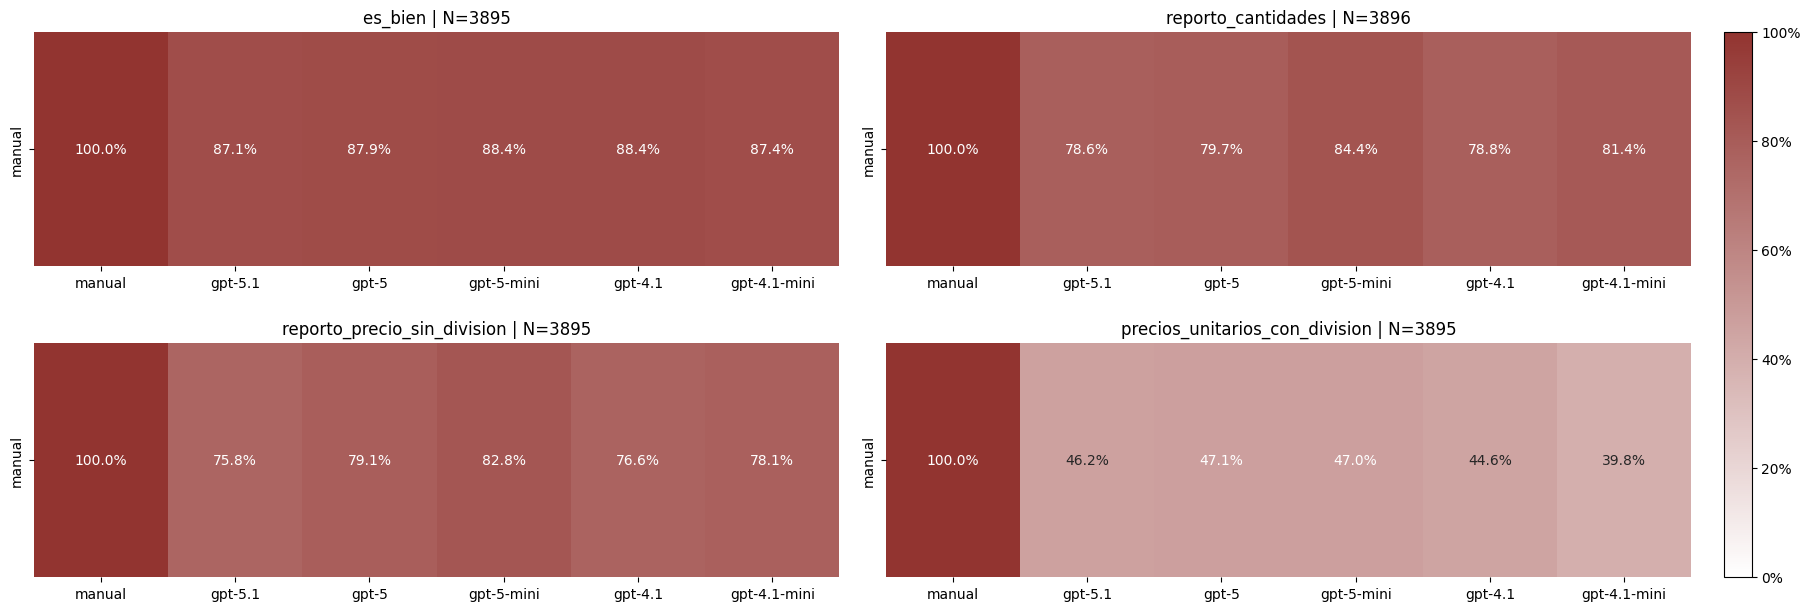

In [191]:
display(HTML("""
<p style="text-align: center; font-size: 17px; font-weight: bold;">
Figure 1. Model accuracy (matching %) by variable
</p>
"""))

variables = ['es_bien', 'reporto_cantidades', 'reporto_precio_sin_division', 'precios_unitarios_con_division']
model_names = ['gpt-5.1', 'gpt-5', 'gpt-5-mini', 'gpt-4.1', 'gpt-4.1-mini']
model_dfs = [gpt_5_1_results_agg, gpt_5_results_agg, gpt_5_mini_results_agg, gpt_4_1_results_agg, gpt_4_1_mini_results_agg]

merged_by_var = {}

fig = plt.figure(figsize=(18, 6), constrained_layout=True)
gs = fig.add_gridspec(2, 2, hspace=0.1, wspace=0.025)  # 2x2 grid
cmap = colors.LinearSegmentedColormap.from_list(
    "custom_red", ["#ffffff", "#923430"], N=256
)

for i, var in enumerate(variables):
    merged = master_df[['codename', var]].dropna().rename(columns={var: 'manual'})

    for model_df, name in zip(model_dfs, model_names):
        temp = model_df[['codename', 'data']].dropna()
        temp[name] = temp['data'].apply(lambda x: getattr(x, var) if x is not None else np.nan)
        merged = pd.merge(merged, temp[['codename', name]], on='codename', how='inner')

    merged = merged.dropna()
    merged_by_var[var] = merged.copy()

    matches = [100.0] + [
        100.0 * (merged['manual'] == merged[name]).mean()
        for name in model_names
    ]
    matrix = pd.DataFrame([matches], index=['manual'], columns=['manual'] + model_names)

    ax = fig.add_subplot(gs[i])
    labels = matrix.map(lambda x: f"{x:.1f}%")
    sns.heatmap(matrix, annot=labels, cmap=cmap, vmin=0, vmax=100, cbar=False, fmt="", ax=ax)
    ax.set_title(f"{var} | N={len(merged)}")

norm = mpl.colors.Normalize(vmin=0, vmax=100)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=fig.axes, orientation="vertical", fraction=0.025, pad=0.02)
cbar.ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))

plt.show()

Accuracy vs. cost comparison across models. The scatter plot positions each model by its average per-document cost (x-axis) and overall accuracy (y-axis), enabling Pareto-optimal model selection: models in the upper-left corner offer the best accuracy-to-cost ratio.

In [ ]:
acc = pd.DataFrame(index=model_names, columns=variables, dtype=float)
for v in variables:
    dfv = merged_by_var.get(v)
    if dfv is None or 'manual' not in dfv: 
        continue
    man = pd.to_numeric(dfv['manual'], errors='coerce')
    for m in model_names:
        if m in dfv:
            pred = pd.to_numeric(dfv[m], errors='coerce')
            mask = man.notna() & pred.notna()
            acc.loc[m, v] = (man[mask].astype(int).eq(pred[mask].astype(int))).mean() * 100

# total_cost = [df['cost'].map(lambda c: c.total_usd).sum()  for df in model_dfs]
# avg_cost   = [df['cost'].map(lambda c: c.total_usd).mean() for df in model_dfs]

total_cost = [df['total_usd'].sum()  for df in model_dfs]
avg_cost   = [(df['total_usd']/df['n_candidates']).mean() for df in model_dfs]

table = acc.round(1)
table['Total cost (USD)'] = total_cost
table['Avg cost per request (USD)'] = avg_cost
# table.index.name = "Model"

styled = (
    table.style
    .format({**{v: "{:.1f}%" for v in variables},
             "Total cost (USD)": "${:,.2f}",
             "Avg cost per request (USD)": "${:,.4f}"})
    .set_table_attributes('style="width:100%; table-layout:fixed; margin-left:auto; margin-right:auto; max-width:1000px" id="tbl2"')
    .set_table_styles([
        {"selector": "thead th", "props": [("border-bottom", "2px solid #000"), ("text-align", "center"),("font-weight", "bold"),("white-space", "normal"), ("word-break", "break-word"), ("padding", "6px 8px")]},
        {"selector": "th.row_heading", "props": [("font-weight", "600")]}
    ])
    .set_caption("Table 3. Model accuracy (matching %) with cost metrics")
)

styled.set_table_styles(
    [{"selector": "caption",
      "props": [("caption-side", "top"),
                ("text-align", "center"),
                ("font-size", "120%"),
                ("font-weight", "bold"),
                ("padding", "1.5em 0")]}],
    overwrite=False
)


,es_bien,reporto_cantidades,reporto_precio_sin_division,precios_unitarios_con_division,Total cost (USD),Avg cost per request (USD)
gpt-5.1,87.1%,78.6%,75.8%,46.2%,$12.59,$0.0032
gpt-5,87.9%,79.7%,79.1%,47.1%,$105.13,$0.0266
gpt-5-mini,88.4%,84.4%,82.8%,47.0%,$9.30,$0.0024
gpt-4.1,88.4%,78.8%,76.6%,44.6%,$18.99,$0.0048
gpt-4.1-mini,87.4%,81.4%,78.1%,39.8%,$11.77,$0.0030


#### Document Difficulty Level Heterogeneity

Agreement broken down by difficulty level (1–4) for each model and variable. This reveals whether certain models degrade more steeply on harder documents (levels 3–4: low contrast or no embedded text), which is critical for deciding whether to apply difficulty-specific extraction strategies.

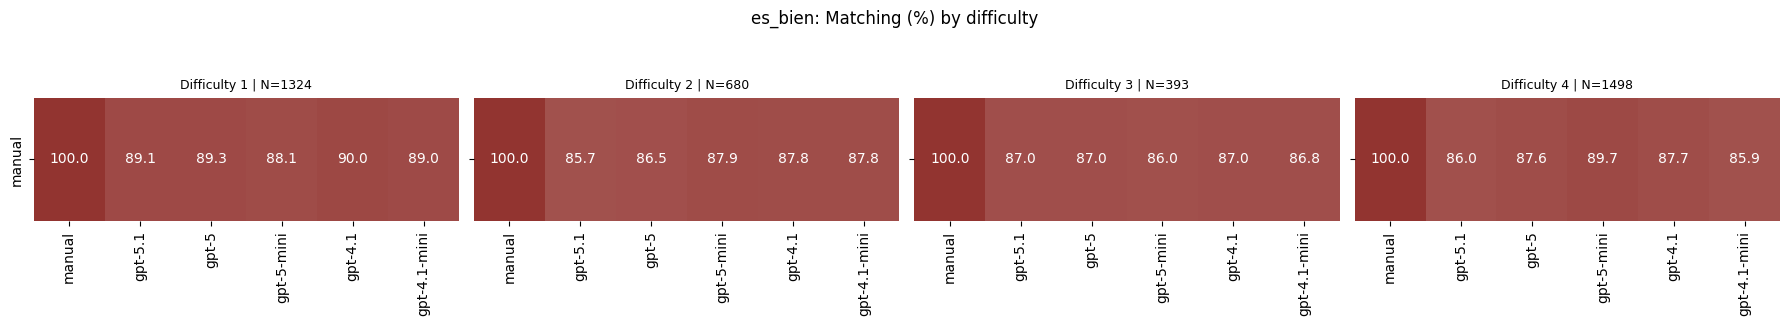

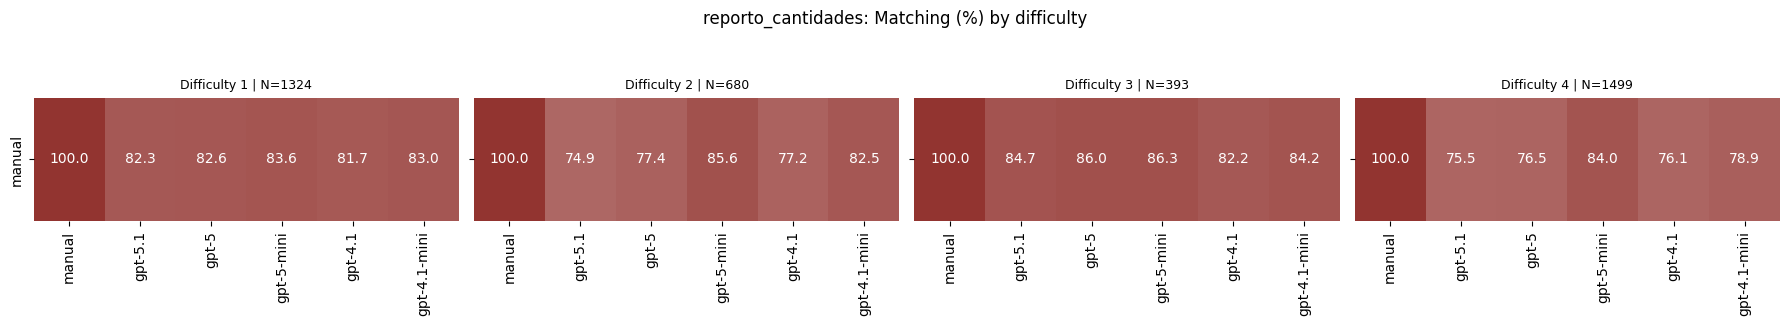

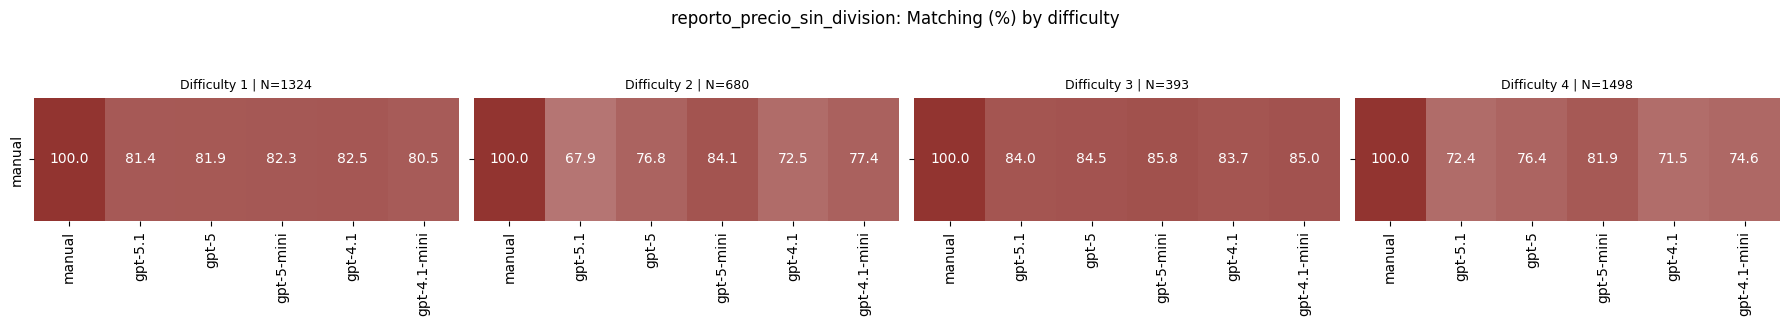

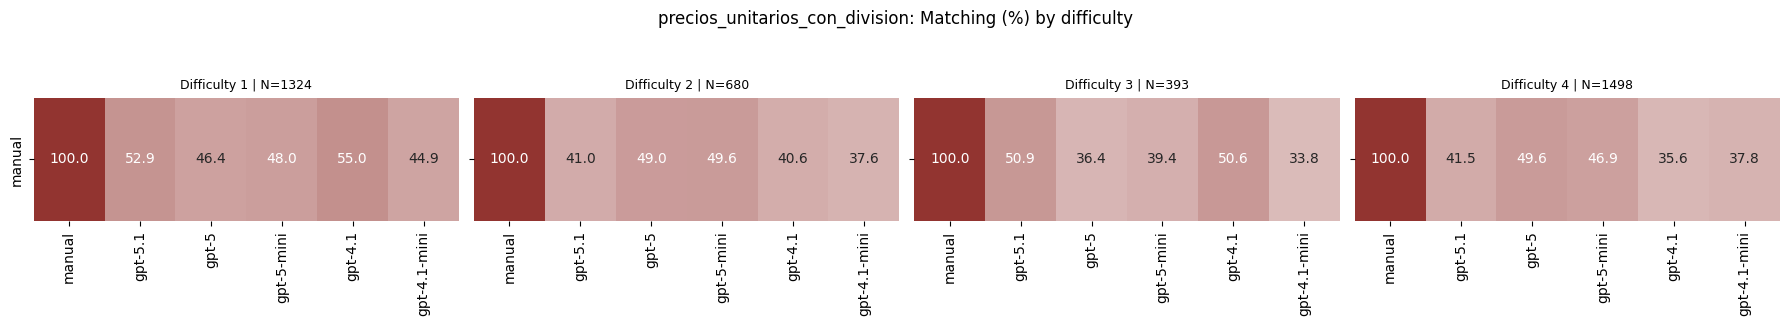

In [ ]:
difficulty_levels = [1, 2, 3, 4]
cmap = colors.LinearSegmentedColormap.from_list(
    "custom_red", ["#ffffff", "#923430"], N=256
)

for var in variables:
    merged = merged_by_var.get(var, None)

    merged_dl = pd.merge(
        merged,
        master_df[['codename', 'difficulty_level_contracts']],
        on='codename',
        how='left'
    )
    merged_dl = merged_dl[merged_dl['difficulty_level_contracts'].isin(difficulty_levels)].copy()
    merged_dl['difficulty_level_contracts'] = merged_dl['difficulty_level_contracts'].astype(int)

    fig, axes = plt.subplots(1, 4, figsize=(18, 3), sharey=True)
    fig.suptitle(f"{var}: Matching (%) by difficulty", y=1.07, fontsize=12)

    for j, diff in enumerate(difficulty_levels):
        ax = axes[j]
        sub = merged_dl[merged_dl['difficulty_level_contracts'] == diff]

        if sub.empty:
            ax.axis('off')
            ax.set_title(f"Difficulty {diff}\n(no data)", fontsize=9)
            continue

        matches = [100.0] + [
            100.0 * (sub['manual'] == sub[name]).mean()
            for name in model_names
        ]
        matrix = pd.DataFrame([matches], index=['manual'], columns=['manual'] + model_names)

        sns.heatmap(
            matrix, annot=True, cmap=cmap, vmin=0, vmax=100,
            cbar=False, fmt=".1f", ax=ax
        )
        ax.set_title(f"Difficulty {diff} | N={len(sub)}", fontsize=9)

    plt.tight_layout()
    plt.show()

---

## Anthropic Models' Validation Extraction

### Setup

The Anthropic extraction setup mirrors the OpenAI pipeline with provider-specific adaptations:

- **`CostBreakdownAnthropic`** — extends the cost model with Anthropic-specific fields: 5-minute and 1-hour cache tiers, cache read tokens, server tool use, and service tier.
- **`MODEL_PRICING_ANTHROPIC`** — per-million token rates for `claude-sonnet-4-5` and `claude-haiku-4-5`, including cache write and read pricing.
- **Retry logic** — same exponential backoff, but with Anthropic-specific error handling (e.g., 100-page PDF limit, request size limits).
- **PDF handling** — Anthropic's API accepts base64-encoded PDFs directly with `type: document`.

In [36]:
LOGFILE = "anthropic_extraction.log"

retry_logger = logging.getLogger("retry")
retry_logger.setLevel(logging.INFO)
retry_logger.propagate = False

retry_logger.handlers.clear()

fh = RotatingFileHandler(LOGFILE, maxBytes=2_000_000, backupCount=3, encoding="utf-8")
fh.setFormatter(logging.Formatter("%(asctime)s | %(name)s | %(levelname)s | %(message)s"))
retry_logger.addHandler(fh)

In [37]:
import anthropic

client = anthropic.Anthropic()

In [38]:
class CostBreakdownAnthropic(BaseModel):
    input_tokens: int
    cache_5m_input_tokens: int
    cache_1h_input_tokens: int
    cache_read_input_tokens: int
    output_tokens: int
    server_tool_use: int | None
    service_tier: str
    cost_input_usd: float
    cost_cache_5m_usd: float
    cost_cache_1h_usd: float
    cost_cache_read_usd: float
    cost_output_usd: float

    @property
    def total_usd(self) -> float:
        return round(
            self.cost_input_usd + 
            self.cost_cache_5m_usd + 
            self.cost_cache_1h_usd + 
            self.cost_cache_read_usd + 
            self.cost_output_usd,
            6,
        )

    def pretty(self) -> str:
        lines = [
            "┌─ Anthropic Cost Breakdown ────────────────────",
            f"│ Total cost:         {self.total_usd:.6f}$",
            f"│ Input tokens:       {self.input_tokens} → {self.cost_input_usd:.6f}$",
            f"│ Cache 5m writes:    {self.cache_5m_input_tokens} → {self.cost_cache_5m_usd:.6f}$",
            f"│ Cache 1h writes:    {self.cache_1h_input_tokens} → {self.cost_cache_1h_usd:.6f}$",
            f"│ Cache reads:        {self.cache_read_input_tokens} → {self.cost_cache_read_usd:.6f}$",
            f"│ Output tokens:      {self.output_tokens} → {self.cost_output_usd:.6f}$",
            f"│ Service tier:       {self.service_tier}",
            "└────────────────────────────────────────────────",
        ]
        return "\n".join(lines)

In [39]:
MODEL_PRICING_ANTHROPIC = {
    "claude-sonnet-4-5-20250929": {
        "input": 3.00,
        "cache_5m": 3.75,
        "cache_1h": 6.00,
        "cache_read": 0.30,
        "output": 15.00
    },
    "claude-haiku-4-5-20251001": {
        "input": 1.00,
        "cache_5m": 1.25,
        "cache_1h": 2.00,
        "cache_read": 0.10,
        "output": 5.00
    },
    "claude-opus-4-5-20251101": {
        "input": 5.00,
        "cache_5m": 6.25,
        "cache_1h": 10.00,
        "cache_read": 0.50,
        "output": 25.00
    },
    "claude-sonnet-4-20250514": {
        "input": 3.00,
        "cache_5m": 3.75,
        "cache_1h": 6.00,
        "cache_read": 0.30,
        "output": 15.00
    },
    "claude-opus-4-1-20250805": {
        "input": 15.00,
        "cache_5m": 18.75,
        "cache_1h": 30.00,
        "cache_read": 1.50,
        "output": 75.00
    },
    "claude-opus-4-20250514": {
        "input": 15.00,
        "cache_5m": 18.75,
        "cache_1h": 30.00,
        "cache_read": 1.50,
        "output": 75.00
    },
    "claude-3-5-haiku-20241022": {
        "input": 0.80,
        "cache_5m": 1.00,
        "cache_1h": 1.60,
        "cache_read": 0.08,
        "output": 4.00
    },
    "claude-3-haiku-20240307": {
        "input": 0.25,
        "cache_5m": 0.30,
        "cache_1h": 0.50,
        "cache_read": 0.03,
        "output": 1.25
    }
}

In [40]:
def _usd(cost_per_million, tokens):
    val = (Decimal(str(cost_per_million)) / Decimal(1_000_000)) * Decimal(tokens)
    return float(val.quantize(Decimal("0.000001"), rounding=ROUND_HALF_UP))

In [41]:
def _normalize_usage_anthropic(usage_obj):
    if usage_obj is None:
        return {}
    if isinstance(usage_obj, dict):
        return usage_obj
    if hasattr(usage_obj, "model_dump"):
        return usage_obj.model_dump()
    if hasattr(usage_obj, "to_dict"):
        return usage_obj.to_dict()
    keys = ("cache_creation","cache_creation_input_tokens","cache_read_input_tokens","input_tokens",
            "output_tokens","server_tool_use","service_tier")
    return {k: getattr(usage_obj, k) for k in keys if hasattr(usage_obj, k)}

In [ ]:
def _compute_cost_from_usage_anthropic(usage: dict, model: str) -> CostBreakdown:
    input_tokens          = usage.get("input_tokens", 0)
    cache_read_tokens     = usage.get("cache_read_input_tokens", 0)
    output_tokens         = usage.get("output_tokens", 0)

    server_tool_use       = usage.get("server_tool_use", None)
    service_tier          = usage.get("service_tier", None)

    cache_creation        = usage.get("cache_creation", None)
    cache_5m_tokens      =  cache_creation.get("ephemeral_5m_input_tokens", 0)     if cache_creation else 0
    cache_1h_tokens      =  cache_creation.get("ephemeral_1h_input_tokens", 0)     if cache_creation else 0

    cost_input_usd          = _usd(MODEL_PRICING_ANTHROPIC[model]["input"],          input_tokens)
    cost_cache_5m_usd       = _usd(MODEL_PRICING_ANTHROPIC[model]["cache_5m"],       cache_5m_tokens)
    cost_cache_1h_usd       = _usd(MODEL_PRICING_ANTHROPIC[model]["cache_1h"],       cache_1h_tokens)
    cost_cache_read_usd     = _usd(MODEL_PRICING_ANTHROPIC[model]["cache_read"],     cache_read_tokens)
    cost_output_usd         = _usd(MODEL_PRICING_ANTHROPIC[model]["output"],         output_tokens)

    return CostBreakdownAnthropic(
        input_tokens=input_tokens,
        cache_5m_input_tokens=cache_5m_tokens,
        cache_1h_input_tokens=cache_1h_tokens,
        cache_read_input_tokens=cache_read_tokens,
        output_tokens=output_tokens,
        server_tool_use=server_tool_use,
        service_tier=service_tier,
        cost_input_usd=cost_input_usd,
        cost_cache_5m_usd=cost_cache_5m_usd,
        cost_cache_1h_usd=cost_cache_1h_usd,
        cost_cache_read_usd=cost_cache_read_usd,
        cost_output_usd=cost_output_usd,
    )


In [ ]:
def _is_retryable_anthropic(exc: Exception) -> bool:
    try:
        import anthropic

        if isinstance(exc,(anthropic.BadRequestError)) and \
        exc.status_code == 400 and \
        "A maximum of 100 PDF pages may be provided" in exc.message:
            return False

        if "Request exceeds the maximum size" in exc.message:
            return False

        status = getattr(exc, "status", None) or getattr(exc, "status_code", None)
        message = getattr(exc, "message", None) or str(exc)

        if isinstance(exc, (getattr(anthropic, "BadRequestError", ()), anthropic.APIStatusError)):
            if "A maximum of 100 PDF pages may be provided" in message:
                return False

        if isinstance(
            exc,
            (
                anthropic.RateLimitError,
                anthropic.APIConnectionError,
                anthropic.APITimeoutError,
                anthropic.InternalServerError,
                anthropic.APIStatusError,  
            ),
        ):
            return True
    except Exception:
        pass

    try:
        import httpx

        if isinstance(
            exc,
            (
                httpx.ConnectError,
                httpx.ReadTimeout,
                httpx.WriteError,
                httpx.RemoteProtocolError,
                getattr(httpx, "PoolTimeout", tuple()), 
            ),
        ):
            return True
    except Exception:
        pass

    status = getattr(exc, "status", None) or getattr(exc, "status_code", None)
    if isinstance(status, int) and (
        status == 429
        or status >= 500
        or status in (408, 502, 503, 504)
    ):
        return True

    if isinstance(exc, (TimeoutError, ConnectionError)):
        return True

    return False


In [44]:
from tenacity import RetryCallState

def before_sleep_log_with_filename(logger, log_level):
    def log_it(retry_state: RetryCallState):
        sleep = retry_state.next_action.sleep if retry_state.next_action else 0
        fn_name = getattr(retry_state.fn, "__qualname__", repr(retry_state.fn))
        exc = retry_state.outcome.exception()
        pdf_name = retry_state.kwargs.get("pdf_name")

        logger.log(
            log_level,
            "Retrying %s for %s in %s seconds as it raised %s",
            fn_name,
            pdf_name,
            sleep,
            exc,
        )
    
    return log_it


In [45]:
@retry(
    retry=retry_if_exception(_is_retryable_anthropic),
    wait=wait_random_exponential(multiplier=1, min=6, max=20),
    stop=stop_after_attempt(10),  
    before_sleep=before_sleep_log_with_filename(retry_logger, logging.WARNING),
    # after=after_log(retry_logger, logging.INFO),
    reraise=True
)
def _parse_with_retry_anthropic(*, client, model, messages, output_format, betas, pdf_name=None):
    return client.beta.messages.parse(
        max_tokens=4096,
        model=model,
        messages=messages,
        output_format=output_format,
        betas=betas
    )

In [46]:
class ExtractionResultAnthropic(BaseModel):
    data: Any
    cost: CostBreakdownAnthropic

In [47]:
def extract_data_from_pdf_anthropic(pdf_name: str, base_dir, *, model: str, verbose: bool = False, output_format):
    """
    Extracts data from a PDF file and returns an ExtractionResult (data + cost),
    with automatic retries on transient API errors.
    """
    try:
        full_path = base_dir / pdf_name

        size_bytes = full_path.stat().st_size
        size_mb = size_bytes / (1000 * 1024)

        if size_mb > 24:
            
            with open(full_path, "rb") as f:
                file_upload = client.beta.files.upload(file=(pdf_name, f, "application/pdf"))

            messages = [
                {
                    "role": "user",
                    "content": [
                        {
                            "type": "document",
                            "source": {
                                "type": "file",
                                "file_id": file_upload.id,
                            }
                        },
                        {
                            "type": "text",
                            "text": "Retrieve structured information from this contract."
                        }
                    ],
                },
            ]

            betas = ["files-api-2025-04-14"]

        else:

            with open(full_path, "rb") as f:
                data = f.read()
            base64_string = base64.b64encode(data).decode("utf-8")

            messages = [
                {
                    "role": "user",
                    "content": [
                        {
                            "type": "document",
                            "source": {
                                "type": "base64",
                                "media_type": "application/pdf",
                                "data": base64_string
                            }
                        },
                        {
                            "type": "text",
                            "text": "Retrieve structured information from this contract."
                        }
                    ],
                },
            ]

            betas = []

        response = _parse_with_retry_anthropic(
            client=client,
            model=model,
            messages=messages,
            output_format=output_format,
            betas=betas,
            pdf_name=pdf_name,
        )

        parsed = response.parsed_output
        usage = _normalize_usage_anthropic(getattr(response, "usage", None))
        cost = _compute_cost_from_usage_anthropic(usage or {}, model=model)
        
        return ExtractionResultAnthropic(data=parsed, cost=cost)

    except Exception as e:
        retry_logger.error(f"[{pdf_name}] Anthropic extraction failed: {type(e).__name__}: {e}")
        return None

Quick verification on a single document before launching parallel runs.

In [44]:
extract_data_from_pdf_anthropic(pdf_name='C_PROCESO_19-1-197880_225317011_55166262__19-1-197880.pdf', base_dir=pdfs_dir, model="claude-haiku-4-5-20251001", verbose=True, output_format=DummyVariables)

ExtractionResultAnthropic(data=DummyVariables(es_bien=0, reporto_cantidades=1, reporto_precio_sin_division=0, precios_unitarios_con_division=0), cost=CostBreakdownAnthropic(input_tokens=27705, cache_5m_input_tokens=0, cache_1h_input_tokens=0, cache_read_input_tokens=0, output_tokens=48, server_tool_use=None, service_tier='standard', cost_input_usd=0.027705, cost_cache_5m_usd=0.0, cost_cache_1h_usd=0.0, cost_cache_read_usd=0.0, cost_output_usd=0.00024))

In [ ]:
def parallel_extraction_anthropic(
    items: list[tuple[int, list[str]]],   # (index, contract_candidates)
    base_dir: str,
    model: str,
    output_format,
    max_workers: int = 20,
    checkpoint_every: int = 100,
    checkpoint_path: str = None,
    resume_from: str = None,
) -> pd.DataFrame:
    """
    Parallel extraction with checkpointing and resume capability (Anthropic).
    
    Parameters
    ----------
    max_workers : int
        Concurrent API requests. Default 20 (I/O-bound, not CPU-bound).
    checkpoint_every : int
        Save partial results to disk every N completed documents.
    checkpoint_path : str
        Path for checkpoint file. If None, auto-generated from model name.
    resume_from : str
        Path to a previous checkpoint file to resume from (skips already-processed docs).
    """
    rows = []
    completed_keys = set()

    # Resume from checkpoint if provided
    if resume_from and Path(resume_from).exists():
        prev_df = pd.read_pickle(resume_from)
        rows = prev_df.to_dict("records")
        completed_keys = {(r["index"], r["candidate_i"]) for r in rows}
        print(f"Resumed {len(rows)} results from {resume_from}")

    if checkpoint_path is None:
        checkpoint_path = f"checkpoint_anthropic_{model.replace('.', '_').replace('-', '_')}.pkl"

    pending_futures = {}
    running_cost = sum(r.get("total_usd", 0) or 0 for r in rows)

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        for idx, candidates in items:
            for cand_i, path in enumerate(candidates):
                if (idx, cand_i) in completed_keys:
                    continue
                fut = ex.submit(
                    extract_data_from_pdf_anthropic,
                    path,
                    base_dir=base_dir,
                    model=model,
                    verbose=False,
                    output_format=output_format
                )
                pending_futures[fut] = (idx, cand_i, path)

        if not pending_futures:
            print("All documents already processed.")
            return pd.DataFrame(rows).sort_values(["index", "candidate_i"]).reset_index(drop=True)

        n_new = 0
        for fut in tqdm(as_completed(pending_futures), total=len(pending_futures), desc="Extracting"):
            idx, cand_i, path = pending_futures[fut]
            try:
                res = fut.result()
                error = None
            except Exception as e:
                print(f"Worker exception on {path}: {e}")
                res = None
                error = e

            if res is None:
                rows.append({
                    "index": idx,
                    "candidate_i": cand_i,
                    "contract_path": path,
                    "status": "fail",
                    "data": None,
                    "cost": None,
                    "total_usd": None,
                    "error": str(error) if error else "Extraction returned None (see devils_advocate.log for details)",
                })
            else:
                dv = res.data
                cb = res.cost
                doc_cost = getattr(cb, "total_usd", 0) or 0
                running_cost += doc_cost

                rows.append({
                    "index": idx,
                    "candidate_i": cand_i,
                    "contract_path": path,
                    "status": "ok",
                    "data": dv,
                    "cost": cb,
                    "total_usd": doc_cost,
                    "error": None,
                })

            n_new += 1

            # Periodic checkpoint
            if checkpoint_every and n_new % checkpoint_every == 0:
                _tmp_ckpt = checkpoint_path + ".tmp"
                pd.DataFrame(rows).to_pickle(_tmp_ckpt)
                os.replace(_tmp_ckpt, checkpoint_path)  # atomic rename
                n_ok = sum(1 for r in rows if r["status"] == "ok")
                print(f"  [Checkpoint] {len(rows)} docs saved | {n_ok} ok | Running cost: ${running_cost:,.4f}")

    # Final save
    df = pd.DataFrame(rows).sort_values(["index", "candidate_i"]).reset_index(drop=True)
    if checkpoint_every:
        _tmp_ckpt = checkpoint_path + ".tmp"
        df.to_pickle(_tmp_ckpt)
        os.replace(_tmp_ckpt, checkpoint_path)  # atomic rename

    n_ok = (df["status"] == "ok").sum()
    print(f"Total: {n_ok}/{len(df)} ok | Total cost: ${running_cost:,.4f}")
    return df

### Large-Scale Parallel Extraction

Parallel extraction on the eligible corpus using two Anthropic models: `claude-haiku-4-5` and `claude-sonnet-4-5`. Both use the same `DummyVariables` schema as the OpenAI runs for direct comparison.

Running `claude-haiku-4-5` and `claude-sonnet-4-5` on the same eligible corpus. Results are aggregated per codename using the same `aggregate_results_per_index` function.

In [94]:
claude_haiku_4_5_results = parallel_extraction_anthropic(items, base_dir=pdfs_dir, model="claude-haiku-4-5-20251001", output_format=DummyVariables)
claude_haiku_4_5_results.to_excel(data_pro_path / "LMM_testing_claude_haiku_4_5_results.xlsx", index=False)
extraction_summary(claude_haiku_4_5_results)

Extracting:   6%|▌         | 233/3952 [02:04<25:15,  2.45it/s]  

Worker exception on C_PROCESO_21-4-12124471_205001225_91090648__21-4-12124471.pdf: Error code: 400 - {'type': 'error', 'error': {'type': 'invalid_request_error', 'message': 'messages.0.content.0.pdf.source.base64.data: A maximum of 100 PDF pages may be provided.'}, 'request_id': 'req_011CWyAcCB5nj7huHWT6gG3A'}


Extracting:  74%|███████▍  | 2919/3952 [27:59<14:56,  1.15it/s]  

Worker exception on C_PROCESO_19-12-9754322_241001001_61571075__19-12-9754322.PDF: Error code: 400 - {'type': 'error', 'error': {'type': 'invalid_request_error', 'message': 'Could not process PDF'}, 'request_id': 'req_011CWyCZWERfmw3qLfdDUKTJ'}


Extracting: 100%|█████████▉| 3951/3952 [42:17<01:20, 80.25s/it]

Worker exception on C_PROCESO_21-12-12303103_215516024_93463367__21-12-12303103.pdf: Error code: 400 - {'type': 'error', 'error': {'type': 'invalid_request_error', 'message': 'Could not process PDF'}, 'request_id': 'req_011CWyDehtR3JuFoW5CxCKwj'}


Extracting: 100%|██████████| 3952/3952 [43:21<00:00,  1.52it/s]

Worker exception on C_PROCESO_21-12-12219139_20505112_92376258__21-12-12219139.pdf: Error code: 400 - {'type': 'error', 'error': {'type': 'invalid_request_error', 'message': 'Could not process PDF'}, 'request_id': 'req_011CWyDjR8VKSbQr7frVk2P8'}


Done: 3948/3952 documents | Total spend: $39.395428 | Average spend: $0.009979


In [102]:
claude_sonnet_4_5_results = parallel_extraction_anthropic(items, base_dir=pdfs_dir, model="claude-sonnet-4-5-20250929", output_format=DummyVariables)
claude_sonnet_4_5_results.to_excel(data_pro_path / "LMM_testing_claude_sonnet_4_5_results.xlsx", index=False)
extraction_summary(claude_sonnet_4_5_results)

Extracting:   4%|▍         | 173/3952 [01:59<1:02:04,  1.01it/s]

Worker exception on C_PROCESO_21-4-12124471_205001225_91090648__21-4-12124471.pdf: Error code: 400 - {'type': 'error', 'error': {'type': 'invalid_request_error', 'message': 'messages.0.content.0.pdf.source.base64.data: A maximum of 100 PDF pages may be provided.'}, 'request_id': 'req_011CWyFRuqdDSHnSzN4Fkjw2'}


Extracting:  67%|██████▋   | 2645/3952 [31:40<11:18,  1.93it/s]  

Worker exception on C_PROCESO_19-12-9754322_241001001_61571075__19-12-9754322.PDF: Error code: 429 - {'type': 'error', 'error': {'type': 'rate_limit_error', 'message': 'This request would exceed the rate limit for your organization (c6b19615-4a13-4ef7-b7f5-3426c926868b) of 800,000 input tokens per minute. For details, refer to: https://docs.claude.com/en/api/rate-limits. You can see the response headers for current usage. Please reduce the prompt length or the maximum tokens requested, or try again later. You may also contact sales at https://www.anthropic.com/contact-sales to discuss your options for a rate limit increase.'}, 'request_id': 'req_011CWyHhTV2vv4mvtvEUo83D'}


Extracting: 100%|██████████| 3952/3952 [51:02<00:00,  1.29it/s]

Worker exception on C_PROCESO_21-12-12219139_20505112_92376258__21-12-12219139.pdf: Error code: 400 - {'type': 'error', 'error': {'type': 'invalid_request_error', 'message': 'Could not process PDF'}, 'request_id': 'req_011CWyK9TVcwFjh8UeW6WuGb'}


Done: 3949/3952 documents | Total spend: $118.279929 | Average spend: $0.029952


In [103]:
claude_haiku_4_5_results_agg = aggregate_results_per_index(claude_haiku_4_5_results)
claude_sonnet_4_5_results_agg = aggregate_results_per_index(claude_sonnet_4_5_results)

In [101]:
claude_haiku_4_5_results_agg

,codename,contract_candidates,status,data,cost,total_usd,n_candidates,n_ok
index,,,,,,,,
0,19-1-197880,[C_PROCESO_19-1-197880_225317011_55166262__19-...,ok,es_bien=0 reporto_cantidades=0 reporto_precio_...,input_tokens=27705 cache_5m_input_tokens=0 cac...,0.027945,1,1
1,19-1-198086,[C_PROCESO_19-1-198086_205490011_55109704__19-...,ok,es_bien=1 reporto_cantidades=1 reporto_precio_...,input_tokens=11360 cache_5m_input_tokens=0 cac...,0.011600,1,1
2,19-1-203223,[C_PROCESO_19-1-203223_208638011_62412069__19-...,ok,es_bien=1 reporto_cantidades=1 reporto_precio_...,input_tokens=19434 cache_5m_input_tokens=0 cac...,0.019674,1,1
3,19-1-207657,[C_PROCESO_19-1-207657_28860313_68249258__19-1...,ok,es_bien=1 reporto_cantidades=1 reporto_precio_...,input_tokens=3566 cache_5m_input_tokens=0 cach...,0.003806,1,1
4,19-11-10098942,[C_PROCESO_19-11-10098942_254000001_68167892__...,ok,es_bien=1 reporto_cantidades=1 reporto_precio_...,input_tokens=14430 cache_5m_input_tokens=0 cac...,0.014670,1,1
...,...,...,...,...,...,...,...,...
4392,22-12-12664295,[C_PROCESO_22-12-12664295_273483020_98512869__...,ok,es_bien=0 reporto_cantidades=1 reporto_precio_...,input_tokens=28186 cache_5m_input_tokens=0 cac...,0.028426,1,1
4393,22-4-12655740,[C_PROCESO_22-4-12655740_273349019_98414526__2...,ok,es_bien=1 reporto_cantidades=1 reporto_precio_...,input_tokens=7718 cache_5m_input_tokens=0 cach...,0.007958,1,1
4394,22-4-12658055,[C_PROCESO_22-4-12658055_24148312_98446571__22...,ok,es_bien=1 reporto_cantidades=0 reporto_precio_...,input_tokens=9774 cache_5m_input_tokens=0 cach...,0.010014,1,1


### Extraction Analysis

Same accuracy analysis applied to Anthropic model results: per-variable agreement heatmaps, accuracy vs. cost scatter plot, and difficulty-level breakdowns. Results are compared alongside the OpenAI models to produce a unified model ranking.

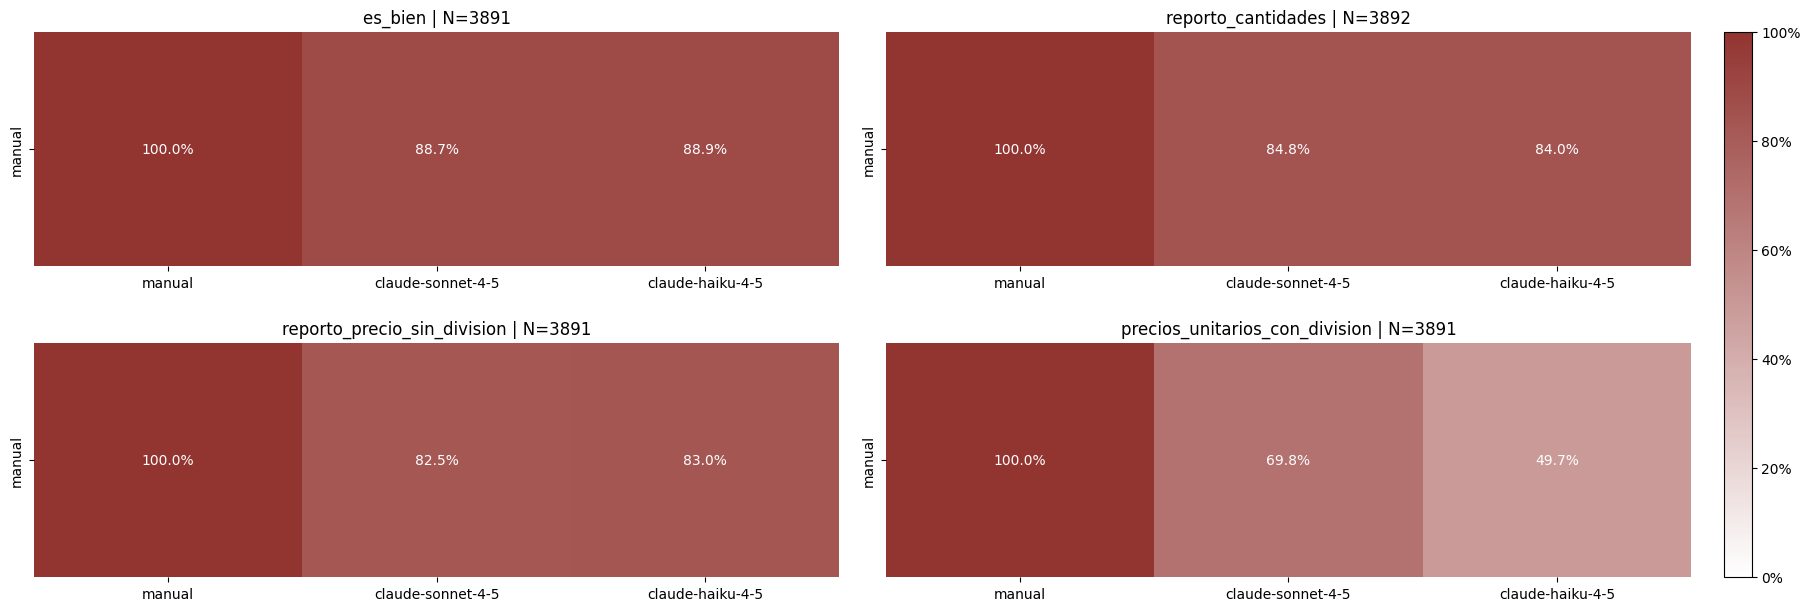

In [104]:
display(HTML("""
<p style="text-align: center; font-size: 17px; font-weight: bold;">
Figure 1. Model accuracy (matching %) by variable
</p>
"""))

variables = ['es_bien', 'reporto_cantidades', 'reporto_precio_sin_division', 'precios_unitarios_con_division']
model_names = ['claude-sonnet-4-5', 'claude-haiku-4-5']
model_dfs = [claude_sonnet_4_5_results_agg, claude_haiku_4_5_results_agg]

merged_by_var = {}

fig = plt.figure(figsize=(18, 6), constrained_layout=True)
gs = fig.add_gridspec(2, 2, hspace=0.1, wspace=0.025)  # 2x2 grid
cmap = colors.LinearSegmentedColormap.from_list(
    "custom_red", ["#ffffff", "#923430"], N=256
)

for i, var in enumerate(variables):
    merged = master_df[['codename', var]].dropna().rename(columns={var: 'manual'})

    for model_df, name in zip(model_dfs, model_names):
        temp = model_df[['codename', 'data']].dropna()
        temp[name] = temp['data'].apply(lambda x: getattr(x, var) if x is not None else np.nan)
        merged = pd.merge(merged, temp[['codename', name]], on='codename', how='inner')

    merged = merged.dropna()
    merged_by_var[var] = merged.copy()

    matches = [100.0] + [
        100.0 * (merged['manual'] == merged[name]).mean()
        for name in model_names
    ]
    matrix = pd.DataFrame([matches], index=['manual'], columns=['manual'] + model_names)

    ax = fig.add_subplot(gs[i])
    labels = matrix.map(lambda x: f"{x:.1f}%")
    sns.heatmap(matrix, annot=labels, cmap=cmap, vmin=0, vmax=100, cbar=False, fmt="", ax=ax)
    ax.set_title(f"{var} | N={len(merged)}")

norm = mpl.colors.Normalize(vmin=0, vmax=100)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=fig.axes, orientation="vertical", fraction=0.025, pad=0.02)
cbar.ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))

plt.show()

In [105]:
acc = pd.DataFrame(index=model_names, columns=variables, dtype=float)
for v in variables:
    dfv = merged_by_var.get(v)
    if dfv is None or 'manual' not in dfv: 
        continue
    man = pd.to_numeric(dfv['manual'], errors='coerce')
    for m in model_names:
        if m in dfv:
            pred = pd.to_numeric(dfv[m], errors='coerce')
            mask = man.notna() & pred.notna()
            acc.loc[m, v] = (man[mask].astype(int).eq(pred[mask].astype(int))).mean() * 100

# total_cost = [df['cost'].map(lambda c: c.total_usd).sum()  for df in model_dfs]
# avg_cost   = [df['cost'].map(lambda c: c.total_usd).mean() for df in model_dfs]

total_cost = [df['total_usd'].sum()  for df in model_dfs]
avg_cost   = [(df['total_usd']/df['n_candidates']).mean() for df in model_dfs]

table = acc.round(1)
table['Total cost (USD)'] = total_cost
table['Avg cost per request (USD)'] = avg_cost
# table.index.name = "Model"

styled = (
    table.style
    .format({**{v: "{:.1f}%" for v in variables},
             "Total cost (USD)": "${:,.2f}",
             "Avg cost per request (USD)": "${:,.4f}"})
    .set_table_attributes('style="width:100%; table-layout:fixed; margin-left:auto; margin-right:auto; max-width:1000px" id="tbl2"')
    .set_table_styles([
        {"selector": "thead th", "props": [("border-bottom", "2px solid #000"), ("text-align", "center"),("font-weight", "bold"),("white-space", "normal"), ("word-break", "break-word"), ("padding", "6px 8px")]},
        {"selector": "th.row_heading", "props": [("font-weight", "600")]}
    ])
    .set_caption("Table 3. Model accuracy (matching %) with cost metrics")
)

styled.set_table_styles(
    [{"selector": "caption",
      "props": [("caption-side", "top"),
                ("text-align", "center"),
                ("font-size", "120%"),
                ("font-weight", "bold"),
                ("padding", "1.5em 0")]}],
    overwrite=False
)


,es_bien,reporto_cantidades,reporto_precio_sin_division,precios_unitarios_con_division,Total cost (USD),Avg cost per request (USD)
claude-sonnet-4-5,88.7%,84.8%,82.5%,69.8%,$118.28,$0.0299
claude-haiku-4-5,88.9%,84.0%,83.0%,49.7%,$39.40,$0.0100


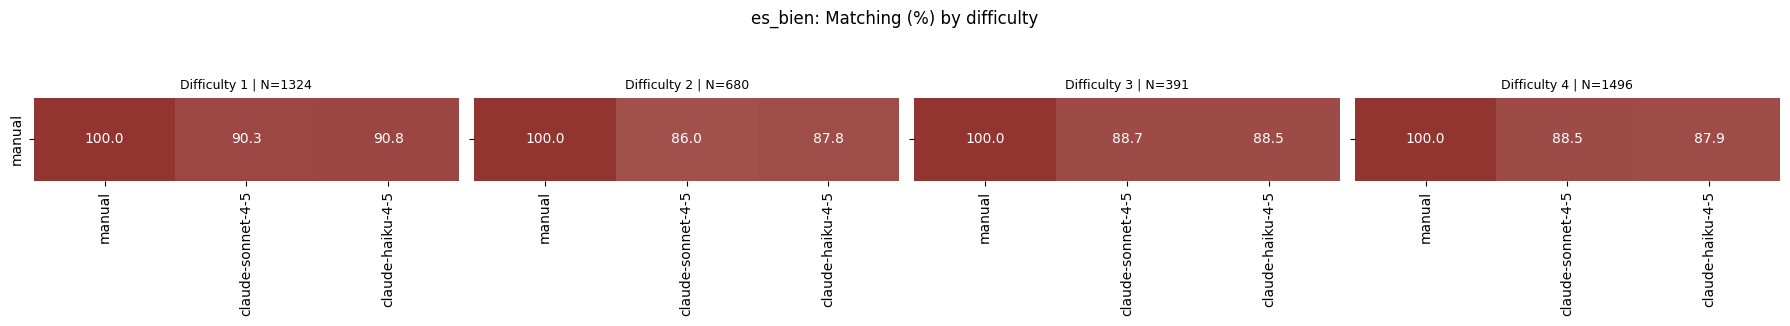

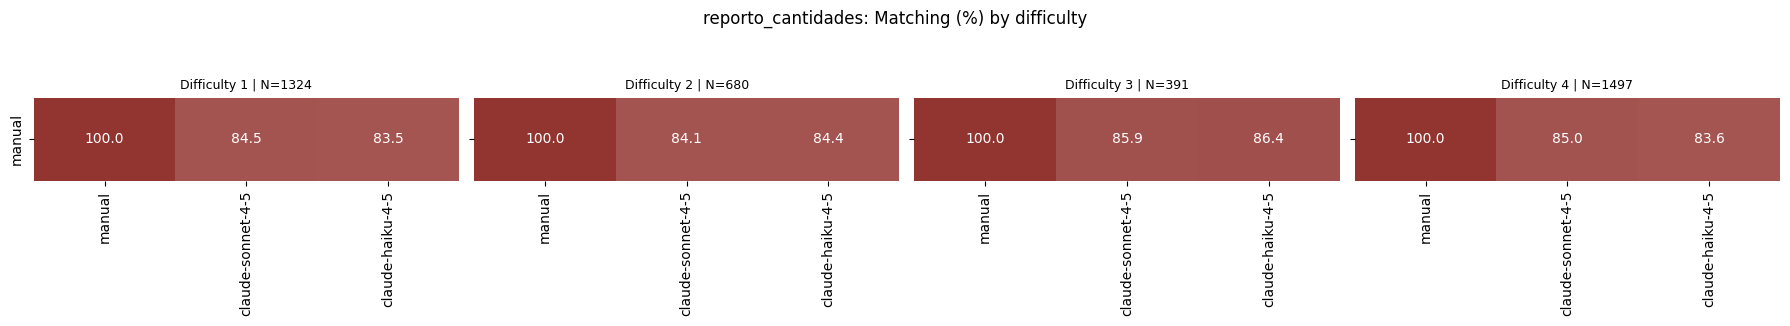

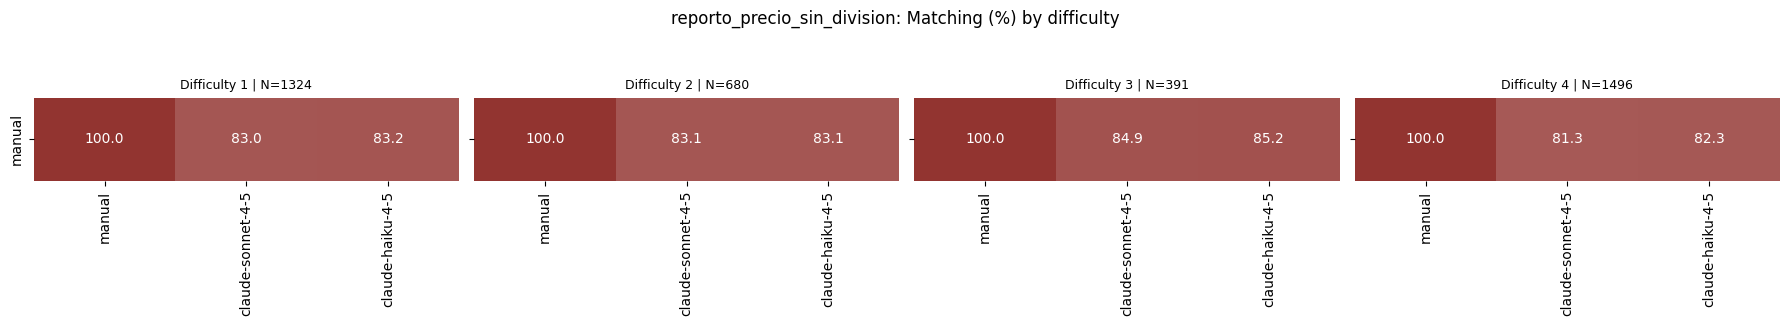

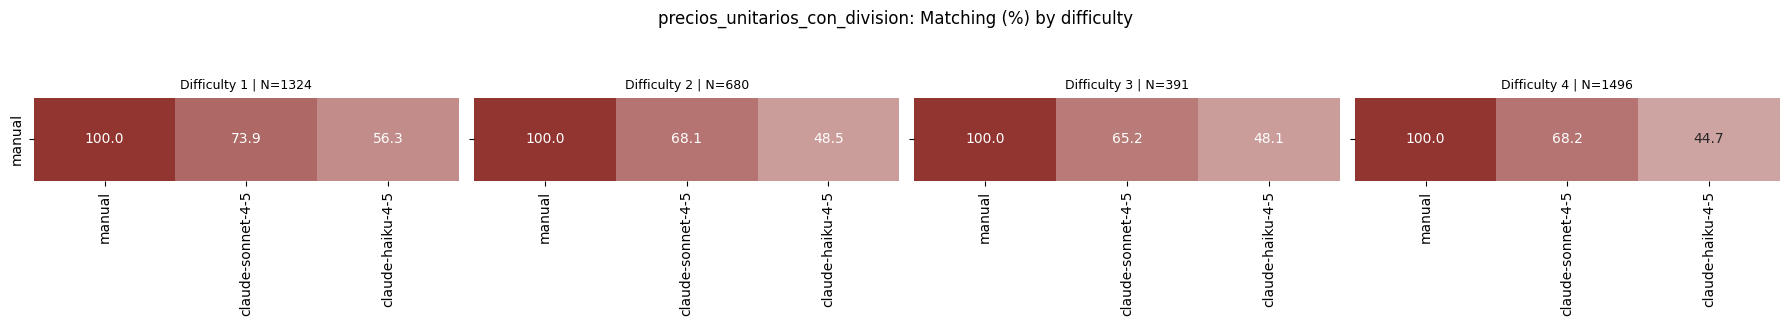

In [106]:
difficulty_levels = [1, 2, 3, 4]
cmap = colors.LinearSegmentedColormap.from_list(
    "custom_red", ["#ffffff", "#923430"], N=256
)

for var in variables:
    merged = merged_by_var.get(var, None)

    merged_dl = pd.merge(
        merged,
        master_df[['codename', 'difficulty_level_contracts']],
        on='codename',
        how='left'
    )
    merged_dl = merged_dl[merged_dl['difficulty_level_contracts'].isin(difficulty_levels)].copy()
    merged_dl['difficulty_level_contracts'] = merged_dl['difficulty_level_contracts'].astype(int)

    fig, axes = plt.subplots(1, 4, figsize=(18, 3), sharey=True)
    fig.suptitle(f"{var}: Matching (%) by difficulty", y=1.07, fontsize=12)

    for j, diff in enumerate(difficulty_levels):
        ax = axes[j]
        sub = merged_dl[merged_dl['difficulty_level_contracts'] == diff]

        if sub.empty:
            ax.axis('off')
            ax.set_title(f"Difficulty {diff}\n(no data)", fontsize=9)
            continue

        # compute matching %
        matches = [100.0] + [
            100.0 * (sub['manual'] == sub[name]).mean()
            for name in model_names
        ]
        matrix = pd.DataFrame([matches], index=['manual'], columns=['manual'] + model_names)

        sns.heatmap(
            matrix, annot=True, cmap=cmap, vmin=0, vmax=100,
            cbar=False, fmt=".1f", ax=ax
        )
        ax.set_title(f"Difficulty {diff} | N={len(sub)}", fontsize=9)

    plt.tight_layout()
    plt.show()

## Rehydrating Previous Extractions

Previously saved extraction results are loaded from Excel and deserialized back into Pydantic objects. This avoids re-running expensive API calls when resuming analysis. The rehydration function parses the string representation of `DummyVariables` objects stored in the `data` column and reconstructs the original Pydantic instances.

### Rehydration Logic

The `_parse_kv_string` function deserializes the string representation of Pydantic objects stored in Excel cells back into Python dictionaries. Combined with `_rehydrate_lmm_results`, it reconstructs the full `DummyVariables` objects from saved extraction results.

In [35]:
_kv = re.compile(r"(\w+)=('.*?'|\".*?\"|[^\s]+)")

def _parse_kv_string(s: str) -> dict:
    if s is None or (isinstance(s, float) and pd.isna(s)):
        return {}
    s = str(s).strip()
    if not s:
        return {}
    d = {}
    for k, v in _kv.findall(s):
        v = v.strip()
        if (v.startswith("'") and v.endswith("'")) or (v.startswith('"') and v.endswith('"')):
            v = v[1:-1]
        if str(v).lower() in ("none", "nan", "na", ""):
            d[k] = None
            continue
        try:
            d[k] = int(v)
        except Exception:
            try:
                d[k] = float(v)
            except Exception:
                d[k] = v
    return d


def _rehydrate_lmm_results(df: pd.DataFrame) -> pd.DataFrame:

    if "cost" in df.columns:
        CostClass = CostBreakdownAnthropic if any("cache_read_input_tokens" in str(x) for x in df.get("cost", [])) else CostBreakdown

        def _mk_cost(x):
            if pd.isna(x):
                return None
            d = _parse_kv_string(x)
            stu = d.get("server_tool_use")
            if isinstance(stu, str) and stu.lower() in ("none", "nan", "na", ""):
                d["server_tool_use"] = None
            return CostClass(**d)

        df["cost"] = df["cost"].apply(_mk_cost)

    if "data" in df.columns:
        df["data"] = df["data"].apply(
            lambda x: DummyVariables(**_parse_kv_string(x)) if pd.notna(x) else None
        )

    return df


In [50]:
gpt_5_1_results = _rehydrate_lmm_results(
    pd.read_excel(data_pro_path / "LMM_testing_gpt_5_1_results.xlsx")
)

gpt_5_results = _rehydrate_lmm_results(
    pd.read_excel(data_pro_path / "LMM_testing_gpt_5_results.xlsx")
)

gpt_5_mini_results = _rehydrate_lmm_results(
    pd.read_excel(data_pro_path / "LMM_testing_gpt_5_mini_results.xlsx")
)

gpt_5_nano_results = _rehydrate_lmm_results(
    pd.read_excel(data_pro_path / "LMM_testing_gpt_5_nano_results.xlsx")
)

gpt_4_1_results = _rehydrate_lmm_results(
    pd.read_excel(data_pro_path / "LMM_testing_gpt_4_1_results.xlsx")
)

gpt_4_1_mini_results = _rehydrate_lmm_results(
    pd.read_excel(data_pro_path / "LMM_testing_gpt_4_1_mini_results.xlsx")
)

gpt_4_1_nano_results = _rehydrate_lmm_results(
    pd.read_excel(data_pro_path / "LMM_testing_gpt_4_1_nano_results.xlsx")
)

claude_haiku_4_5_results = _rehydrate_lmm_results(
    pd.read_excel(data_pro_path / "LMM_testing_claude_haiku_4_5_results.xlsx")
)

claude_sonnet_4_5_results = _rehydrate_lmm_results(
    pd.read_excel(data_pro_path / "LMM_testing_claude_sonnet_4_5_results.xlsx")
)

In [70]:
claude_haiku_4_5_results

,index,candidate_i,contract_path,status,data,cost,total_usd,error
0,0,0,C_PROCESO_19-1-197880_225317011_55166262__19-1...,ok,es_bien=0 reporto_cantidades=0 reporto_precio_...,input_tokens=27705 cache_5m_input_tokens=0 cac...,0.027945,NaN
1,1,0,C_PROCESO_19-1-198086_205490011_55109704__19-1...,ok,es_bien=1 reporto_cantidades=1 reporto_precio_...,input_tokens=11360 cache_5m_input_tokens=0 cac...,0.011600,NaN
2,2,0,C_PROCESO_19-1-203223_208638011_62412069__19-1...,ok,es_bien=1 reporto_cantidades=1 reporto_precio_...,input_tokens=19434 cache_5m_input_tokens=0 cac...,0.019674,NaN
3,3,0,C_PROCESO_19-1-207657_28860313_68249258__19-1-...,ok,es_bien=1 reporto_cantidades=1 reporto_precio_...,input_tokens=3566 cache_5m_input_tokens=0 cach...,0.003806,NaN
4,4,0,C_PROCESO_19-11-10098942_254000001_68167892__1...,ok,es_bien=1 reporto_cantidades=1 reporto_precio_...,input_tokens=14430 cache_5m_input_tokens=0 cac...,0.014670,NaN
...,...,...,...,...,...,...,...,...
3947,4392,0,C_PROCESO_22-12-12664295_273483020_98512869__2...,ok,es_bien=0 reporto_cantidades=1 reporto_precio_...,input_tokens=28186 cache_5m_input_tokens=0 cac...,0.028426,NaN
3948,4393,0,C_PROCESO_22-4-12655740_273349019_98414526__22...,ok,es_bien=1 reporto_cantidades=1 reporto_precio_...,input_tokens=7718 cache_5m_input_tokens=0 cach...,0.007958,NaN
3949,4394,0,C_PROCESO_22-4-12658055_24148312_98446571__22-...,ok,es_bien=1 reporto_cantidades=0 reporto_precio_...,input_tokens=9774 cache_5m_input_tokens=0 cach...,0.010014,NaN
3950,4395,0,C_PROCESO_22-4-12658777_273449014_98454802__22...,ok,es_bien=1 reporto_cantidades=1 reporto_precio_...,input_tokens=6754 cache_5m_input_tokens=0 cach...,0.006994,NaN


In [51]:
gpt_5_1_results_agg = aggregate_results_per_index(gpt_5_1_results)
gpt_5_results_agg = aggregate_results_per_index(gpt_5_results)
gpt_5_mini_results_agg = aggregate_results_per_index(gpt_5_mini_results)
gpt_4_1_results_agg = aggregate_results_per_index(gpt_4_1_results)
gpt_4_1_mini_results_agg = aggregate_results_per_index(gpt_4_1_mini_results)
claude_haiku_4_5_results_agg = aggregate_results_per_index(claude_haiku_4_5_results)
claude_sonnet_4_5_results_agg = aggregate_results_per_index(claude_sonnet_4_5_results)

### Combined Model Comparison

All seven models (5 OpenAI + 2 Anthropic) are compared on the same accuracy metrics and visualizations. This unified analysis produces the final model ranking used to select `gpt-5-mini` for production extraction.

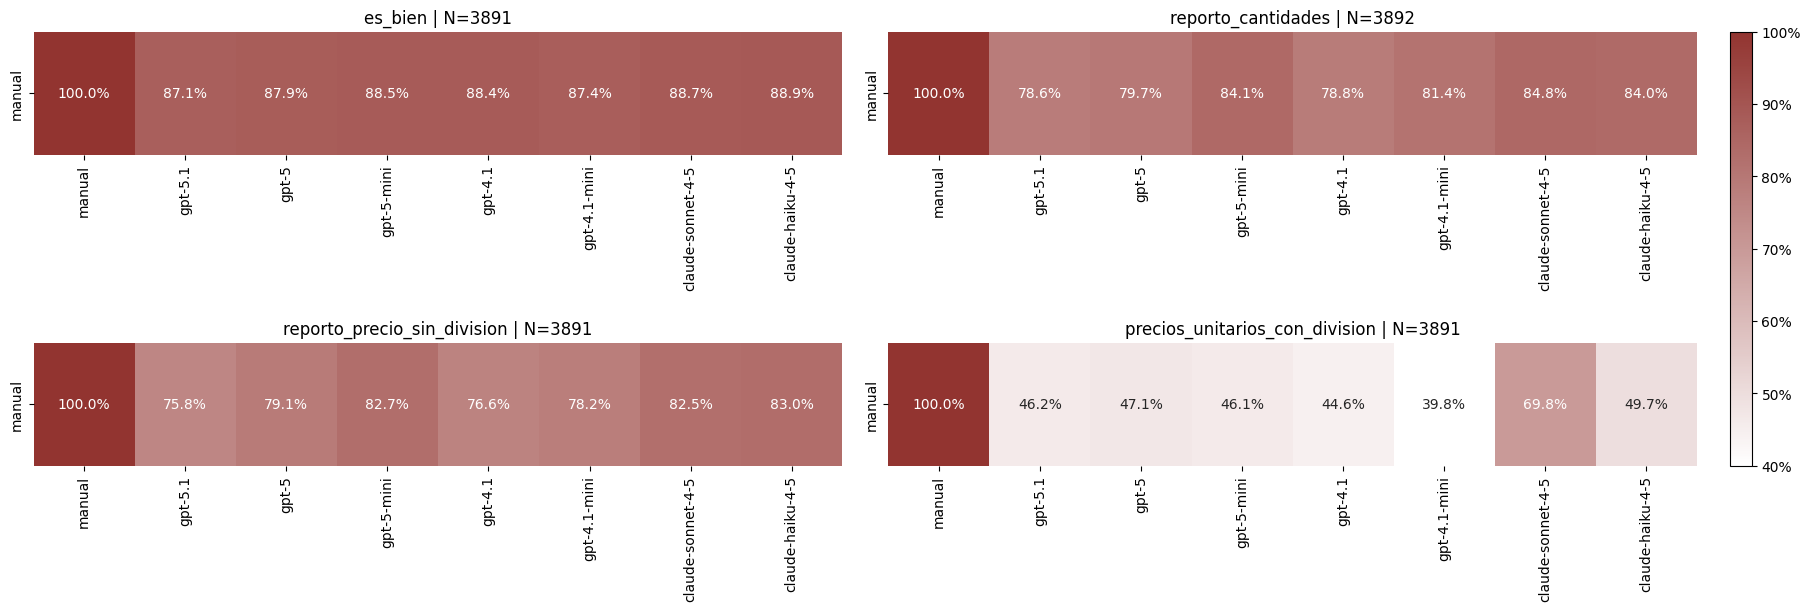

In [72]:
display(HTML("""
<p style="text-align: center; font-size: 17px; font-weight: bold;">
Figure 1. Model accuracy (matching %) by variable
</p>
"""))

variables = ['es_bien', 'reporto_cantidades', 'reporto_precio_sin_division', 'precios_unitarios_con_division']
model_names = ['gpt-5.1', 'gpt-5', 'gpt-5-mini', 'gpt-4.1', 'gpt-4.1-mini', 'claude-sonnet-4-5', 'claude-haiku-4-5']
model_dfs = [gpt_5_1_results_agg, gpt_5_results_agg, gpt_5_mini_results_agg, gpt_4_1_results_agg, gpt_4_1_mini_results_agg, claude_sonnet_4_5_results_agg, claude_haiku_4_5_results_agg]

merged_by_var = {}

fig = plt.figure(figsize=(18, 6), constrained_layout=True)
gs = fig.add_gridspec(2, 2, hspace=0.1, wspace=0.025)  # 2x2 grid
cmap = colors.LinearSegmentedColormap.from_list(
    "custom_red", ["#ffffff", "#923430"], N=256
)

for i, var in enumerate(variables):
    merged = master_df[['codename', var]].dropna().rename(columns={var: 'manual'})

    for model_df, name in zip(model_dfs, model_names):
        temp = model_df[['codename', 'data']].dropna()
        temp[name] = temp['data'].apply(lambda x: getattr(x, var) if x is not None else np.nan)
        merged = pd.merge(merged, temp[['codename', name]], on='codename', how='inner')

    merged = merged.dropna()
    merged_by_var[var] = merged.copy()

    matches = [100.0] + [
        100.0 * (merged['manual'] == merged[name]).mean()
        for name in model_names
    ]
    matrix = pd.DataFrame([matches], index=['manual'], columns=['manual'] + model_names)

    ax = fig.add_subplot(gs[i])
    labels = matrix.map(lambda x: f"{x:.1f}%")
    sns.heatmap(matrix, annot=labels, cmap=cmap, vmin=40, vmax=100, cbar=False, fmt="", ax=ax)
    ax.set_title(f"{var} | N={len(merged)}")

norm = mpl.colors.Normalize(vmin=40, vmax=100)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=fig.axes, orientation="vertical", fraction=0.025, pad=0.02)
cbar.ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100, decimals=0))

plt.show()

In [73]:
acc = pd.DataFrame(index=model_names, columns=variables, dtype=float)
for v in variables:
    dfv = merged_by_var.get(v)
    if dfv is None or 'manual' not in dfv: 
        continue
    man = pd.to_numeric(dfv['manual'], errors='coerce')
    for m in model_names:
        if m in dfv:
            pred = pd.to_numeric(dfv[m], errors='coerce')
            mask = man.notna() & pred.notna()
            acc.loc[m, v] = (man[mask].astype(int).eq(pred[mask].astype(int))).mean() * 100

# total_cost = [df['cost'].map(lambda c: c.total_usd).sum()  for df in model_dfs]
# avg_cost   = [df['cost'].map(lambda c: c.total_usd).mean() for df in model_dfs]

total_cost = [df['total_usd'].sum()  for df in model_dfs]
avg_cost   = [(df['total_usd']/df['n_candidates']).mean() for df in model_dfs]

table = acc.round(1)
table['Total cost (USD)'] = total_cost
table['Avg cost per request (USD)'] = avg_cost
# table.index.name = "Model"

styled = (
    table.style
    .format({**{v: "{:.1f}%" for v in variables},
             "Total cost (USD)": "${:,.2f}",
             "Avg cost per request (USD)": "${:,.4f}"})
    .set_table_attributes('style="width:100%; table-layout:fixed; margin-left:auto; margin-right:auto; max-width:1000px" id="tbl2"')
    .set_table_styles([
        {"selector": "thead th", "props": [("border-bottom", "2px solid #000"), ("text-align", "center"),("font-weight", "bold"),("white-space", "normal"), ("word-break", "break-word"), ("padding", "6px 8px")]},
        {"selector": "th.row_heading", "props": [("font-weight", "600")]}
    ])
    .set_caption("Table 3. Model accuracy (matching %) with cost metrics")
)

styled.set_table_styles(
    [{"selector": "caption",
      "props": [("caption-side", "top"),
                ("text-align", "center"),
                ("font-size", "120%"),
                ("font-weight", "bold"),
                ("padding", "1.5em 0")]}],
    overwrite=False
)


,es_bien,reporto_cantidades,reporto_precio_sin_division,precios_unitarios_con_division,Total cost (USD),Avg cost per request (USD)
gpt-5.1,87.1%,78.6%,75.8%,46.2%,$12.59,$0.0032
gpt-5,87.9%,79.7%,79.1%,47.1%,$105.13,$0.0266
gpt-5-mini,88.5%,84.1%,82.7%,46.1%,$9.53,$0.0024
gpt-4.1,88.4%,78.8%,76.6%,44.6%,$18.99,$0.0048
gpt-4.1-mini,87.4%,81.4%,78.2%,39.8%,$11.77,$0.0030
claude-sonnet-4-5,88.7%,84.8%,82.5%,69.8%,$118.28,$0.0299
claude-haiku-4-5,88.9%,84.0%,83.0%,49.7%,$39.40,$0.0100


## Detailed Data Extraction Template

The `ProcurementContract` schema captures the full structure of a SECOP I contract:

- **`ContractingAgency`** — name, NIT/CC identifier, and legal representative of the public entity.
- **`Contractor`** — name, identifier, and legal representative of each supplier.
- **`ContractedGood`** — product name (with brand/model detail), unit measure (canonicalized), unit price, and quantity.
- **`LegalRepresentative`** — name and identifier for each party's representative.
- **Contract metadata** — date (ISO format), total value, currency, pricing type (`unit` vs. `lump_sum`), and extraction confidence (0–1).

Field descriptions embed domain-specific normalization rules (e.g., stripping `Suministro de` prefixes, formatting identifiers as digits-only with dash-separated check digits) so the model produces consistent output without post-processing.

In [36]:
class ContractedGood(BaseModel):
    name: str = Field(
        default="unspecified",
        description=(
            "Specific product name with maximum detail (model, specs, brand). "
            "Strip contract prefixes like 'Suministro de', 'Adquisicion de', 'Compra de', "
            "'Dotacion de', 'Arrendamiento de', 'Instalacion de', 'Provision de'. "
            "Example: 'Computadores Intel Core i9 64GB' not 'Suministro de computadores' or just 'Computadores'. "
            "Preserve the document's original casing for product names. "
            "Exclude services, labor, and maintenance. Set to 'unspecified' if not extractable from the document."
        )
    )
    good_id: str = Field(
        default="unspecified",
        description=(
            "Standardized broad product name for analytical use. "
            "This is NOT the same as the 'name' field. While 'name' preserves all extracted detail, "
            "'good_id' is a clean, standardized product label that identifies WHAT the product IS. "
            "Use the document context — not just the extracted name — to determine the product category. "
            "Be specific enough to be analytically useful: avoid vague labels like 'Supplies', "
            "'Materials', 'Chemicals', 'Equipment', 'Products', 'Goods', 'Items'. "
            "Be broad enough to group comparable products: strip brand names, model numbers, and specs. "
            "Examples: "
            "'Computadores Intel Core i9 64GB' -> 'Computador portatil', "
            "'Toner HP LaserJet 85A CE285A' -> 'Toner para impresora', "
            "'Cloro liquido al 13% Clorox' -> 'Hipoclorito de sodio', "
            "'Guantes de nitrilo talla M caja x100' -> 'Guantes de nitrilo', "
            "'Resma de papel carta 75g' -> 'Papel para impresion', "
            "'Tramadol 50mg/ml ampolla' -> 'Tramadol ampolla'. "
            "Use lowercase Spanish without accents. Set to 'unspecified' if the product cannot be identified."
        )
    )
    unit_measure: str = Field(
        default="unspecified",
        description=(
            "Unit of measurement in lowercase Spanish without accents. Use canonical terms: "
            "'unidad', 'kg', 'g', 'litro', 'ml', 'metro', 'cm', 'm2', 'm3', "
            "'caja', 'frasco', 'par', 'rollo', 'paquete', 'galon', 'libra', "
            "'tableta', 'ampolla', 'sobre', 'bolsa', 'bulto', 'arroba', "
            "'tonelada', 'docena', 'resma', 'pliego', 'botella', 'kit', "
            "'juego', 'vial', 'racion', 'licencia', 'tarro', 'tubo', 'caneca', "
            "'lamina', 'cuarto', 'bandeja', 'cartucho', 'bidon', 'tambor', 'lata'. "
            "Normalize aliases: 'jgo'->'juego', 'kilo'->'kg', 'und'->'unidad'. "
            "Set to 'unspecified' if not stated in the document."
        )
    )
    unit_price: float = Field(
        default=0.0,
        description="Unit price of the good as stated in the document. Set to 0 if not explicitly reported or inferable.",
        ge=0.0
    )
    quantity: float = Field(
        default=0.0,
        description="Number of units purchased as stated in the document. Set to 0 if not reported.",
        ge=0.0
    )

class LegalRepresentative(BaseModel):
    name: Optional[str] = Field(
        default=None,
        description="Legal representative's full name in UPPERCASE."
    )
    identifier: Optional[str] = Field(
        default=None,
        description=(
            "Legal representative's identifier as digits only, with check digit "
            "separated by dash if present. Strip prefixes (CC, C.C., NIT) and dots. "
            "Example: 63017163 (not C.C. 63.017.163). Set to null if not legible."
        )
    )

class Contractor(BaseModel):
    name: str = Field(
        default="unspecified",
        description=(
            "Full legal name of the contractor in UPPERCASE. "
            "Do NOT include identifiers (NIT, CC) in the name field. "
            "Set to 'unspecified' if not legible in the document."
        )
    )
    identifier: Optional[str] = Field(
        default=None,
        description=(
            "Contractor identifier as digits only, with check digit separated by dash if present. "
            "Example: 890905211-1 (not NIT 890.905.211-1). Set to null if not legible."
        )
    )
    legal_representative: Optional[LegalRepresentative] = Field(
        default=None,
        description="Legal representative of the contractor"
    )

class ContractingAgency(BaseModel):
    name: str = Field(
        default="unspecified",
        description=(
            "Full legal name of the contracting agency in UPPERCASE. "
            "Do NOT include identifiers (NIT, CC) in the name field. "
            "Set to 'unspecified' if not legible in the document."
        )
    )
    identifier: Optional[str] = Field(
        default=None,
        description=(
            "Agency identifier as digits only, with check digit separated by dash if present. "
            "Example: 890905211-1 (not NIT 890.905.211-1). Set to null if not legible."
        )
    )
    legal_representative: Optional[LegalRepresentative] = Field(
        default=None,
        description="Legal representative of the agency"
    )

class ProcurementContract(BaseModel):
    contracting_agency: ContractingAgency
    contractor: Contractor = Field(
        default_factory=Contractor,
        description=(
            "The single contractor in this contract. "
            "Uniones temporales or consorcios are one entity with their own NIT — "
            "do NOT split them into individual members."
        )
    )
    contracted_goods: list[ContractedGood] = Field(
        default_factory=list,
        description=(
            "List of physical goods purchased in this contract. "
            "If the contract is purely for services with NO purchasable goods, return an empty list []. "
            "Entries with the same product name but different unit prices should be kept separate."
        )
    )
    contract_date: str = Field(
        default="unspecified",
        description="Contract date in ISO format YYYY-MM-DD. Set to 'unspecified' if not legible."
    )
    total_value: float = Field(
        default=0.0,
        description="Total contract value in the document's currency. Set to 0 if not legible or not present.",
        ge=0.0
    )
    currency: str = Field(
        default="COP",
        description="ISO 4217 currency code for the prices in this contract. Almost always 'COP' for Colombian pesos."
    )
    pricing_type: str = Field(
        default="unit",
        description=(
            "'unit' if individual unit prices per good are explicitly readable in the document, "
            "'lump_sum' if only a total value is given or no per-item prices are extractable."
        )
    )
    extraction_confidence: float = Field(
        default=1.0,
        description=(
            "Your confidence that the extracted data is correct, from 0.0 to 1.0. "
            "Set below 0.5 for severely blurry, illegible, or damaged documents. "
            "Set below 0.8 if you had to make significant inferences."
        ),
        ge=0.0,
        le=1.0
    )

### Data Paths

Paths to the full SECOP I corpus stored on Dropbox. The corpus contains ~15,000 procurement process folders, each with one or more PDF documents.

In [37]:
dropbox_path = Path("C:\\Users\\matia\\Dropbox\\15-Medidas_emergencia_CO_CH\\02-DATA_COLOMBIA")
webscraping_path = dropbox_path / "02-DATA_RAW" / "webscraping"
secop1_path = webscraping_path / "3. Secop 1" / "descargas_secop1_2do_intento" / "descargas_secop1"

### SECOP I Dataset Construction

Each codename folder is scanned for PDFs. Files are classified into two categories based on filename prefix:

- **Contract candidates** — files starting with `C_PROCESO_` or matching the prefixes `ADIC` (adiciones), `OSMC` (orden de servicio mínima cuantía), or `CAMC` (contrato adicional mínima cuantía). These contain the actual contract terms, prices, and parties.
- **Auxiliary files** — all other PDFs (evaluation reports, bid documents, planning documents, etc.). These may or may not contain useful pricing data and are triaged separately in Stage 2.

The result is a dataframe (`df_secop1`) with one row per codename, listing the contract candidate files and auxiliary file paths.

In [38]:
import re as _re_prefix

_CONTRACT_PREFIXES = {"C", "ADIC", "OSMC", "CAMC"}

def _get_prefix(filename: str) -> str:
    """Extract the document prefix from a filename.
    Returns 'C' for C_PROCESO_* files, the uppercase alphabetic prefix otherwise."""
    if filename.startswith("C_PROCESO_"):
        return "C"
    m = _re_prefix.match(r'^(?:[vV]\d+)?([A-Za-z]+)', filename)
    return m.group(1).upper() if m else ""

rows = []

for folder in sorted(p for p in secop1_path.iterdir() if p.is_dir()):
    codename = folder.name

    pdfs = [
        p for p in folder.rglob("*")
        if p.is_file() and p.suffix.lower() == ".pdf"
    ]

    pdf_names = [p.name for p in pdfs]

    contract_candidates = []
    extra_files = []
    prefix_counts = {"C": 0, "ADIC": 0, "OSMC": 0, "CAMC": 0}

    for name in pdf_names:
        prefix = _get_prefix(name)
        if prefix in _CONTRACT_PREFIXES:
            contract_candidates.append(name)
            prefix_counts[prefix] += 1
        else:
            extra_files.append(name)

    rows.append({
        "codename": codename,
        "contract_candidates": contract_candidates if contract_candidates else pd.NA,
        "extra_file_paths": extra_files if extra_files else pd.NA,
        "num_additional_files": len(extra_files),
        "num_contract_candidates": len(contract_candidates),
        "num_C": prefix_counts["C"],
        "num_ADIC": prefix_counts["ADIC"],
        "num_OSMC": prefix_counts["OSMC"],
        "num_CAMC": prefix_counts["CAMC"],
        "num_total_pdfs": len(pdf_names),
    })

df_secop1 = pd.DataFrame(rows)

df_secop1 = df_secop1[
    [
        "codename",
        "contract_candidates",
        "extra_file_paths",
        "num_additional_files",
        "num_contract_candidates",
        "num_C",
        "num_ADIC",
        "num_OSMC",
        "num_CAMC",
        "num_total_pdfs",
    ]
]

df_secop1

,codename,contract_candidates,extra_file_paths,num_additional_files,num_contract_candidates,num_C,num_ADIC,num_OSMC,num_CAMC,num_total_pdfs
0,18-1-196222,[ADIC_PROCESO_18-1-196222_268001001_65822955.p...,[AAACL_PROCESO_18-1-196222_268001001_50528651....,154,8,2,6,0,0,162
1,18-1-196368,[ADIC_PROCESO_18-1-196368_295000001_60864272.p...,[AAACL_PROCESO_18-1-196368_295000001_52361900....,34,3,1,2,0,0,37
2,18-1-196413,"[C_PROCESO_18-1-196413_268001001_53462015.pdf,...",[AA_PROCESO_18-1-196413_268001001_50460279.pdf...,68,3,2,1,0,0,71
3,18-1-196728,[C_PROCESO_18-1-196728_252000001_60270550.pdf],[AA_PROCESO_18-1-196728_252000001_51166533.pdf...,74,1,1,0,0,0,75
4,18-1-197163,[ADIC_PROCESO_18-1-197163_268000001_57558067.p...,[AAACL_PROCESO_18-1-197163_268000001_51997592....,684,12,3,9,0,0,696
...,...,...,...,...,...,...,...,...,...,...
15836,22-4-12674767,[C_PROCESO_22-4-12674767_241020018_101066918 (...,[ALUMA_PROCESO_22-4-12674767_241020018_1010671...,12,2,2,0,0,0,14
15837,22-4-12733935,[C_PROCESO_22-4-12733935_132002004_99297858.pdf],[DA_PROCESO_22-4-12733935_132002004_99297871.p...,2,1,1,0,0,0,3
15838,22-4-12741024,[C_PROCESO_22-4-12741024_132002004_99366505.PDF],[DA_PROCESO_22-4-12741024_132002004_99366511.P...,2,1,1,0,0,0,3
15839,22-4-12890728,[C_PROCESO_22-4-12890728_132002004_100677080.pdf],[DA_PROCESO_22-4-12890728_132002004_100677063....,2,1,1,0,0,0,3


Total number of PDFs across all SECOP I procurement processes.

In [39]:
df_secop1["num_total_pdfs"].sum()

np.int64(173943)

In [40]:
client = OpenAI()

### Build Extraction Items

Select codenames that have at least one contract candidate PDF and build the items list for parallel extraction. Each item is a tuple of `(index, codename, file_list)` passed to the extraction pipeline.

In [41]:
to_process = df_secop1.loc[
    df_secop1["contract_candidates"].notna()
]

items = [
    (idx, row["codename"], row["contract_candidates"])
    for idx, row in to_process.iterrows()
]


### Retry and Logging Setup

Logging and retry infrastructure for the detailed extraction phase. Same exponential backoff pattern as the benchmarking runs, but tuned for the production workload (min=2s, max=10s). Logs are written to `final_extraction.log` with automatic rotation at 2 MB.

In [42]:
LOGFILE = "final_extraction.log"

retry_logger = logging.getLogger("retry")
retry_logger.setLevel(logging.INFO)
retry_logger.propagate = False

retry_logger.handlers.clear()

fh = RotatingFileHandler(LOGFILE, maxBytes=2_000_000, backupCount=3, encoding="utf-8")
fh.setFormatter(logging.Formatter("%(asctime)s | %(name)s | %(levelname)s | %(message)s"))
retry_logger.addHandler(fh)

In [43]:
def _is_retryable(exc: Exception) -> bool:
    msg = str(exc).lower()
    if "file type you uploaded is not supported" in msg or "unsupported_file" in msg:
        return False
    
    try:
        import openai 
        if isinstance(
            exc, 
            (
            openai.RateLimitError,
            openai.APIConnectionError,
            openai.APITimeoutError,
            openai.InternalServerError,
            openai.APIError,
            )
        ):
            return True
    except Exception:
        pass

    try:
        import httpx 
        if isinstance(
            exc,
            (
                httpx.ConnectError,
                httpx.ReadTimeout,
                httpx.WriteError,
                httpx.RemoteProtocolError,
                getattr(httpx, "PoolTimeout", tuple()),  # older httpx may not have this
            ),
        ):
            return True
    except Exception:
        pass

    status = getattr(exc, "status", None) or getattr(exc, "status_code", None)
    if isinstance(status, int) and (
        status == 429
        or status >= 500
        or status in (408, 502, 503, 504)
    ):
        return True

    if isinstance(exc, (TimeoutError, ConnectionError)):
        return True

    return False

In [44]:
@retry(
    retry=retry_if_exception(_is_retryable),
    wait=wait_random_exponential(multiplier=1, min=2, max=10),
    stop=stop_after_attempt(25),  
    before_sleep=before_sleep_log(retry_logger, logging.WARNING),
    # after=after_log(retry_logger, logging.INFO),
    reraise=True
)
def _parse_with_retry(*, client, model, messages, text_format):
    return client.responses.parse(
        model=model,
        input=messages,
        text_format=text_format
    )

### Extraction Function and Prompt

The system prompt encodes domain-specific rules for Colombian procurement contracts:

- **Product naming** — strip common prefixes (`Suministro de`, `Adquisición de`), preserve brand/model detail.
- **Identifier formatting** — NIT and CC numbers as digits-only with dash-separated check digit.
- **Unit measure canonicalization** — map aliases to standard terms (e.g., `jgo` → `juego`, `und` → `unidad`).
- **Missing-value defaults** — explicit fallback values (`unspecified`, `0.0`, `null`) to avoid hallucination.
- **Goods vs. services** — only physical goods are extracted; service-only contracts return an empty goods list.

The extraction function constructs a multimodal message with the PDF encoded as base64, sends it to the model with the `ProcurementContract` schema as `text_format`, and returns the parsed output.

In [45]:
from pathlib import Path
import base64, textwrap

EXTRACTION_SYSTEM_PROMPT_SECOP1 = """\
You are an expert document processor specialized in Colombian public procurement contracts (SECOP I).

CRITICAL RULES:
1. DOCUMENT QUALITY: PDFs may be scanned photos, blurry, or lack highlightable text.
   Extract ONLY information visible and readable in the document itself.
   NEVER hallucinate or fill in fields using external knowledge or the internet.
   If a field is not present or not legible, set numeric fields to 0 and text fields to "unspecified".

2. PRODUCT NAMING: Extract the ACTUAL GOOD with maximum detail present in the document(model, specs, brand).
   Strip broad contract description prefixes but keep all product-specific detail.
   Preserve the document's original casing for product names (do not force UPPERCASE).
   - WRONG: "Suministro de computadores Intel Core i9 64GB" (prefix kept)
   - WRONG: "Computadores" (too generic, detail lost)
   - RIGHT: "Computadores Intel Core i9 64GB" (prefix stripped, detail preserved)
   Strip these prefixes: "Suministro de", "Prestacion de", "Adquisicion de", "Compra de",
   "Contratacion de", "Contrato de", "Contrato para", "Servicio de", "Dotacion de",
   "Arrendamiento de", "Instalacion de", "Provision de".

3. MISSING NUMERIC FIELDS: Any field not present or extractable from the document = 0.
   - Quantity reported but unit_price NOT: set quantity as shown, unit_price = 0.
   - Unit_price reported but quantity NOT: set unit_price as shown, quantity = 0.
   - Neither reported: both = 0, unit_measure = "unspecified".
   Report true missing information as a human researcher would.

4. UNIT PRICE INFERENCE: You may infer unit price from simple arithmetic (total / quantity)
   ONLY when both values are clearly stated in the document and the division is unambiguous.
   Do NOT infer using external sources or benchmarks.

5. SERVICES vs. GOODS: Extract ONLY physical goods, supplies, and tangible products.
   Do NOT extract services, consulting, labor, or professional work.
   If the contract is purely for services with no purchasable goods, return an empty list [].
   In MIXED contracts (goods + services together), extract ONLY the goods portion.
   NOT a good: "Auxiliar de servicios generales" (person/labor),
   "Asesoria juridica" (consulting), "Mantenimiento preventivo" (service),
   "Servicio de hospedaje" (service), "Servicio de transporte" (service),
   "Prestacion de servicios profesionales" (labor).
   IS a good: "Dotacion de uniformes" (uniforms are physical goods),
   "Mantenimiento preventivo incluye repuestos" (extract only the repuestos/parts).
   The sum of extracted goods will often NOT match total_value.

6. COLOMBIAN IDENTIFIERS: This rule applies to ALL identifier fields (agency, contractor,
   AND legal representative). Return identifiers as digits only, with check digit
   separated by a dash when present. Strip ALL prefixes (NIT, CC, C.C., C.C Nro.,
   Cedula, Cedula de Ciudadania No., CE) and thousand-separators (dots).
   - WRONG: "NIT 890.905.211-1", "NIT: 890905211-1", "NIT. 890905211-1"
   - RIGHT: "890905211-1"
   - WRONG: "C.C. 63.017.163", "CC 63.017.163", "Cedula 63.017.163"
   - RIGHT: "63017163"
   If an identifier is not legible or not present, set to null (not "unspecified").
   If digits are partially illegible on a scanned document, set to null rather than guessing.
   NITs are 9 digits (plus optional dash and 1-digit check digit). CCs are 6-12 digits.
   If the number you read does not match these lengths, it is likely an OCR misread — set to null.

7. DATE FORMAT: Return all dates in ISO format YYYY-MM-DD.
   - WRONG: "15 de enero de 2021" or "15/01/2021"
   - RIGHT: "2021-01-15"
   If the date is not legible, set to "unspecified".

8. PRICING TYPE: Set pricing_type to "unit" ONLY when individual unit prices per good are
   explicitly readable in the document. If you cannot extract at least one unit price from
   the document, set pricing_type to "lump_sum" — even if the document intends per-item
   pricing but the values are not legible. In lump_sum contracts, set unit_price to 0 for
   each good.

9. EXTRACTION CONFIDENCE: Set extraction_confidence below 0.5 for severely blurry,
   illegible, or damaged documents where you cannot reliably read most fields.
   Set below 0.8 if you had to make significant inferences to fill fields.

10. UNIT OF MEASURE: Use lowercase Spanish with NO accents for all units.
    Normalize to this vocabulary:
    "unidad", "kg", "g", "litro", "ml", "metro", "cm", "m2", "m3",
    "caja", "frasco", "par", "rollo", "paquete", "galon", "libra",
    "tableta", "ampolla", "sobre", "bolsa", "bulto", "arroba",
    "tonelada", "docena", "resma", "pliego", "botella", "talon", "kit",
    "juego", "vial", "racion", "licencia", "tarro", "tubo", "caneca",
    "lamina", "cuarto", "bandeja", "cartucho", "bidon", "tambor", "lata".
    Common aliases to normalize: "jgo" -> "juego", "kilo" -> "kg", "und"/"UND" -> "unidad",
    "gal" -> "galon", "lt"/"ltr" -> "litro", "mt"/"mts" -> "metro".
    Strip accents: "racion" not "ración", "galon" not "galón", "lamina" not "lámina".
    Use the closest match from this list. If no match fits, write a short lowercase term
    without accents.

11. ENTITY NAMES: Write ALL entity names (contracting_agency, contractor, legal
    representatives) in UPPERCASE. Do NOT embed identifiers in the name field.
    - WRONG: "MUNICIPIO DE PUERTO LOPEZ META NIT. 892000325-0"
    - RIGHT: name="MUNICIPIO DE PUERTO LOPEZ", identifier="892000325-0"

12. DUPLICATE PRODUCT NAMES: If the same product name appears multiple times in the
    document with DIFFERENT unit prices or quantities, keep them as separate entries — 
    they likely represent different batches, specifications, or delivery terms.
    Only consolidate entries that are truly identical (same name, price, and measure).

13. SINGLE CONTRACTOR: Each contract document has ONE contractor entity.
    Uniones temporales or consorcios are a single entity with their own NIT —
    do NOT split them into individual members.

14. GOOD IDENTIFICATION (good_id): For each extracted product, provide a standardized
    product label in the good_id field. This is DIFFERENT from the product name extraction:
    - The 'name' field captures the EXACT extracted text with full detail
    - The 'good_id' field requires REASONING about what the product actually IS
    Do NOT simply shorten the extracted name. Instead:
    a) Read the extracted product name
    b) Use the surrounding document context (contract object description, technical specs,
       procurement category) to understand what the product is
    c) Produce a clean, standardized product label that identifies the product type
    The good_id must be specific enough to distinguish meaningfully different products
    (not "Suministros" or "Materiales") but broad enough to group comparable items
    (strip brands, model numbers, exact specifications).
    Use lowercase Spanish without accents.
"""

EXTRACTION_USER_PROMPT_SECOP1 = (
    "Extract structured information from this Colombian procurement contract. "
    "Use ONLY information from the document itself, do not use other sources. "
    "For any field that is not present or readable, use 0 for numeric fields and 'unspecified' for text fields."
)


def extract_data_from_pdf(pdf_name: str, base_dir, codename: str, *, model: str, verbose: bool = False, text_format=None):
    """
    base_dir: Path to '3. Secop 1'
    codename: folder name like '19-1-197880'
    pdf_name: filename like 'C_PROCESO_...pdf'
    """
    try:
        base_dir = Path(base_dir)
        full_path = base_dir / codename / pdf_name

        with open(full_path, "rb") as f:
            data = f.read()
        base64_string = base64.b64encode(data).decode("utf-8")

        messages = [
            {"role": "system", "content": EXTRACTION_SYSTEM_PROMPT_SECOP1},
            {
                "role": "user",
                "content": [
                    {
                        "type": "input_file",
                        "filename": str(pdf_name),
                        "file_data": f"data:application/pdf;base64,{base64_string}",
                    },
                    {"type": "input_text", "text": EXTRACTION_USER_PROMPT_SECOP1},
                ],
            },
        ]

        response = _parse_with_retry(
            client=client,
            model=model,
            messages=messages,
            text_format=text_format,
        )

        parsed = response.output_parsed
        usage = _normalize_usage(getattr(response, "usage", None))
        cost = _compute_cost_from_usage(usage or {}, model=model)

        if verbose:
            print(f"Done processing {codename}/{pdf_name}\n\n" + textwrap.indent(cost.pretty(), "  "))

        return ExtractionResult(data=parsed, cost=cost)

    except Exception as e:
        retry_logger.error(f"[{codename}/{pdf_name}] Extraction failed: {type(e).__name__}: {e}")
        return None

### Parallel Extraction

Thread-pool-based parallel processing with periodic checkpointing and resume support. Results are saved as `.pkl` checkpoint files to avoid re-processing after interruptions.

Key parameters:
- `max_workers`: 20 threads (default) for contract extraction, 50 for triage.
- `checkpoint_every`: save progress every 100 documents.
- `resume_from`: path to a previous checkpoint `.pkl` to skip already-processed items.

In [46]:
def parallel_extraction(
    items: list[tuple[int, str, list[str]]],   # (index, codename, file_list)
    base_dir: str,
    model: str,
    text_format,
    extract_fn=None,
    max_workers: int = 200,
    checkpoint_every: int = 500,
    checkpoint_path: str = None,
    resume_from: str = None,
) -> pd.DataFrame:
    """
    Parallel extraction with checkpointing and resume capability (SECOP I).
    
    Parameters
    ----------
    extract_fn : callable, optional
        The extraction function to use. Defaults to extract_data_from_pdf.
        Can be set to triage_pdf or extract_aux_data_from_pdf for other stages.
    max_workers : int
        Concurrent API requests. Default 20 (I/O-bound, not CPU-bound).
    checkpoint_every : int
        Save partial results to disk every N completed documents.
    checkpoint_path : str
        Path for checkpoint file. If None, auto-generated from model name.
    resume_from : str
        Path to a previous checkpoint file to resume from (skips already-processed docs).
    """
    if extract_fn is None:
        extract_fn = extract_data_from_pdf

    rows = []
    completed_keys = set()

    if resume_from and Path(resume_from).exists():
        prev_df = pd.read_pickle(resume_from)
        rows = prev_df.to_dict("records")
        completed_keys = {(r["index"], r.get("codename", ""), r["candidate_i"]) for r in rows}
        print(f"Resumed {len(rows)} results from {resume_from}")

    if checkpoint_path is None:
        checkpoint_path = f"checkpoint_secop1_{model.replace('.', '_')}.pkl"

    pending_futures = {}
    running_cost = sum(r.get("total_usd") or 0 for r in rows if pd.notna(r.get("total_usd")))

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        for idx, codename, candidates in items:
            for cand_i, pdf_name in enumerate(candidates):
                if (idx, codename, cand_i) in completed_keys:
                    continue
                fut = ex.submit(
                    extract_fn,
                    pdf_name,
                    base_dir=base_dir,
                    codename=codename,
                    model=model,
                    verbose=False,
                    text_format=text_format
                )
                pending_futures[fut] = (idx, codename, cand_i, pdf_name)

        if not pending_futures:
            print("All documents already processed.")
            return pd.DataFrame(rows).sort_values(["index", "candidate_i"]).reset_index(drop=True)

        n_new = 0
        for fut in tqdm(as_completed(pending_futures), total=len(pending_futures), desc="Extracting"):
            idx, codename, cand_i, pdf_name = pending_futures[fut]
            full_path = str(Path(base_dir) / codename / pdf_name)

            try:
                res = fut.result()
                error = None
            except Exception as e:
                print(f"Worker exception on {full_path}: {e}")
                res = None
                error = e

            if res is None:
                rows.append({
                    "index": idx,
                    "codename": codename,
                    "candidate_i": cand_i,
                    "pdf_name": pdf_name,
                    "contract_path": full_path,
                    "status": "fail",
                    "data": None,
                    "cost": None,
                    "total_usd": None,
                    "error": str(error) if error else "Extraction returned None (see devils_advocate.log for details)",
                })
            else:
                dv = res.data
                cb = res.cost
                doc_cost = getattr(cb, "total_usd", 0) or 0
                running_cost += doc_cost

                rows.append({
                    "index": idx,
                    "codename": codename,
                    "candidate_i": cand_i,
                    "pdf_name": pdf_name,
                    "contract_path": full_path,
                    "status": "ok",
                    "data": dv,
                    "cost": cb,
                    "total_usd": doc_cost,
                    "error": None,
                })

            n_new += 1

            if checkpoint_every and n_new % checkpoint_every == 0:
                _tmp_ckpt = checkpoint_path + ".tmp"
                pd.DataFrame(rows).to_pickle(_tmp_ckpt)
                os.replace(_tmp_ckpt, checkpoint_path)  
                n_ok = sum(1 for r in rows if r["status"] == "ok")
                print(f"  [Checkpoint] {len(rows)} docs saved | {n_ok} ok | Running cost: ${running_cost:,.4f}")

    df = pd.DataFrame(rows).sort_values(["index", "candidate_i"]).reset_index(drop=True)
    if checkpoint_every:
        _tmp_ckpt = checkpoint_path + ".tmp"
        df.to_pickle(_tmp_ckpt)
        os.replace(_tmp_ckpt, checkpoint_path) 

    n_ok = (df["status"] == "ok").sum()
    print(f"Total: {n_ok}/{len(df)} ok | Total cost: ${running_cost:,.4f}")
    return df

In [47]:
def extraction_summary(df_results: pd.DataFrame):
    n_ok = (df_results["status"] == "ok").sum()
    n_all = len(df_results)
    total_spend = df_results.loc[df_results["status"] == "ok", "total_usd"].sum()
    mean_spend = df_results.loc[df_results["status"] == "ok", "total_usd"].mean()
    print(f"Done: {n_ok}/{n_all} documents | Total spend: ${total_spend:,.6f} | Average spend: ${mean_spend:,.6f}")


### Run Contract Extraction

Full-scale extraction on all contract candidates using two models: `gpt-5-mini` (primary) and `gpt-5.1` (comparison). Both use the `ProcurementContract` schema. Results are saved to Excel and pickle files for downstream analysis. The `gpt-5-mini` run produces the final production dataset.

In [ ]:
secop1_data_extracted_gpt_5_mini = parallel_extraction(items, base_dir=secop1_path, model="gpt-5-mini", text_format=ProcurementContract)
secop1_data_extracted_gpt_5_mini.to_excel(data_pro_path / "LMM_extraction_gpt_5_mini_results.xlsx", index=False)
extraction_summary(secop1_data_extracted_gpt_5_mini)

Extracting:   0%|          | 0/24868 [00:00<?, ?it/s]

  [Checkpoint] 500 docs saved | 500 ok | Running cost: $4.9211
  [Checkpoint] 1000 docs saved | 1000 ok | Running cost: $9.3963
  [Checkpoint] 1500 docs saved | 1500 ok | Running cost: $14.1731
  [Checkpoint] 2000 docs saved | 2000 ok | Running cost: $19.0743


In [46]:
secop1_data_extracted_gpt_5_mini = parallel_extraction(
    items,
    base_dir=secop1_path,
    model="gpt-5-mini",
    text_format=ProcurementContract,
    resume_from="checkpoint_secop1_gpt-5-mini.pkl",
)
secop1_data_extracted_gpt_5_mini.to_excel(data_pro_path / "LMM_extraction_gpt_5_mini_results.xlsx", index=False)
extraction_summary(secop1_data_extracted_gpt_5_mini)


Resumed 2000 results from checkpoint_secop1_gpt-5-mini.pkl


Extracting:   0%|          | 0/22868 [00:00<?, ?it/s]

  [Checkpoint] 2500 docs saved | 2500 ok | Running cost: $23.8072
  [Checkpoint] 3000 docs saved | 3000 ok | Running cost: $28.7049
  [Checkpoint] 3500 docs saved | 3500 ok | Running cost: $33.2167
  [Checkpoint] 4000 docs saved | 4000 ok | Running cost: $37.1818
  [Checkpoint] 4500 docs saved | 4500 ok | Running cost: $41.6334
  [Checkpoint] 5000 docs saved | 5000 ok | Running cost: $46.3115
  [Checkpoint] 5500 docs saved | 5500 ok | Running cost: $51.1635
  [Checkpoint] 6000 docs saved | 6000 ok | Running cost: $55.9564
  [Checkpoint] 6500 docs saved | 6500 ok | Running cost: $61.3514
  [Checkpoint] 7000 docs saved | 7000 ok | Running cost: $66.3118
  [Checkpoint] 7500 docs saved | 7499 ok | Running cost: $71.2507
  [Checkpoint] 8000 docs saved | 7999 ok | Running cost: $76.0900
  [Checkpoint] 8500 docs saved | 8499 ok | Running cost: $80.9090
  [Checkpoint] 9000 docs saved | 8999 ok | Running cost: $85.8675
  [Checkpoint] 9500 docs saved | 9499 ok | Running cost: $90.7347
  [Checkpo

: 

: 

In [47]:
secop1_data_extracted_gpt_5_mini = parallel_extraction(
    items,
    base_dir=secop1_path,
    model="gpt-5-mini",
    text_format=ProcurementContract,
    resume_from="checkpoint_secop1_gpt-5-mini.pkl",
)
secop1_data_extracted_gpt_5_mini.to_excel(data_pro_path / "LMM_extraction_gpt_5_mini_results.xlsx", index=False)
extraction_summary(secop1_data_extracted_gpt_5_mini)

Resumed 20000 results from checkpoint_secop1_gpt-5-mini.pkl


Extracting:   0%|          | 0/4868 [00:00<?, ?it/s]

  [Checkpoint] 20500 docs saved | 20488 ok | Running cost: $195.8606
  [Checkpoint] 21000 docs saved | 20988 ok | Running cost: $200.7534
  [Checkpoint] 21500 docs saved | 21488 ok | Running cost: $205.5810
  [Checkpoint] 22000 docs saved | 21985 ok | Running cost: $210.2716
  [Checkpoint] 22500 docs saved | 22483 ok | Running cost: $215.0421
  [Checkpoint] 23000 docs saved | 22983 ok | Running cost: $219.7066
  [Checkpoint] 23500 docs saved | 23483 ok | Running cost: $224.4891
  [Checkpoint] 24000 docs saved | 23982 ok | Running cost: $228.8141
  [Checkpoint] 24500 docs saved | 24482 ok | Running cost: $232.7333
Total: 24850/24868 ok | Total cost: $237.0873
Done: 24850/24868 documents | Total spend: $237.087260 | Average spend: $0.009541


In [48]:
def _rehydrate_extraction_results(df: pd.DataFrame) -> pd.DataFrame:
    """Rehydrate extraction results from Excel, deserializing the data column
    back into ProcurementContract objects and cost into CostBreakdown.

    The data column is stored as Pydantic repr() with spaces (not commas)
    between top-level fields. We insert commas and eval with all schema
    classes in scope.
    """
    df = df.copy()

    # Cost column
    if "cost" in df.columns:
        CostClass = (
            CostBreakdownAnthropic
            if any("cache_read_input_tokens" in str(x) for x in df["cost"])
            else CostBreakdown
        )
        def _mk_cost(x):
            if pd.isna(x):
                return None
            d = _parse_kv_string(x)
            stu = d.get("server_tool_use")
            if isinstance(stu, str) and stu.lower() in ("none", "nan", "na", ""):
                d["server_tool_use"] = None
            return CostClass(**d)
        df["cost"] = df["cost"].apply(_mk_cost)

    # Data column: insert commas between top-level fields, then eval
    if "data" in df.columns:
        _top_fields = [
            "contractor", "contracted_goods", "contract_date",
            "total_value", "currency", "pricing_type", "extraction_confidence",
        ]
        _comma_re = re.compile(
            r"(['\.\d\w\]\)]) (" + "|".join(_top_fields) + r")="
        )
        _eval_ns = {
            "ProcurementContract": ProcurementContract,
            "ContractingAgency": ContractingAgency,
            "Contractor": Contractor,
            "ContractedGood": ContractedGood,
            "LegalRepresentative": LegalRepresentative,
        }

        def _mk_data(x):
            if pd.isna(x):
                return None
            s = _comma_re.sub(r"\1, \2=", str(x))
            try:
                return eval(f"ProcurementContract({s})", _eval_ns)
            except Exception as e:
                retry_logger.warning(f"Rehydration failed: {e}")
                return None

        df["data"] = df["data"].apply(_mk_data)

    return df


In [49]:
# Rehydrate from Excel — run this INSTEAD of the extraction cell above
# when loading previously saved results

secop1_data_extracted_gpt_5_mini = _rehydrate_extraction_results(
    pd.read_excel(data_pro_path / "LMM_extraction_gpt_5_mini_results.xlsx")
)
print(f"Rehydrated {len(secop1_data_extracted_gpt_5_mini):,} rows, "
      f"{(secop1_data_extracted_gpt_5_mini['status']=='ok').sum():,} ok")


Rehydrated 24,868 rows, 24,850 ok


In [50]:
secop1_data_extracted_gpt_5_mini

,index,codename,candidate_i,pdf_name,contract_path,status,data,cost,total_usd,error
0,0,18-1-196222,0,ADIC_PROCESO_18-1-196222_268001001_65822955.pdf,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,contracting_agency=ContractingAgency(name='MUN...,input_tokens=5474 cached_input_tokens=2688 bil...,0.006444,NaN
1,0,18-1-196222,1,ADIC_PROCESO_18-1-196222_268001001_66391866.pdf,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,contracting_agency=ContractingAgency(name='MUN...,input_tokens=5474 cached_input_tokens=0 billab...,0.006615,NaN
2,0,18-1-196222,2,ADIC_PROCESO_18-1-196222_268001001_74092491.pdf,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,contracting_agency=ContractingAgency(name='MUN...,input_tokens=9232 cached_input_tokens=2688 bil...,0.006269,NaN
3,0,18-1-196222,3,ADIC_PROCESO_18-1-196222_268001001_74092953.pdf,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,contracting_agency=ContractingAgency(name='MUN...,input_tokens=9260 cached_input_tokens=0 billab...,0.006157,NaN
4,0,18-1-196222,4,ADIC_PROCESO_18-1-196222_268001001_81379947.pdf,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,contracting_agency=ContractingAgency(name='MUN...,input_tokens=5474 cached_input_tokens=0 billab...,0.006591,NaN
...,...,...,...,...,...,...,...,...,...,...
24863,15836,22-4-12674767,1,C_PROCESO_22-4-12674767_241020018_101066918.pdf,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,contracting_agency=ContractingAgency(name='INS...,input_tokens=6407 cached_input_tokens=2688 bil...,0.007025,NaN
24864,15837,22-4-12733935,0,C_PROCESO_22-4-12733935_132002004_99297858.pdf,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,contracting_agency=ContractingAgency(name='COR...,input_tokens=13871 cached_input_tokens=2688 bi...,0.009633,NaN
24865,15838,22-4-12741024,0,C_PROCESO_22-4-12741024_132002004_99366505.PDF,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,contracting_agency=ContractingAgency(name='COR...,input_tokens=14805 cached_input_tokens=2688 bi...,0.014788,NaN
24866,15839,22-4-12890728,0,C_PROCESO_22-4-12890728_132002004_100677080.pdf,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,contracting_agency=ContractingAgency(name='COR...,input_tokens=12938 cached_input_tokens=2688 bi...,0.008234,NaN


In [50]:
len(set(secop1_data_extracted_gpt_5_mini["codename"]))

13263

In [51]:
len(    set(df_secop1["codename"]))

15841

In [54]:
# codename values present in the extraction results
extracted = set(secop1_data_extracted_gpt_5_mini["codename"])

# boolean mask: codename not extracted AND has at least one candidate or aux file
mask = (
    ~df_secop1["codename"].isin(extracted)
) & (
    df_secop1["contract_candidates"].notna()
    | df_secop1["extra_file_paths"].notna()
)

# how many unique such codenames
df_secop1.loc[mask, :]

,codename,contract_candidates,extra_file_paths,num_additional_files,num_contract_candidates,num_C,num_ADIC,num_OSMC,num_CAMC,num_total_pdfs
66,19-1-204861,<NA>,[AA_PROCESO_19-1-204861_117002002_63246318.pdf...,7,0,0,0,0,0,7
223,19-11-9464765,<NA>,[DA_PROCESO_19-11-9464765_215806011_58399310.p...,4,0,0,0,0,0,4
280,19-11-9845480,<NA>,[AA_PROCESO_19-11-9845480_276364011_64248235.p...,13,0,0,0,0,0,13
314,19-12-10026817,<NA>,[DA_PROCESO_19-12-10026817_117002002_65541524....,1,0,0,0,0,0,1
721,19-12-9399820,<NA>,[DP_PROCESO_19-12-9399820_115001005_57667540.P...,2,0,0,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...
15206,21-4-12051197,<NA>,[DA_PROCESO_21-4-12051197_205615052_90130488.pdf],1,0,0,0,0,0,1
15245,21-4-12139891,<NA>,[DA_PROCESO_21-4-12139891_205615052_91315800.p...,2,0,0,0,0,0,2
15623,21-9-473742,<NA>,[AAAD_PROCESO_21-9-473742_291000001_91332185.P...,19,0,0,0,0,0,19
15656,21-9-474493,<NA>,[ALUMA_PROCESO_21-9-474493_215837011_98242947....,7,0,0,0,0,0,7


In [136]:
secop1_data_extracted_gpt_5_1 = parallel_extraction(items, base_dir=secop1_path, model="gpt-5.1", text_format=ProcurementContract)
secop1_data_extracted_gpt_5_1.to_excel(data_pro_path / "LMM_extraction_gpt_5_1_results.xlsx", index=False)
extraction_summary(secop1_data_extracted_gpt_5_1)

Extracting: 100%|██████████| 5004/5004 [1:04:02<00:00,  1.30it/s]


Done: 5001/5004 documents | Total spend: $58.778904 | Average spend: $0.011753


In [122]:
secop1_data_extracted_gpt_5_1

,index,codename,candidate_i,pdf_name,contract_path,status,data,cost,total_usd,error,goods_complete
0,0,18-1-196222,0,C_PROCESO_18-1-196222_268001001_52735911.pdf,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,contracting_agency=ContractingAgency(name='MUN...,input_tokens=1456 cached_input_tokens=0 billab...,0.004370,None,True
1,0,18-1-196222,1,C_PROCESO_18-1-196222_268001001_53230189.pdf,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,contracting_agency=ContractingAgency(name='MUN...,input_tokens=1439 cached_input_tokens=0 billab...,0.004639,None,True
2,1,18-1-196368,0,C_PROCESO_18-1-196368_295000001_59141926.pdf,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,contracting_agency=ContractingAgency(name='DEP...,input_tokens=2086 cached_input_tokens=0 billab...,0.004828,None,True
3,2,18-1-196413,0,C_PROCESO_18-1-196413_268001001_53462015.pdf,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,contracting_agency=ContractingAgency(name='MUN...,input_tokens=1666 cached_input_tokens=0 billab...,0.004353,None,True
4,2,18-1-196413,1,C_PROCESO_18-1-196413_268001001_56483751.pdf,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,contracting_agency=ContractingAgency(name='MUN...,input_tokens=1806 cached_input_tokens=0 billab...,0.004458,None,True
...,...,...,...,...,...,...,...,...,...,...,...
4999,15836,22-4-12674767,1,C_PROCESO_22-4-12674767_241020018_101066918.pdf,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,contracting_agency=ContractingAgency(name='INS...,input_tokens=966 cached_input_tokens=0 billabl...,0.008098,None,True
5000,15837,22-4-12733935,0,C_PROCESO_22-4-12733935_132002004_99297858.pdf,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,contracting_agency=ContractingAgency(name='COR...,input_tokens=1526 cached_input_tokens=0 billab...,0.006768,None,True
5001,15838,22-4-12741024,0,C_PROCESO_22-4-12741024_132002004_99366505.PDF,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,contracting_agency=ContractingAgency(name='COR...,input_tokens=1596 cached_input_tokens=0 billab...,0.006295,None,True
5002,15839,22-4-12890728,0,C_PROCESO_22-4-12890728_132002004_100677080.pdf,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,contracting_agency=ContractingAgency(name='COR...,input_tokens=1456 cached_input_tokens=0 billab...,0.004170,None,True


In [89]:
secop1_data_extracted_gpt_5_1["data"][2]

ProcurementContract(contracting_agency=ContractingAgency(name='departamento del guaviare', identifier='892000288', legal_representative=LegalRepresentative(name='nebio de jesús echeverry cadavid', identifier='10056431')), contractors=[Contractor(name='union temporal biomedicos de la orinoquia', identifier='901292721', legal_representative=LegalRepresentative(name='maria alejandra arenas kowll', identifier='1023894458'))], contracted_goods=[ContractedGood(name='dotación hospitalaria para la e.s.e. hospital san jose del guaviare', is_good=True, standard_name='hospital medical equipment and furniture lot', unit_price=1600000000.0, quantity=1.0, unit_measure='lump sum')], contract_date='2019-06-10', total_value=1600000000.0)

## Stage 1a: Contractor Identity Extraction

ADA (Acto de Adjudicación) and ALUMA (Acta de Liquidación Unilateral) are administrative documents that typically mention the contractor(s) associated with a procurement process. Not all processes have these documents, and like any scanned PDF in SECOP I, they are susceptible to OCR errors and low resolution.

This stage extracts **only contractor identity** (name, NIT/CC, legal representative) from ADA and ALUMA documents — no goods, no prices, no agency information. The output is a standalone dataframe (`identity_results`) that serves as an **additional source** of contractor information, which can later be cross-referenced against the contractor data extracted from contract candidates to check for consistency.

| Document Type | Description |
|---|---|
| ADA | Acto de Adjudicación — names the awarded contractor(s) |
| ALUMA | Acta de Liquidación Unilateral — names the contractor(s) in the post-completion settlement |

> **Note:** Not every process has ADA or ALUMA documents. This dataframe is an enriching source, not a complete dictionary mapping codenames to contractor identities. Documents are typically 1–5 pages, making extraction fast and inexpensive (~\$0.001/call).

In [51]:
class ContractorIdentity(BaseModel):
    """Contractor identity extracted from an administrative document (ADA or ALUMA)."""
    name: str = Field(
        default="unspecified",
        description=(
            "Full legal name of the contractor in UPPERCASE. "
            "Do NOT include identifiers (NIT, CC) in the name field. "
            "Set to 'unspecified' if not legible in the document."
        )
    )
    identifier: Optional[str] = Field(
        default=None,
        description=(
            "Contractor identifier as digits only, with check digit separated by dash "
            "if present. Strip ALL prefixes (NIT, CC, C.C., Cedula) and thousand-separators (dots). "
            "Example: 890905211-1 (not NIT 890.905.211-1). "
            "NITs are 9 digits (plus optional dash and 1-digit check digit). "
            "CCs are 6-12 digits. Set to null if not legible."
        )
    )
    legal_representative: Optional[LegalRepresentative] = Field(
        default=None,
        description="Legal representative of the contractor, if mentioned in the document."
    )


class ContractorIdentityExtraction(BaseModel):
    """Contractor identity found in a single ADA or ALUMA document."""
    contractor: ContractorIdentity = Field(
        default_factory=ContractorIdentity,
        description=(
            "The single contractor identified in this document. "
            "Each document corresponds to one contractor entity. "
            "Uniones temporales or consorcios are a single entity with their own NIT."
        )
    )
    document_type: str = Field(
        default="unknown",
        description=(
            "Type of document: 'ADA' for Acto de Adjudicacion, "
            "'ALUMA' for Acta de Liquidacion Unilateral, or 'unknown'."
        )
    )
    extraction_confidence: float = Field(
        default=1.0,
        description=(
            "Confidence in the extracted identity, 0.0 to 1.0. "
            "Set below 0.5 for severely blurry or illegible documents."
        ),
        ge=0.0,
        le=1.0
    )


In [52]:
IDENTITY_SYSTEM_PROMPT = """\
You are an expert document processor for Colombian public procurement (SECOP I).
Extract ONLY the contractor name and identifier (NIT) from this document.

Each document has ONE contractor. Uniones temporales or consorcios are a single
entity with their own NIT — do NOT split them into individual members.

ENTITY NAMES: Write ALL names in UPPERCASE without accents. Strip accents:
"BOGOTA" not "BOGOTÁ", "GARCIA" not "GARCÍA". Do NOT embed identifiers in the name field.

IDENTIFIERS: Return as digits only, check digit separated by dash.
Strip ALL prefixes (NIT, CC, C.C., Cedula) and thousand-separators (dots).
If partially illegible, set to null.

DOCUMENT QUALITY: These PDFs may be scanned, blurry, or low resolution.
Extract ONLY what is legible with high confidence. Set extraction_confidence below 0.5 for illegible documents.
"""

IDENTITY_USER_PROMPT = (
    "Extract the contractor name and NIT from this document. "
    "There is only one contractor per document. "
    "Extract ONLY identity information, not goods or prices."
)


### Identity Extraction Function

Lightweight extraction function that reads ADA/ALUMA PDFs and returns only contractor identity information. Follows the same pattern as `extract_data_from_pdf` (the main contract extraction function) but uses the identity-specific schema and prompt. No page slimming is applied since these documents are typically 1–5 pages.

In [53]:
def extract_identity_from_pdf(
    pdf_name: str, base_dir, codename: str, *,
    model: str, verbose: bool = False, text_format=None
):
    """
    Extract contractor identity from an ADA or ALUMA document.
    Lightweight extraction — no goods, no prices, just identity fields.
    """
    try:
        base_dir = Path(base_dir)
        full_path = base_dir / codename / pdf_name

        with open(full_path, "rb") as f:
            data = f.read()
        base64_string = base64.b64encode(data).decode("utf-8")

        messages = [
            {"role": "system", "content": IDENTITY_SYSTEM_PROMPT},
            {
                "role": "user",
                "content": [
                    {
                        "type": "input_file",
                        "filename": str(pdf_name),
                        "file_data": f"data:application/pdf;base64,{base64_string}",
                    },
                    {"type": "input_text", "text": IDENTITY_USER_PROMPT},
                ],
            },
        ]

        response = _parse_with_retry(
            client=client,
            model=model,
            messages=messages,
            text_format=text_format,
        )

        parsed = response.output_parsed
        usage = _normalize_usage(getattr(response, "usage", None))
        cost = _compute_cost_from_usage(usage or {}, model=model)

        if verbose:
            n_contractor = 1 if (parsed and parsed.contractor and parsed.contractor.name != "unspecified") else 0
            print(f"Identity extracted {codename}/{pdf_name}: contractor found={bool(n_contractor)}")

        return ExtractionResult(data=parsed, cost=cost)

    except Exception as e:
        retry_logger.error(
            f"[IDENTITY {codename}/{pdf_name}] Failed: {type(e).__name__}: {e}"
        )
        return None

In [54]:
_IDENTITY_PREFIXES = {"ADA", "ALUMA"}

identity_items = []

for idx, row in df_secop1.iterrows():
    codename = row["codename"]
    fps = row["extra_file_paths"]
    if not isinstance(fps, list) or len(fps) == 0:
        continue

    identity_files = []
    for f in fps:
        prefix = _get_prefix(f)
        if prefix in _IDENTITY_PREFIXES:
            identity_files.append(f)

    if identity_files:
        identity_items.append((idx, codename, identity_files))

n_identity_codenames = len(identity_items)
n_identity_files = sum(len(files) for _, _, files in identity_items)

print(f"Contractor identity extraction:")
print(f"  Codenames with ADA/ALUMA files: {n_identity_codenames:,}")
print(f"  Total ADA/ALUMA files to process: {n_identity_files:,}")

Contractor identity extraction:
  Codenames with ADA/ALUMA files: 7,283
  Total ADA/ALUMA files to process: 8,619


In [ ]:
identity_results = parallel_extraction(
    identity_items,
    base_dir=secop1_path,
    model="gpt-5-mini",
    text_format=ContractorIdentityExtraction,
    extract_fn=extract_identity_from_pdf,
    max_workers=200,
    checkpoint_every=300,
    checkpoint_path="checkpoint_identity_gpt_5_mini.pkl",
)
identity_results.to_excel(data_pro_path / "LMM_identity_extraction_results.xlsx", index=False)
extraction_summary(identity_results)

Extracting:   0%|          | 0/8619 [00:00<?, ?it/s]

  [Checkpoint] 300 docs saved | 300 ok | Running cost: $0.8384


In [57]:
identity_results

,index,codename,candidate_i,pdf_name,contract_path,status,data,cost,total_usd,error
0,0,18-1-196222,0,ADA_PROCESO_18-1-196222_268001001_52028086.pdf,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,contractor=ContractorIdentity(name='PETROCASIN...,input_tokens=6702 cached_input_tokens=0 billab...,0.003244,None
1,0,18-1-196222,1,ALUMA_PROCESO_18-1-196222_268001001_83056964.pdf,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,contractor=ContractorIdentity(name='UNION TEMP...,input_tokens=42409 cached_input_tokens=0 billa...,0.012916,None
2,0,18-1-196222,2,ALUMA_PROCESO_18-1-196222_268001001_83091184.pdf,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,contractor=ContractorIdentity(name='UNION TEMP...,input_tokens=48868 cached_input_tokens=0 billa...,0.013567,None
3,1,18-1-196368,0,ADA_PROCESO_18-1-196368_295000001_54209777.pdf,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,contractor=ContractorIdentity(name='UNION TEMP...,input_tokens=5530 cached_input_tokens=0 billab...,0.002545,None
4,1,18-1-196368,1,ALUMA_PROCESO_18-1-196368_295000001_76336919.pdf,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,contractor=ContractorIdentity(name='UNION TEMP...,input_tokens=11281 cached_input_tokens=0 billa...,0.004300,None
...,...,...,...,...,...,...,...,...,...,...
8614,15834,22-4-12669762,1,ALUMA_PROCESO_22-4-12669762_241020018_10060218...,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,contractor=ContractorIdentity(name='YAMIL BERM...,input_tokens=1952 cached_input_tokens=0 billab...,0.002360,None
8615,15835,22-4-12674156,0,ALUMA_PROCESO_22-4-12674156_241020018_10061669...,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,contractor=ContractorIdentity(name='MARIA DANI...,input_tokens=1955 cached_input_tokens=0 billab...,0.001661,None
8616,15835,22-4-12674156,1,ALUMA_PROCESO_22-4-12674156_241020018_10061669...,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,contractor=ContractorIdentity(name='MARIA DANI...,input_tokens=1952 cached_input_tokens=0 billab...,0.002030,None
8617,15836,22-4-12674767,0,ALUMA_PROCESO_22-4-12674767_241020018_10106713...,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,contractor=ContractorIdentity(name='LUZ VILMA ...,input_tokens=1955 cached_input_tokens=0 billab...,0.002735,None


## Stage 1b: Entity Normalization

The extraction results contain entity name and identifier inconsistencies within the same codename. These arise from OCR variation, different document styles, and different levels of detail across documents belonging to the same procurement process.

To improve normalization accuracy, contractor variants from both the main extraction (contract candidates) and the identity extraction (ADA/ALUMA documents) are combined. This gives the LLM more data points per codename, making it easier to distinguish genuine differences from small variations.

> **Example:** A codename has `MUNICIPIO DE ANSERMANUEVO` in one document and `MUNICIPIO DE ANSERMANUEVO VALLE DEL CAUCA` in another. The LLM merges these into a single canonical form while keeping genuinely different entities (different NIT) separate.

A deterministic approach cannot handle all edge cases. Instead, for each codename, the LLM receives the unique entity variants found across all sources and returns a normalized mapping. This is applied **before** expanding to the product-level dataset, so that `df_extraction` is built from already-clean data.

In [55]:
class NormalizedEntity(BaseModel):
    """Mapping from an original entity name/id to its normalized form."""
    original_name: str = Field(
        description="The entity name as it appeared in the extraction."
    )
    normalized_name: str = Field(
        description="The canonical name to use. UPPERCASE, no identifiers embedded."
    )
    original_id: Optional[str] = Field(
        default=None,
        description="The identifier as it appeared in the extraction."
    )
    normalized_id: Optional[str] = Field(
        default=None,
        description="The best identifier. Digits only, check digit separated by dash. Null if unknown."
    )
    entity_group: int = Field(
        default=0,
        description=(
            "Group number for this entity. Variants that refer to the SAME real-world entity "
            "share the same group number. Different entities get different group numbers. "
            "Start from 1."
        )
    )


class CodenameCleaning(BaseModel):
    """Normalized entities for one codename."""
    agencies: list[NormalizedEntity] = Field(
        default_factory=list,
        description="One entry per unique (agency_name, agency_id) pair found in the codename."
    )
    contractors: list[NormalizedEntity] = Field(
        default_factory=list,
        description="One entry per unique (contractor_name, contractor_id) pair found in the codename."
    )


In [56]:
NORMALIZATION_SYSTEM_PROMPT = """\
You are a data cleaning specialist for Colombian public procurement records (SECOP I).

You will receive all unique entity name/identifier variants found across documents
belonging to a single procurement process (codename). Your task is to normalize them.

Think like a careful research assistant. For each pair of variants, weigh all available
evidence -- name similarity, identifier similarity, contextual clues -- and reason about
whether they likely refer to the same real-world entity. When evidence is ambiguous,
it is better to keep variants separate than to incorrectly merge different entities.

RULES:
1. IDENTIFY SAME vs DIFFERENT entities:
   - Consider the full picture: how similar are the names? How similar are the
     identifiers? Could differences be explained by OCR or extraction errors?
   - Variants with very similar names (minor spelling, accent, whitespace, or
     abbreviation differences) likely refer to the same entity
     (e.g., "MUNICIPIO DE ANSERMANUEVO" and "MUNICIPIO DE ANSERMANUEVO VALLE DEL CAUCA")
   - When names are substantially different (e.g., "GOBERNACION DEL CAQUETA" vs
     "DEPARTAMENTO DEL CAQUETA"), do not assume they are the same based on
     institutional equivalence alone -- look for corroborating evidence in their
     identifiers
   - An exact NIT match is strong evidence of sameness, even across different names
   - Keep in mind that both names AND identifiers may contain extraction errors.
     If both name and NIT are slightly different but the similarities are uncanny,
     reason about whether extraction noise could explain both differences
   - When uncertain, lean toward keeping entities separate
   - Assign the same entity_group number to variants of the same entity

2. CHOOSE CANONICAL NAME:
   - Pick the most complete and correct version of the name
   - UPPERCASE, no accents
   - Do NOT embed identifiers in the name
   - Remove leading articles: "EL DEPARTAMENTO..." -> "DEPARTAMENTO..."
   - Replace "unspecified" with the real name if one exists in another variant

3. CHOOSE BEST IDENTIFIER:
   - Digits only, check digit separated by dash if present
   - If one variant has the check digit and another doesn't, prefer the one WITH
     the check digit
   - If one variant is null and another has a value, use the value
   - NITs: 9 digits + optional dash + 1 check digit. CCs: 6-12 digits
   - When choosing among NIT variants for the same entity, prefer the one that
     appears more often or has a valid check digit length
"""

NORMALIZATION_USER_PROMPT_TEMPLATE = (
    "Codename: {codename}\n\n"
    "Agency variants found:\n{agencies}\n\n"
    "Contractor variants found:\n{contractors}\n\n"
    "For each variant, return the normalized form and group number."
)


### Normalization Function

For each codename, collects all unique (name, identifier) pairs for agencies and contractors from both the main extraction results (`secop1_data_extracted_gpt_5_mini`) and the identity extraction results (`identity_results`), sends them to `gpt-5-mini` for normalization, and returns a `CodenameCleaning` object with the mapping.

Codenames with only one agency variant and one contractor variant (across all sources) are skipped (no normalization needed).

In [57]:
import unicodedata as _ud

def _strip_accents(s):
    """Remove accents from a string, preserving base characters (e.g., Á -> A, ñ -> n)."""
    if not isinstance(s, str):
        return s
    # Also strip control characters (< 0x20) that arise from LLM serialization corruption
    s = ''.join(ch for ch in s if ord(ch) >= 0x20)
    return ''.join(
        ch for ch in _ud.normalize('NFD', s)
        if _ud.category(ch) != 'Mn'
    )

def _build_normalization_input_from_extractions(docs: list[dict], identity_contractors: list[tuple] = None):
    """Build entity variant strings from raw extraction docs for one codename.
    
    Args:
        docs: list of {"data": ProcurementContract, "pdf_name": str}
        identity_contractors: optional list of (name, identifier) tuples from ADA/ALUMA identity extraction
    """
    agency_variants = set()
    contractor_variants = set()

    for doc in docs:
        d = doc["data"]
        a_name = getattr(d.contracting_agency, "name", "unspecified")
        a_id = getattr(d.contracting_agency, "identifier", None)
        agency_variants.add((_strip_accents(a_name), a_id))

        c = getattr(d, "contractor", None)
        if c and c.name != "unspecified":
            contractor_variants.add((_strip_accents(c.name), c.identifier))

    # Add contractor variants from identity extraction (ADA/ALUMA)
    if identity_contractors:
        for name, identifier in identity_contractors:
            contractor_variants.add((_strip_accents(name), identifier))

    agency_variants = sorted(agency_variants, key=lambda x: (x[0] or "", x[1] or ""))
    contractor_variants = sorted(contractor_variants, key=lambda x: (x[0] or "", x[1] or ""))

    agency_str = "\n".join(
        f"  - name={a[0]!r}, id={a[1]!r}" for a in agency_variants
    )
    contractor_str = "\n".join(
        f"  - name={c[0]!r}, id={c[1]!r}" for c in contractor_variants
    )
    return agency_str, contractor_str, len(agency_variants), len(contractor_variants)


def normalize_codename(codename, docs, *, client, model, text_format, identity_contractors=None):
    """Normalize entity names/IDs for one codename via LLM."""
    try:
        agency_str, contractor_str, n_agencies, n_contractors = (
            _build_normalization_input_from_extractions(docs, identity_contractors)
        )

        # Skip if nothing to normalize
        if n_agencies <= 1 and n_contractors <= 1:
            return None  # Signal: no normalization needed

        user_msg = NORMALIZATION_USER_PROMPT_TEMPLATE.format(
            codename=codename,
            agencies=agency_str,
            contractors=contractor_str,
        )

        messages = [
            {"role": "system", "content": NORMALIZATION_SYSTEM_PROMPT},
            {"role": "user", "content": user_msg},
        ]

        response = _parse_with_retry(
            client=client,
            model=model,
            messages=messages,
            text_format=text_format,
        )

        parsed = response.output_parsed
        usage = _normalize_usage(getattr(response, "usage", None))
        cost = _compute_cost_from_usage(usage or {}, model=model)

        return ExtractionResult(data=parsed, cost=cost)

    except Exception as e:
        retry_logger.error(
            f"[NORMALIZE {codename}] Failed: {type(e).__name__}: {e}"
        )
        return None


def parallel_normalization(
    items: list[tuple],
    model: str,
    max_workers: int = 200,
    checkpoint_every: int = 500,
    checkpoint_path: str = None,
) -> pd.DataFrame:
    """Normalize all codenames in parallel. Returns DataFrame with columns:
    codename, status, data (CodenameCleaning), cost, total_usd.
    
    Each item is (codename, docs, identity_contractors_or_None).
    """
    from concurrent.futures import ThreadPoolExecutor, as_completed

    rows = []
    running_cost = 0.0

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        pending = {}
        for codename, docs, id_contractors in items:
            fut = executor.submit(
                normalize_codename, codename, docs,
                client=client, model=model, text_format=CodenameCleaning,
                identity_contractors=id_contractors,
            )
            pending[fut] = codename

        for i, fut in enumerate(tqdm(as_completed(pending), total=len(pending),
                                     desc="Normalizing")):
            codename = pending[fut]
            try:
                res = fut.result()
            except Exception as e:
                res = None

            if res is None:
                rows.append({
                    "codename": codename, "status": "skip",
                    "data": None, "cost": None, "total_usd": None,
                })
            else:
                doc_cost = getattr(res.cost, "total_usd", 0) or 0
                running_cost += doc_cost
                rows.append({
                    "codename": codename, "status": "ok",
                    "data": res.data, "cost": res.cost, "total_usd": doc_cost,
                })

            if checkpoint_path and (i + 1) % checkpoint_every == 0:
                pd.DataFrame(rows).to_pickle(checkpoint_path)

    print(f"Running cost: ${running_cost:.2f}")
    return pd.DataFrame(rows)

In [59]:
# Group extraction results by codename
_ok_mask = secop1_data_extracted_gpt_5_mini["status"] == "ok"
_ok_data = secop1_data_extracted_gpt_5_mini[_ok_mask]

# Build dict: codename -> list of {"data": ProcurementContract, "pdf_name": str}
_by_codename = {}
for _, row in _ok_data.iterrows():
    codename = row["codename"]
    if codename not in _by_codename:
        _by_codename[codename] = []
    _by_codename[codename].append({"data": row["data"], "pdf_name": row["pdf_name"]})

# Build dict: codename -> list of (name, identifier) from identity extraction
_identity_by_codename = {}
if "identity_results" in dir():
    _id_ok = identity_results[identity_results["status"] == "ok"]
    for _, row in _id_ok.iterrows():
        codename = row["codename"]
        if codename not in _identity_by_codename:
            _identity_by_codename[codename] = []
        c = getattr(row["data"], "contractor", None)
        if c and c.name != "unspecified":
            _identity_by_codename[codename].append((c.name, c.identifier))

n_with_identity = sum(1 for cn in _by_codename if cn in _identity_by_codename)
print(f"Codenames with identity data: {n_with_identity:,} / {len(_by_codename):,}")

# Only include codenames with entity variation (across all sources)
normalization_items = []

for codename, docs in _by_codename.items():
    agency_variants = set()
    contractor_variants = set()
    for doc in docs:
        d = doc["data"]
        a_name = getattr(d.contracting_agency, "name", "unspecified")
        a_id = getattr(d.contracting_agency, "identifier", None)
        agency_variants.add((a_name, a_id))
        c = getattr(d, "contractor", None)
        if c and c.name != "unspecified":
            contractor_variants.add((c.name, c.identifier))

    # Add identity extraction variants
    id_contractors = _identity_by_codename.get(codename)
    if id_contractors:
        for name, identifier in id_contractors:
            contractor_variants.add((name, identifier))

    if len(agency_variants) > 1 or len(contractor_variants) > 1:
        normalization_items.append((codename, docs, id_contractors))

print(f"Codenames needing normalization: {len(normalization_items):,} / {len(_by_codename):,}")
print(f"Codenames with single entity (skipped): {len(_by_codename) - len(normalization_items):,}")


Codenames with identity data: 7,274 / 13,261
Codenames needing normalization: 10,114 / 13,261
Codenames with single entity (skipped): 3,147


In [60]:
normalization_results = parallel_normalization(
    normalization_items,
    model="gpt-5-mini",
    max_workers=200,
    checkpoint_every=500,
    checkpoint_path="checkpoint_normalization_gpt_5_mini.pkl",
)
normalization_results.to_pickle(data_pro_path / "normalization_results.pkl")

n_ok = (normalization_results["status"] == "ok").sum()
n_skip = (normalization_results["status"] == "skip").sum()
total_cost = normalization_results["total_usd"].sum()
print(f"Normalized: {n_ok:,} | Skipped (single entity): {n_skip:,} | Cost: ${total_cost:.2f}")


Normalizing:   0%|          | 0/10114 [00:00<?, ?it/s]

Running cost: $30.98
Normalized: 9,910 | Skipped (single entity): 204 | Cost: $30.98


### Load Normalization Results from Pickle

When loading normalization results from a previously saved pickle file (instead of
running the normalization above), uncomment the cell below. The pickle preserves
the full DataFrame including Pydantic objects, so no rehydration is needed.
Skip this cell if the normalization was just run in this session.

In [58]:
# Load from pickle — run this INSTEAD of the normalization cell above
# when loading previously saved results

normalization_results = pd.read_pickle(
    data_pro_path / "normalization_results2.pkl"
)
# Fallback: load from checkpoint if the final pickle is not available
# normalization_results = pd.read_pickle("checkpoint_normalization_gpt_5_mini.pkl")
n_ok = (normalization_results["status"] == "ok").sum()
n_skip = (normalization_results["status"] == "skip").sum()
print(f"Loaded {len(normalization_results):,} rows — {n_ok:,} ok, {n_skip:,} skipped")

Loaded 10,114 rows — 9,910 ok, 204 skipped


In [61]:
normalization_results

,codename,status,data,cost,total_usd
0,19-1-206061,skip,None,None,NaN
1,19-11-8957017,skip,None,None,NaN
2,19-12-10059712,skip,None,None,NaN
3,19-11-9664143,skip,None,None,NaN
4,19-11-9146205,skip,None,None,NaN
...,...,...,...,...,...
10109,21-4-12500799,ok,agencies=[NormalizedEntity(original_name='INST...,input_tokens=1005 cached_input_tokens=0 billab...,0.002103
10110,21-13-12365605,ok,agencies=[NormalizedEntity(original_name='ALCA...,input_tokens=1020 cached_input_tokens=0 billab...,0.003479
10111,21-13-11955310,ok,agencies=[NormalizedEntity(original_name='ALCA...,input_tokens=1040 cached_input_tokens=0 billab...,0.005734
10112,22-4-12674767,ok,agencies=[NormalizedEntity(original_name='INST...,input_tokens=1011 cached_input_tokens=0 billab...,0.002239


### Apply Normalization

The normalization mapping is applied directly to the Pydantic objects in the extraction results. Agency names/IDs and contractor names/IDs are updated in-place, so that the downstream expansion to `df_extraction` produces already-clean data.

In [59]:
# Build lookup: (codename, original_name, original_id) -> (normalized_name, normalized_id)
# Sanitize join keys: strip control characters and accents so both sides match
# regardless of LLM serialization corruption.
import unicodedata as _ud_sanitize

def _sanitize_key(s):
    """Reconstruct corrupted Unicode, strip control chars, then strip accents.
    Handles LLM serialization corruption (null-byte + hex sequences, stray control chars)."""
    if not isinstance(s, str):
        return s
    # Step 1: reconstruct corrupted Unicode (e.g., null byte + c1 -> chr(0xc1) = A with accent)
    import re
    _null_hex_pat = re.compile(chr(0) + r'([0-9a-fA-F]{2})')
    s = _null_hex_pat.sub(lambda m: chr(int(m.group(1), 16)), s)
    # Step 2: strip remaining control characters
    s = ''.join(ch for ch in s if ord(ch) >= 0x20)
    # Step 3: strip accents
    return ''.join(
        ch for ch in _ud_sanitize.normalize('NFD', s)
        if _ud_sanitize.category(ch) != 'Mn'
    )

agency_map = {}   # (codename, sanitized_name, sanitized_id) -> (norm_name, norm_id)
contractor_map = {}

_normalized_codenames = set()

for _, row in normalization_results[normalization_results["status"] == "ok"].iterrows():
    codename = row["codename"]
    _normalized_codenames.add(codename)
    cleaning = row["data"]

    for a in cleaning.agencies:
        key = (codename, _sanitize_key(a.original_name), _sanitize_key(a.original_id))
        agency_map[key] = (a.normalized_name, a.normalized_id)

    for c in cleaning.contractors:
        key = (codename, _sanitize_key(c.original_name), _sanitize_key(c.original_id))
        contractor_map[key] = (c.normalized_name, c.normalized_id)

# Add normalization columns to the original dataframe — Pydantic data stays untouched
norm_agency_names = []
norm_agency_ids = []
norm_contractor_names = []
norm_contractor_ids = []

n_agency_updated = 0
n_contractor_updated = 0
n_agency_fallthrough = 0   # only counts join errors in normalized codenames
n_contractor_fallthrough = 0
n_agency_skipped = 0       # codenames not sent to normalization (single-variant)
n_contractor_skipped = 0

for _, row in secop1_data_extracted_gpt_5_mini.iterrows():
    if row["status"] != "ok" or row["data"] is None:
        norm_agency_names.append(None)
        norm_agency_ids.append(None)
        norm_contractor_names.append(None)
        norm_contractor_ids.append(None)
        continue

    codename = row["codename"]
    d = row["data"]
    was_normalized = codename in _normalized_codenames

    # Agency
    a_name = getattr(d.contracting_agency, "name", "unspecified")
    a_id = getattr(d.contracting_agency, "identifier", None)
    key = (codename, _sanitize_key(a_name), _sanitize_key(a_id))
    if key in agency_map:
        n_name, n_id = agency_map[key]
        norm_agency_names.append(n_name)
        norm_agency_ids.append(n_id)
        n_agency_updated += 1
    else:
        norm_agency_names.append(a_name)
        norm_agency_ids.append(a_id)
        if was_normalized:
            n_agency_fallthrough += 1
        else:
            n_agency_skipped += 1

    # Contractor
    c = getattr(d, "contractor", None)
    if c and c.name != "unspecified":
        key = (codename, _sanitize_key(c.name), _sanitize_key(c.identifier))
        if key in contractor_map:
            n_name, n_id = contractor_map[key]
            norm_contractor_names.append(n_name)
            norm_contractor_ids.append(n_id)
            n_contractor_updated += 1
        else:
            norm_contractor_names.append(c.name)
            norm_contractor_ids.append(c.identifier)
            if was_normalized:
                n_contractor_fallthrough += 1
            else:
                n_contractor_skipped += 1
    else:
        c_name = c.name if c else "unspecified"
        c_id = c.identifier if c else None
        norm_contractor_names.append(_sanitize_key(c_name))
        norm_contractor_ids.append(c_id)

secop1_data_extracted_gpt_5_mini["agency_name_normalized"] = norm_agency_names
secop1_data_extracted_gpt_5_mini["agency_id_normalized"] = norm_agency_ids
secop1_data_extracted_gpt_5_mini["contractor_name_normalized"] = norm_contractor_names
secop1_data_extracted_gpt_5_mini["contractor_id_normalized"] = norm_contractor_ids

print(f"Agency:     {n_agency_updated:,} normalized | {n_agency_fallthrough:,} join errors | {n_agency_skipped:,} skipped (single-variant)")
print(f"Contractor: {n_contractor_updated:,} normalized | {n_contractor_fallthrough:,} join errors | {n_contractor_skipped:,} skipped (single-variant)")

Agency:     20,969 normalized | 10 join errors | 3,871 skipped (single-variant)
Contractor: 20,650 normalized | 27 join errors | 3,841 skipped (single-variant)


In [60]:
secop1_data_extracted_gpt_5_mini

,index,codename,candidate_i,pdf_name,contract_path,status,data,cost,total_usd,error,agency_name_normalized,agency_id_normalized,contractor_name_normalized,contractor_id_normalized
0,0,18-1-196222,0,ADIC_PROCESO_18-1-196222_268001001_65822955.pdf,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,contracting_agency=ContractingAgency(name='MUN...,input_tokens=5474 cached_input_tokens=2688 bil...,0.006444,NaN,MUNICIPIO DE BUCARAMANGA,None,UNION TEMPORAL BUCARAMANGA SOCIAL PAE 2019,901241528-9
1,0,18-1-196222,1,ADIC_PROCESO_18-1-196222_268001001_66391866.pdf,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,contracting_agency=ContractingAgency(name='MUN...,input_tokens=5474 cached_input_tokens=0 billab...,0.006615,NaN,MUNICIPIO DE BUCARAMANGA,None,UNION TEMPORAL SERVIPAE,901243476-3
2,0,18-1-196222,2,ADIC_PROCESO_18-1-196222_268001001_74092491.pdf,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,contracting_agency=ContractingAgency(name='MUN...,input_tokens=9232 cached_input_tokens=2688 bil...,0.006269,NaN,MUNICIPIO DE BUCARAMANGA,None,UNION TEMPORAL BUCARAMANGA SOCIAL PAE 2019,901241528-9
3,0,18-1-196222,3,ADIC_PROCESO_18-1-196222_268001001_74092953.pdf,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,contracting_agency=ContractingAgency(name='MUN...,input_tokens=9260 cached_input_tokens=0 billab...,0.006157,NaN,MUNICIPIO DE BUCARAMANGA,None,UNION TEMPORAL SERVIPAE,901243476-3
4,0,18-1-196222,4,ADIC_PROCESO_18-1-196222_268001001_81379947.pdf,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,contracting_agency=ContractingAgency(name='MUN...,input_tokens=5474 cached_input_tokens=0 billab...,0.006591,NaN,MUNICIPIO DE BUCARAMANGA,None,UNION TEMPORAL SERVIPAE,901243476-3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24863,15836,22-4-12674767,1,C_PROCESO_22-4-12674767_241020018_101066918.pdf,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,contracting_agency=ContractingAgency(name='INS...,input_tokens=6407 cached_input_tokens=2688 bil...,0.007025,NaN,INSTITUCION EDUCATIVA JUAN XXIII,891180094-6,LUZ VILMA CRUZ HORTUA,55168022-4
24864,15837,22-4-12733935,0,C_PROCESO_22-4-12733935_132002004_99297858.pdf,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,contracting_agency=ContractingAgency(name='COR...,input_tokens=13871 cached_input_tokens=2688 bi...,0.009633,NaN,CORPORACION PARA EL DESARROLLO SOSTENIBLE DEL ...,838000009-6,DELMER GARZÓN SÁNCHEZ,19017624
24865,15838,22-4-12741024,0,C_PROCESO_22-4-12741024_132002004_99366505.PDF,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,contracting_agency=ContractingAgency(name='COR...,input_tokens=14805 cached_input_tokens=2688 bi...,0.014788,NaN,CORPORACION PARA EL DESARROLLO SOSTENIBLE DEL ...,838000009-6,AUTOMOTORES LLANO GRANDE S.A,830039537-3
24866,15839,22-4-12890728,0,C_PROCESO_22-4-12890728_132002004_100677080.pdf,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,contracting_agency=ContractingAgency(name='COR...,input_tokens=12938 cached_input_tokens=2688 bi...,0.008234,NaN,CORPORACION PARA EL DESARROLLO SOSTENIBLE DEL ...,838000009-6,ESTACION DE SERVICIOS EL NUEVO NAVEGANTE VIA A...,900810806-1


## Stage 1c: Product-Level Expansion

Expand the extraction results into a product-level dataset where each row is a single
good identified in a document. Document-level metadata (codename, pdf_name, contract_date,
total_value, pricing_type) and entity information (both original extracted and normalized)
are repeated across all goods from the same document. Documents with no extracted goods
still produce one row with null good fields so that every successfully extracted document
is represented.

In [60]:
extraction_rows = []

for _, row in secop1_data_extracted_gpt_5_mini.iterrows():
    if row["status"] != "ok" or row["data"] is None:
        continue

    d = row["data"]
    codename = row["codename"]
    pdf_name = row["pdf_name"]
    doc_prefix = _get_prefix(pdf_name)

    # Original extracted fields (from Pydantic data — untouched)
    agency_name = getattr(d.contracting_agency, "name", "unspecified")
    agency_id = getattr(d.contracting_agency, "identifier", None)
    contract_date = getattr(d, "contract_date", "unspecified")
    total_value = getattr(d, "total_value", 0.0)
    currency = getattr(d, "currency", "COP")
    pricing_type = getattr(d, "pricing_type", "unit")
    confidence = getattr(d, "extraction_confidence", 1.0)

    c = getattr(d, "contractor", None)
    contractor_name = c.name if c else "unspecified"
    contractor_id = c.identifier if c else None

    # Normalized fields (from new columns added by normalization step)
    agency_name_norm = row["agency_name_normalized"]
    agency_id_norm = row["agency_id_normalized"]
    contractor_name_norm = row["contractor_name_normalized"]
    contractor_id_norm = row["contractor_id_normalized"]

    doc_base = {
        "codename": codename,
        "pdf_name": pdf_name,
        "doc_prefix": doc_prefix,
        "agency_name": agency_name,
        "agency_id": agency_id,
        "agency_name_normalized": agency_name_norm,
        "agency_id_normalized": agency_id_norm,
        "contractor_name": contractor_name,
        "contractor_id": contractor_id,
        "contractor_name_normalized": contractor_name_norm,
        "contractor_id_normalized": contractor_id_norm,
        "contract_date": contract_date,
        "total_value": total_value,
        "currency": currency,
        "pricing_type": pricing_type,
        "extraction_confidence": confidence,
    }

    goods = getattr(d, "contracted_goods", [])

    if goods:
        for i, g in enumerate(goods):
            extraction_rows.append({**doc_base,
                "good_index": i,
                "good_name": g.name,
                "good_id": g.good_id,
                "unit_measure": g.unit_measure,
                "unit_price": g.unit_price,
                "quantity": g.quantity,
            })
    else:
        # No goods extracted -- keep one row so the document is not lost
        extraction_rows.append({**doc_base,
            "good_index": None,
            "good_name": None,
            "good_id": None,
            "unit_measure": None,
            "unit_price": None,
            "quantity": None,
        })

df_extraction = pd.DataFrame(extraction_rows)

n_docs = df_extraction["pdf_name"].nunique()
n_docs_with_goods = df_extraction.dropna(subset=["good_name"])["pdf_name"].nunique()
n_docs_no_goods = n_docs - n_docs_with_goods

print(f"Total documents:          {n_docs:,}")
print(f"  With goods:             {n_docs_with_goods:,}")
print(f"  Without goods:          {n_docs_no_goods:,}")
print(f"Unique codenames:         {df_extraction['codename'].nunique():,}")
print(f"Total rows:               {len(df_extraction):,}")
_safe_to_excel(df_extraction, data_pro_path / "extraction_goods_dataset3.xlsx", index=False)
df_extraction.to_pickle(data_pro_path / "extraction_goods_dataset.pkl")
df_extraction


Total documents:          24,850
  With goods:             21,640
  Without goods:          3,210
Unique codenames:         13,261
Total rows:               247,697


,codename,pdf_name,doc_prefix,agency_name,agency_id,agency_name_normalized,agency_id_normalized,contractor_name,contractor_id,contractor_name_normalized,...,total_value,currency,pricing_type,extraction_confidence,good_index,good_name,good_id,unit_measure,unit_price,quantity
0,18-1-196222,ADIC_PROCESO_18-1-196222_268001001_65822955.pdf,ADIC,MUNICIPIO DE BUCARAMANGA,None,MUNICIPIO DE BUCARAMANGA,None,UNION TEMPORAL BUCARAMANGA SOCIAL 2019,901241528-9,UNION TEMPORAL BUCARAMANGA SOCIAL PAE 2019,...,0.000000e+00,unspecified,lump_sum,0.90,0.0,COMPLEMENTO ALIMENTARIO JORNADA DE LA MAÑANA Y...,complemento alimentario,racion,0.0,0.0
1,18-1-196222,ADIC_PROCESO_18-1-196222_268001001_65822955.pdf,ADIC,MUNICIPIO DE BUCARAMANGA,None,MUNICIPIO DE BUCARAMANGA,None,UNION TEMPORAL BUCARAMANGA SOCIAL 2019,901241528-9,UNION TEMPORAL BUCARAMANGA SOCIAL PAE 2019,...,0.000000e+00,unspecified,lump_sum,0.90,1.0,ALMUERZOS PREPARADOS EN EL SITIO,almuerzo preparado,racion,0.0,0.0
2,18-1-196222,ADIC_PROCESO_18-1-196222_268001001_66391866.pdf,ADIC,MUNICIPIO DE BUCARAMANGA,None,MUNICIPIO DE BUCARAMANGA,None,UNION TEMPORAL SERVIPAE,901243476-3,UNION TEMPORAL SERVIPAE,...,0.000000e+00,unspecified,lump_sum,0.75,0.0,COMPLEMENTO ALIMENTARIO JORNADA DE LA MAÑANA Y...,complemento alimentario racion industrializada,unspecified,0.0,0.0
3,18-1-196222,ADIC_PROCESO_18-1-196222_268001001_66391866.pdf,ADIC,MUNICIPIO DE BUCARAMANGA,None,MUNICIPIO DE BUCARAMANGA,None,UNION TEMPORAL SERVIPAE,901243476-3,UNION TEMPORAL SERVIPAE,...,0.000000e+00,unspecified,lump_sum,0.75,1.0,ALMUERZOS PREPARADOS EN EL SITIO,almuerzo preparado en sitio,unspecified,0.0,0.0
4,18-1-196222,ADIC_PROCESO_18-1-196222_268001001_74092491.pdf,ADIC,MUNICIPIO DE BUCARAMANGA - SECRETARÍA DE EDUCA...,None,MUNICIPIO DE BUCARAMANGA,None,UNION TEMPORAL BUCARAMANGA SOCIAL PAE 2019,901241528-9,UNION TEMPORAL BUCARAMANGA SOCIAL PAE 2019,...,7.271136e+09,COP,lump_sum,0.90,0.0,RACIÓN INDUSTRIALIZADA (RI),racion industrializada,unspecified,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247692,22-4-12741024,C_PROCESO_22-4-12741024_132002004_99366505.PDF,C,CORPORACION PARA EL DESARROLLO SOSTENIBLE DEL ...,838000009-6,CORPORACION PARA EL DESARROLLO SOSTENIBLE DEL ...,838000009-6,AUTOMOTORES LLANO GRANDE S.A,830039537-3,AUTOMOTORES LLANO GRANDE S.A,...,1.176565e+08,COP,unit,0.75,4.0,Kit de carretera Full,kit de carretera,unspecified,280000.0,0.0
247693,22-4-12741024,C_PROCESO_22-4-12741024_132002004_99366505.PDF,C,CORPORACION PARA EL DESARROLLO SOSTENIBLE DEL ...,838000009-6,CORPORACION PARA EL DESARROLLO SOSTENIBLE DEL ...,838000009-6,AUTOMOTORES LLANO GRANDE S.A,830039537-3,AUTOMOTORES LLANO GRANDE S.A,...,1.176565e+08,COP,unit,0.75,5.0,Tapetes,tapetes,unspecified,150000.0,0.0
247694,22-4-12890728,C_PROCESO_22-4-12890728_132002004_100677080.pdf,C,CORPORACION PARA EL DESARROLLO SOSTENIBLE DEL ...,838000009-6,CORPORACION PARA EL DESARROLLO SOSTENIBLE DEL ...,838000009-6,ESTACION DE SERVICIOS EL NUEVO NAVEGANTE VIA A...,900810806-1,ESTACION DE SERVICIOS EL NUEVO NAVEGANTE VIA A...,...,6.633848e+06,COP,unit,0.85,0.0,Gasolina,gasolina,galon,12286.0,468.0
247695,22-4-12890728,C_PROCESO_22-4-12890728_132002004_100677080.pdf,C,CORPORACION PARA EL DESARROLLO SOSTENIBLE DEL ...,838000009-6,CORPORACION PARA EL DESARROLLO SOSTENIBLE DEL ...,838000009-6,ESTACION DE SERVICIOS EL NUEVO NAVEGANTE VIA A...,900810806-1,ESTACION DE SERVICIOS EL NUEVO NAVEGANTE VIA A...,...,6.633848e+06,COP,unit,0.85,1.0,Mixtura Pote 1.500cc,mezcla combustible,frasco,34000.0,26.0


## Stage 1c.5: UNSPSC Product Classification

The extracted product labels (`good_id`) are free-text and inconsistent across documents.
To enable meaningful statistical analysis (e.g., comparing prices of the same product
across procurement processes), each product needs a standardized classification.

We use the **UNSPSC** (United Nations Standard Products and Services Code) taxonomy,
specifically Colombia Compra Eficiente's official Spanish translation (v14). This is the
same classification system used by Colombia's public procurement platform (SECOP), making
the results directly comparable with official procurement data.

**UNSPSC hierarchy** (from broadest to most specific):

| Level | Digits | Example |
|-------|--------|---------|
| Segment | 2 | `50` = Alimentos, Bebidas y Tabaco |
| Family | 4 | `5011` = Carne y aves de corral |
| Class | 6 | `501015` = Aves de corral frescas |
| Commodity | 8 | `50101513` = Pollo fresco |

**Two-step classification pipeline:**

1. **Step 1 — Class shortlist** (batched, 100 products per call):
   Each unique `good_id` is sent alongside the full list of 3,818 UNSPSC classes.
   The model selects the top 2 most likely classes. This narrows the search space
   from 49,000+ commodities down to just ~7-30 commodities per product.

2. **Step 2 — Commodity selection** (batched by class, 10 products per call):
   Products that were assigned the same class are grouped together into small batches.
   Each batch receives only the commodities from that specific class (typically 7-30 options),
   and the model selects the best-fitting commodity for each product. If no commodity fits,
   the model returns "undefined". Undefined results are automatically retried using the
   second candidate class from Step 1.

**Cost optimizations:**
- The model returns only numeric **codes** (not names) — names are looked up locally
  from the UNSPSC file, saving ~50% on output tokens ($2/M token)
- A truncated `good_id` checksum (first 10 characters) is included in each response
  for consistency validation, adding minimal output cost
- The class list in Step 1 is automatically cached by OpenAI across batches
- Step 2 batches by class, so products sharing the same class benefit from prefix caching

The final UNSPSC columns (segment, family, class, commodity) are all derived from the
8-digit commodity code. Results are mapped back to all ~247K rows in the extraction
dataset by joining on the `(good_name, good_id)` pair.

### Pydantic Schemas

These schemas define the **exact structure** of the model's response. Instead of
returning free-form text, the model is constrained to produce data in this specific
format (called "structured output"). This guarantees every response contains exactly
the fields we need — no missing data, no unexpected formats.

**Step 1** (`UNSPSCClassBatch`): For each product in the batch, the model returns:
- `index`: the position number from the input list (to match results back to products)
- `good_id_check`: first 10 characters of the product's `good_id` (a consistency check —
  if this doesn't match, we know the model confused the product ordering)
- `candidates`: 1-2 UNSPSC class **codes** (6-digit), ordered by confidence

**Step 2** (`UNSPSCCommodityBatch`): For each product in the batch, the model returns:
- `index`: same position-based matching as Step 1
- `good_id_check`: same consistency check
- `commodity_code`: one 8-digit UNSPSC commodity code (or `"00000000"` if nothing fits)

Note: the model does **not** return class or commodity *names* — only numeric codes.
The human-readable names are looked up from the UNSPSC reference file after the fact.
This significantly reduces the number of output tokens (which cost 8x more than
cached input tokens).

In [61]:
class UNSPSCClassCandidate(BaseModel):
    class_code: str = Field(description="6-digit UNSPSC class code.")

class UNSPSCClassShortlist(BaseModel):
    index: int = Field(description="0-based index of the product in the input list.")
    good_id_check: str = Field(
        description="First 10 characters of the product's good_id, as shown in the input.",
        max_length=10,
    )
    candidates: list[UNSPSCClassCandidate] = Field(
        description="Top 1-2 most likely UNSPSC classes, ordered by confidence."
    )

class UNSPSCClassBatch(BaseModel):
    products: list[UNSPSCClassShortlist]

class UNSPSCCommodityAssignment(BaseModel):
    index: int = Field(description="0-based index of the product in the input list.")
    good_id_check: str = Field(
        description="First 10 characters of the product's good_id, as shown in the input.",
        max_length=10,
    )
    commodity_code: str = Field(description="8-digit UNSPSC commodity code, or '00000000' if none fits.")

class UNSPSCCommodityBatch(BaseModel):
    assignments: list[UNSPSCCommodityAssignment]

### System Prompts

System prompts are the instructions given to the model that define its role and rules.
These instructions are included in every API call and tell the model exactly how to
classify products.

**Key design decisions:**
- The model must return results for **every** product in the batch — skipping is not allowed
- If a product doesn't fit any category, the model must explicitly return a code of all
  zeros (`"000000"` or `"00000000"`) rather than silently omitting it
- The model returns only **codes**, not names — this saves output tokens
- A `good_id_check` (first 10 characters) is required as a consistency safeguard
- In Step 1, the model is told to return up to 2 candidate classes, giving us a fallback
  option if the primary choice turns out to be incorrect in Step 2

In [62]:
UNSPSC_CLASS_SYSTEM_PROMPT = """Classify products from Colombian procurement (SECOP I) into UNSPSC classes.

INPUT: A numbered list of products (good_id + example names) and the full UNSPSC class list.
OUTPUT: For EACH and EVERY product in the list, return its index, first 10 chars after good_id= in the entry, and top 2 class codes.

CRITICAL: Your output MUST contain EXACTLY as many entries as products in the input.
If the input has 100 products numbered [0] through [99], your output must have
100 entries — one for each product. Do NOT skip, merge, or omit any product.

RULES:
- Return the 0-based index of each product as shown in [brackets].
- Copy the text shown between "good_id=" and " |" in the input entry, truncated to 10 characters. This is the consistency check.
- Return ONLY the 6-digit class CODE (not the name).
- Use example names as PRIMARY signal; good_id as broad context.
- If confident in one class, return just 1 candidate.
- If no class fits at all, return class_code="000000".
- Every product MUST get at least one class assignment (even if "000000").
"""

UNSPSC_COMMODITY_SYSTEM_PROMPT = """Classify products into UNSPSC commodities (8-digit) within a given class.

INPUT: A numbered list of products (good_id + good_name) and the class's commodity list.
OUTPUT: For EACH and EVERY product in the list, return its index, first 10 chars after good_id= in the entry, and the commodity code.

CRITICAL: Your output MUST contain EXACTLY as many entries as products in the input.
Do NOT skip, merge, or omit any product.

RULES:
- Return the 0-based index of each product as shown in [brackets].
- Copy the text shown between "good_id=" and " |" in the input entry, truncated to 10 characters. This is the consistency check.
- Return ONLY the 8-digit commodity CODE (not the name).
- good_name is the PRIMARY signal for matching.
- If no commodity fits, return commodity_code="00000000".
- Every product MUST get exactly one commodity assignment (even if "00000000").
"""

### Load UNSPSC Taxonomy

Load the official UNSPSC classification file published by Colombia Compra Eficiente
(v14, Spanish translation). This Excel file contains the complete taxonomy:
49,000+ commodities organized into 3,818 classes, 470 families, and 57 segments.

The code builds several lookup structures that are used throughout the classification:

- **`UNSPSC_CLASSES`** and **`UNSPSC_CLASS_STR`**: The full list of 3,818 classes, formatted
  compactly (code + name, no bullet prefixes) to minimize tokens. This list is sent as
  context in every Step 1 API call (~36,000 tokens).
- **`UNSPSC_COMMODITIES_BY_CLASS`**: Commodities grouped by their parent class. In Step 2,
  only the commodities from the assigned class are sent (typically 7-30 items).
- **`UNSPSC_CLASS_NAMES`**: Code-to-name lookup for deriving class names from codes.
- **`UNSPSC_CLASS_TO_SEGMENT`** / **`UNSPSC_CLASS_TO_FAMILY`**: For deriving the full
  hierarchy (segment, family) from a class or commodity code.

In [63]:
_unspsc_raw = pd.read_excel(
    docs_path / "Clasificador bienes y servicios" / "clasificador_de_bienes_y_servicios_v14_1.xls",
    header=None, skiprows=4,
)
_unspsc_raw.columns = [
    "cod_segmento", "nombre_segmento", "cod_familia", "nombre_familia",
    "cod_clase", "nombre_clase", "cod_producto", "nombre_producto",
]
unspsc = _unspsc_raw.dropna(subset=["cod_producto"]).copy()
unspsc["cod_segmento"] = unspsc["cod_segmento"].astype(int).astype(str).str.zfill(2)
unspsc["cod_familia"] = unspsc["cod_familia"].astype(int).astype(str).str.zfill(4)
unspsc["cod_clase"] = unspsc["cod_clase"].astype(int).astype(str).str.zfill(6)
unspsc["cod_producto"] = unspsc["cod_producto"].astype(int).astype(str).str.zfill(8)

UNSPSC_CLASSES = (
    unspsc[["cod_clase", "nombre_clase"]]
    .drop_duplicates().sort_values("cod_clase").values.tolist()
)
UNSPSC_CLASS_STR = "\n".join(f"{code} {name}" for code, name in UNSPSC_CLASSES)
UNSPSC_CLASS_NAMES = {code: name for code, name in UNSPSC_CLASSES}

UNSPSC_COMMODITIES_BY_CLASS = {}
for cls, grp in unspsc.groupby("cod_clase"):
    UNSPSC_COMMODITIES_BY_CLASS[cls] = (
        grp[["cod_producto", "nombre_producto"]]
        .drop_duplicates().sort_values("cod_producto").values.tolist()
    )

UNSPSC_CLASS_TO_SEGMENT = {}
for _, row in unspsc[["cod_clase", "cod_segmento", "nombre_segmento"]].drop_duplicates().iterrows():
    UNSPSC_CLASS_TO_SEGMENT[row["cod_clase"]] = (row["cod_segmento"], row["nombre_segmento"])

UNSPSC_CLASS_TO_FAMILY = {}
for _, row in unspsc[["cod_clase", "cod_familia", "nombre_familia"]].drop_duplicates().iterrows():
    UNSPSC_CLASS_TO_FAMILY[row["cod_clase"]] = (row["cod_familia"], row["nombre_familia"])

print(f"UNSPSC loaded: {len(unspsc):,} commodities, {len(UNSPSC_CLASSES):,} classes")
print(f"Class list: ~{len(UNSPSC_CLASS_STR):,} chars (~{len(UNSPSC_CLASS_STR)//4:,} tokens)")

UNSPSC loaded: 49,022 commodities, 3,818 classes
Class list: ~146,157 chars (~36,539 tokens)


### Classification Functions

Two helper functions that make the actual API calls to the language model:

**`_classify_classes_batch(entries, model)`** — Step 1 helper
- Receives a batch of up to 100 products (each with a `good_id` and example product names)
- Sends the full UNSPSC class list (~36,000 tokens) as context alongside the products
- Products are numbered `[0]`, `[1]`, etc. in the prompt — the model returns results
  by index to avoid text-matching errors
- The model returns top 2 class **codes** for each product
- OpenAI automatically caches the class list across calls (it's identical every time),
  so only the first few calls pay full input price

**`_classify_commodities_batch(entries, class_code, class_name, model)`** — Step 2 helper
- Receives a batch of up to 50 products that all belong to the same UNSPSC class
- Sends only the commodities from that specific class (typically 7-30 options)
- Products are numbered and include `good_name` (detailed description, truncated to
  80 characters) and `good_id` (broad label)
- The model returns one commodity **code** per product
- Batching by class means consecutive batches for the same class share the same
  prompt prefix, benefiting from API-side caching

In [64]:
def _classify_classes_batch(entries, model):
    """Classify a batch of (good_id, [example_names]) to top-2 UNSPSC classes."""
    product_list = "\n".join(
        f"[{i}] good_id={gid} | examples: {', '.join(names[:3])}"
        for i, (gid, names) in enumerate(entries)
    )
    user_msg = (
        f"CLASSES:\n{UNSPSC_CLASS_STR}\n\n"
        f"PRODUCTS ({len(entries)}):\n{product_list}"
    )
    response = _parse_with_retry(
        client=client, model=model,
        messages=[
            {"role": "system", "content": UNSPSC_CLASS_SYSTEM_PROMPT},
            {"role": "user", "content": user_msg},
        ],
        text_format=UNSPSCClassBatch,
    )
    usage = _normalize_usage(getattr(response, "usage", None))
    cost = _compute_cost_from_usage(usage or {}, model=model)
    return response.output_parsed.products, cost


def _classify_commodities_batch(entries, class_code, class_name, model):
    """Classify a batch of (good_name, good_id) to UNSPSC commodities within a class."""
    commodities = UNSPSC_COMMODITIES_BY_CLASS.get(class_code, [])
    if not commodities:
        return [], CostBreakdown(
            input_tokens=0, cached_input_tokens=0, billable_input_tokens=0,
            output_tokens=0, cost_input_usd=0, cost_cached_input_usd=0, cost_output_usd=0,
        )

    commodity_list = "\n".join(f"{code} {name}" for code, name in commodities)
    product_list = "\n".join(
        f"[{i}] good_id={gid} | good_name={name[:80]}"
        for i, (name, gid) in enumerate(entries)
    )
    user_msg = (
        f"CLASS: {class_code} {class_name}\n\n"
        f"COMMODITIES ({len(commodities)}):\n{commodity_list}\n\n"
        f"PRODUCTS ({len(entries)}):\n{product_list}"
    )
    response = _parse_with_retry(
        client=client, model=model,
        messages=[
            {"role": "system", "content": UNSPSC_COMMODITY_SYSTEM_PROMPT},
            {"role": "user", "content": user_msg},
        ],
        text_format=UNSPSCCommodityBatch,
    )
    usage = _normalize_usage(getattr(response, "usage", None))
    cost = _compute_cost_from_usage(usage or {}, model=model)
    return response.output_parsed.assignments, cost

### Classification Orchestrator

The main function that coordinates the entire two-step classification process.
It handles parallel execution, error recovery, checkpointing, and progress tracking.

**Step 1: Class shortlist**
- Products are sent in batches of 100, all running in parallel (up to 200 concurrent calls)
- Each result is validated: the index must be in range, and the `good_id_check` must match
  the first 10 characters of the actual product's `good_id`
- If the model drops products from a batch (returns fewer results than products sent),
  the missing products are collected and retried in new batches (up to 2 retries)
- Progress checkpoints are saved every 20 batches — if the process is interrupted,
  re-running the cell will resume from where it left off

**Step 2: Commodity selection**
- Products are grouped by their assigned class and batched (50 per batch)
- This grouping serves two purposes: (1) all products in a batch share the same commodity
  list, and (2) consecutive batches for the same class benefit from API prefix caching
- Same validation as Step 1: index bounds check + `good_id_check` matching
- Missing products are retried, then **undefined products are retried with their second
  candidate class** from Step 1 — this catches cases where the primary class was wrong
  but the secondary was correct

**Checkpointing**: Both steps save progress to a pickle file. The function can resume
from either Step 1 or Step 2 checkpoints, so you never lose completed work.

In [65]:
def classify_unspsc(
    good_id_entries,
    unique_pairs,
    *,
    class_model="gpt-5-mini",
    commodity_model="gpt-5-mini",
    class_batch_size=100,
    commodity_batch_size=50,
    max_workers=200,
    checkpoint_path=None,
    max_retries=2,
):
    """Two-step UNSPSC classification: Class shortlist -> Commodity selection.

    Parameters
    ----------
    good_id_entries : list of (good_id, [example_good_names]) tuples
        Unique good_ids with example names for Step 1.
    unique_pairs : list of (good_name, good_id) tuples
        Unique (good_name[:80], good_id) pairs for Step 2.
    """
    from concurrent.futures import ThreadPoolExecutor, as_completed
    from difflib import SequenceMatcher

    def _checksum_ok(expected, got, threshold=0.6):
        """Fuzzy checksum: case-insensitive similarity using SequenceMatcher."""
        a = expected.lower().strip()
        b = got.lower().strip()
        return SequenceMatcher(None, a, b).ratio() >= threshold

    n_gids = len(good_id_entries)
    n_pairs = len(unique_pairs)
    total_cost = 0.0
    all_costs = []

    # ── Resume from checkpoint ──
    gid_to_candidates = {}
    pair_to_commodity = {}

    if checkpoint_path:
        try:
            _ckpt = pd.read_pickle(checkpoint_path)
            if "gid_to_candidates" in _ckpt.columns:
                gid_to_candidates = dict(_ckpt["gid_to_candidates"].iloc[0])
                total_cost = float(_ckpt["cost"].iloc[0])
                print(f"  Resumed Step 1: {len(gid_to_candidates):,} good_ids, ${total_cost:.4f}")
            if "pair_to_commodity" in _ckpt.columns and _ckpt["pair_to_commodity"].iloc[0]:
                pair_to_commodity = dict(_ckpt["pair_to_commodity"].iloc[0])
                print(f"  Resumed Step 2: {len(pair_to_commodity):,} pairs classified")
        except Exception:
            gid_to_candidates = {}
            pair_to_commodity = {}
            total_cost = 0.0

    # ================================================================
    # STEP 1: Class shortlist (batched by good_id)
    # ================================================================
    if len(gid_to_candidates) < n_gids:
        print(f"Step 1: Class shortlist ({n_gids:,} good_ids, "
              f"batch_size={class_batch_size}, model={class_model})")

        remaining = [(gid, names) for gid, names in good_id_entries
                     if gid not in gid_to_candidates]

        for attempt in range(1 + max_retries):
            if not remaining:
                break
            batches = [remaining[i:i + class_batch_size]
                       for i in range(0, len(remaining), class_batch_size)]
            label = f"(retry {attempt})" if attempt > 0 else ""
            if attempt > 0:
                print(f"  {len(remaining):,} good_ids missing — retrying {label}")

            _completed = 0
            with ThreadPoolExecutor(max_workers=max_workers) as executor:
                futs = {
                    executor.submit(_classify_classes_batch, b, class_model): (i, b)
                    for i, b in enumerate(batches)
                }
                for fut in tqdm(as_completed(futs), total=len(futs),
                                desc=f"  Classes {label}"):
                    _batch_i, batch = futs[fut]
                    _completed += 1
                    try:
                        shortlists, cost = fut.result()
                        all_costs.append(cost)
                        total_cost += getattr(cost, "total_usd", 0) or 0
                        _seen_idx = {}  # index -> (check, cands, best_sim)
                        _all_indices = set(range(len(batch)))
                        _rejected = []  # indices that failed validation

                        def _best_entry_sim(check_val, entry):
                            """Compare check_val against good_id and all example names.
                            Returns the best similarity score across all fields."""
                            gid, names = entry[0], entry[1]
                            best = SequenceMatcher(None, gid[:10].lower(), check_val).ratio()
                            for nm in names[:5]:
                                s = SequenceMatcher(None, nm[:10].lower(), check_val).ratio()
                                if s > best:
                                    best = s
                            return best

                        for p in shortlists:
                            _check = (p.good_id_check or "").lower().strip()
                            cands = [
                                (c.class_code, UNSPSC_CLASS_NAMES.get(c.class_code, "undefined"))
                                for c in p.candidates
                            ]

                            if not (0 <= p.index < len(batch)):
                                retry_logger.warning(
                                    f"[UNSPSC CLASS] Out-of-range index {p.index} "
                                    f"(batch size {len(batch)}) in batch {_batch_i}")
                                continue

                            _entry = batch[p.index]
                            _gid = _entry[0]
                            _sim = _best_entry_sim(_check, _entry)

                            # ── Duplicate: try to reassign to nearby unassigned index ──
                            if p.index in _seen_idx:
                                _unassigned = _all_indices - set(_seen_idx.keys())
                                _neighbors = sorted(
                                    [ni for ni in _unassigned if abs(ni - p.index) <= 2],
                                    key=lambda ni: abs(ni - p.index)
                                )
                                _best_ni, _best_ni_sim = None, 0.0
                                for ni in _neighbors:
                                    _ni_sim = _best_entry_sim(_check, batch[ni])
                                    if _ni_sim > _best_ni_sim:
                                        _best_ni, _best_ni_sim = ni, _ni_sim

                                if _best_ni is not None and _best_ni_sim >= 0.5:
                                    _reassigned_gid = batch[_best_ni][0]
                                    retry_logger.info(
                                        f"[UNSPSC CLASS] Batch {_batch_i}: duplicate index {p.index} "
                                        f"reassigned to {_best_ni} ('{_reassigned_gid}', sim={_best_ni_sim:.2f})")
                                    _seen_idx[_best_ni] = (_check, cands, _best_ni_sim)
                                    if cands:
                                        gid_to_candidates[_reassigned_gid] = cands
                                else:
                                    retry_logger.warning(
                                        f"[UNSPSC CLASS] Batch {_batch_i}: duplicate index {p.index} "
                                        f"(good_id='{_gid}', check='{_check}'), "
                                        f"no suitable neighbor (best_sim={_best_ni_sim:.2f}), discarding")
                                continue

                            # ── Validate: check must match good_id OR any example name ──
                            if _sim >= 0.6:
                                _seen_idx[p.index] = (_check, cands, _sim)
                                if cands:
                                    gid_to_candidates[_gid] = cands
                            else:
                                # Low similarity — likely shifted entry, reject
                                _rejected.append(p.index)
                                retry_logger.warning(
                                    f"[UNSPSC CLASS] Batch {_batch_i}: index {p.index} REJECTED "
                                    f"(good_id='{_gid}', check='{_check}', best_sim={_sim:.2f})")

                        # Log missing + rejected indices
                        _missing_idx = (_all_indices - set(_seen_idx.keys()))
                        if _missing_idx:
                            _missing_gids = [batch[mi][0] for mi in sorted(_missing_idx)]
                            _n_pure_missing = len(_missing_idx) - len(_rejected)
                            retry_logger.warning(
                                f"[UNSPSC CLASS] Batch {_batch_i}: {len(_missing_idx)} unresolved "
                                f"({_n_pure_missing} missing + {len(_rejected)} rejected), "
                                f"good_ids: {_missing_gids[:5]}"
                                f"{'...' if len(_missing_gids) > 5 else ''}")
                    except Exception as e:
                        retry_logger.error(f"[UNSPSC CLASS] Batch {_batch_i}: {type(e).__name__}: {e}")

                    if checkpoint_path and _completed % 20 == 0:
                        _n = len(gid_to_candidates)
                        print(f"  [Checkpoint] {_completed}/{len(batches)} batches | "
                              f"{_n:,}/{n_gids:,} classified | Cost: ${total_cost:.4f}")
                        pd.DataFrame([{
                            "gid_to_candidates": dict(gid_to_candidates),
                            "cost": total_cost,
                        }]).to_pickle(checkpoint_path)

            remaining = [(gid, names) for gid, names in remaining
                         if gid not in gid_to_candidates]

        _n_cls = len(gid_to_candidates)
        _n_gap = n_gids - _n_cls
        print(f"  Shortlisted {_n_cls:,}/{n_gids:,} good_ids | Cost: ${total_cost:.4f}")
        if _n_gap > 0:
            _affected = sum(1 for name, gid in unique_pairs if gid not in gid_to_candidates)
            print(f"  WARNING: {_n_gap:,} good_ids unclassified "
                  f"-> {_affected:,} unique pairs affected")

        if checkpoint_path:
            pd.DataFrame([{
                "gid_to_candidates": dict(gid_to_candidates),
                "cost": total_cost,
            }]).to_pickle(checkpoint_path)
    else:
        print(f"Step 1: Loaded from checkpoint ({len(gid_to_candidates):,} good_ids)")

    # ================================================================
    # STEP 2: Commodity selection (batched by class, 10 per batch)
    # ================================================================
    print(f"\nStep 2: Commodity selection ({n_pairs:,} unique pairs, "
          f"batch_size={commodity_batch_size}, model={commodity_model})")

    # Map each pair to its primary and secondary class
    pair_class_primary = {}
    pair_class_secondary = {}

    for pi, (name, gid) in enumerate(unique_pairs):
        cands = gid_to_candidates.get(gid)
        if cands:
            pair_class_primary[pi] = cands[0]
            if len(cands) > 1:
                pair_class_secondary[pi] = cands[1]

    _n_no_class = n_pairs - len(pair_class_primary)
    if _n_no_class > 0:
        print(f"  WARNING: {_n_no_class:,} pairs have no class candidates")

    _already = set(pair_to_commodity.keys())
    _todo = [pi for pi in pair_class_primary if pi not in _already]

    print(f"  {len(pair_class_primary):,} pairs have candidates "
          f"({len(_todo):,} need classification)")

    def _run_commodity_pass(pair_indices, class_map, pass_label=""):
        """Run batched commodity classification for a set of pair indices."""
        nonlocal total_cost

        if not pair_indices:
            return 0

        # Group by class for batching + prefix caching
        class_groups = {}
        for pi in pair_indices:
            cls = class_map.get(pi)
            if cls:
                name, gid = unique_pairs[pi]
                class_groups.setdefault(cls, []).append((pi, name, gid))

        # Build batches sorted by class
        jobs = []
        for (cc, cn) in sorted(class_groups.keys()):
            obs_list = class_groups[(cc, cn)]
            for i in range(0, len(obs_list), commodity_batch_size):
                jobs.append((obs_list[i:i + commodity_batch_size], cc, cn))

        if not jobs:
            return 0

        print(f"  {len(jobs):,} batches across {len(class_groups):,} classes")

        _completed = 0
        _new = 0
        _failed = 0

        with ThreadPoolExecutor(max_workers=max_workers) as executor:
            futs = {}
            for ji, (batch, cc, cn) in enumerate(jobs):
                entries = [(name, gid) for _, name, gid in batch]
                fut = executor.submit(
                    _classify_commodities_batch, entries, cc, cn, commodity_model)
                futs[fut] = (ji, batch)

            for fut in tqdm(as_completed(futs), total=len(futs),
                            desc=f"  Commodities {pass_label}"):
                _ji, batch = futs[fut]
                _completed += 1
                try:
                    assignments, cost = fut.result()
                    all_costs.append(cost)
                    total_cost += getattr(cost, "total_usd", 0) or 0
                    _seen_idx = {}  # index -> similarity
                    _all_idx_s2 = set(range(len(batch)))
                    _rejected_s2 = []

                    def _best_s2_sim(check_val, batch_entry):
                        """Compare check_val against good_id and good_name for Step 2."""
                        _pi, _nm, _gi = batch_entry
                        best = SequenceMatcher(None, _gi[:10].lower(), check_val).ratio()
                        s = SequenceMatcher(None, _nm[:10].lower(), check_val).ratio()
                        if s > best:
                            best = s
                        return best

                    for a in assignments:
                        _check = (a.good_id_check or "").lower().strip()

                        if not (0 <= a.index < len(batch)):
                            retry_logger.warning(
                                f"[UNSPSC COMMODITY] Out-of-range index {a.index} "
                                f"(batch size {len(batch)})")
                            continue

                        pi, _name, _gid = batch[a.index]
                        _sim = _best_s2_sim(_check, batch[a.index])

                        _ccode = a.commodity_code
                        _cname = "undefined"
                        if _ccode != "00000000":
                            _cls = _ccode[:6]
                            for _cc, _cn in UNSPSC_COMMODITIES_BY_CLASS.get(_cls, []):
                                if _cc == _ccode:
                                    _cname = _cn
                                    break

                        # ── Duplicate: try to reassign to nearby unassigned index ──
                        if a.index in _seen_idx:
                            _unassigned = _all_idx_s2 - set(_seen_idx.keys())
                            _neighbors = sorted(
                                [ni for ni in _unassigned if abs(ni - a.index) <= 2],
                                key=lambda ni: abs(ni - a.index)
                            )
                            _best_ni, _best_ni_sim = None, 0.0
                            for ni in _neighbors:
                                _ni_sim = _best_s2_sim(_check, batch[ni])
                                if _ni_sim > _best_ni_sim:
                                    _best_ni, _best_ni_sim = ni, _ni_sim

                            if _best_ni is not None and _best_ni_sim >= 0.5:
                                _r_pi, _r_name, _r_gid = batch[_best_ni]
                                retry_logger.info(
                                    f"[UNSPSC COMMODITY] Duplicate index {a.index} "
                                    f"reassigned to {_best_ni} ('{_r_gid}', sim={_best_ni_sim:.2f})")
                                _seen_idx[_best_ni] = _best_ni_sim
                                pair_to_commodity[_r_pi] = (_ccode, _cname)
                                _new += 1
                            else:
                                retry_logger.warning(
                                    f"[UNSPSC COMMODITY] Duplicate index {a.index} "
                                    f"(good_id='{_gid}'), no suitable neighbor, discarding")
                            continue

                        # ── Validate similarity ──
                        if _sim >= 0.6:
                            _seen_idx[a.index] = _sim
                            pair_to_commodity[pi] = (_ccode, _cname)
                            _new += 1
                        else:
                            _rejected_s2.append(a.index)
                            retry_logger.warning(
                                f"[UNSPSC COMMODITY] Index {a.index} REJECTED "
                                f"(good_id='{_gid}', check='{_check}', best_sim={_sim:.2f})")

                    # Log missing + rejected
                    _missing_s2 = _all_idx_s2 - set(_seen_idx.keys())
                    if _missing_s2:
                        _mg = [batch[mi][2] for mi in sorted(_missing_s2)]
                        _n_pure = len(_missing_s2) - len(_rejected_s2)
                        retry_logger.warning(
                            f"[UNSPSC COMMODITY] {len(_missing_s2)} unresolved "
                            f"({_n_pure} missing + {len(_rejected_s2)} rejected), "
                            f"good_ids: {_mg[:5]}"
                            f"{'...' if len(_mg) > 5 else ''}")
                except Exception as e:
                    _failed += 1
                    retry_logger.error(f"[UNSPSC COMMODITY] Batch {_ji}: {type(e).__name__}: {e}")

                if checkpoint_path and _completed % 100 == 0:
                    _na = sum(1 for v in pair_to_commodity.values() if v[0] != "00000000")
                    _nu = sum(1 for v in pair_to_commodity.values() if v[0] == "00000000")
                    _np = len(pair_class_primary) - len(pair_to_commodity)
                    print(f"  [Checkpoint] {_completed}/{len(jobs)} batches | "
                          f"{_na:,} assigned + {_nu:,} undefined + {_np:,} pending | "
                          f"Cost: ${total_cost:.4f}")
                    pd.DataFrame([{
                        "gid_to_candidates": dict(gid_to_candidates),
                        "pair_to_commodity": dict(pair_to_commodity),
                        "cost": total_cost,
                    }]).to_pickle(checkpoint_path)

        if _failed > 0:
            print(f"  {_failed:,} batches failed (logged to file)")
        return _new

    # Primary pass
    _run_commodity_pass(_todo, pair_class_primary)

    if checkpoint_path:
        pd.DataFrame([{
            "gid_to_candidates": dict(gid_to_candidates),
            "pair_to_commodity": dict(pair_to_commodity),
            "cost": total_cost,
        }]).to_pickle(checkpoint_path)

    # Retry missing (dropped by LLM)
    for attempt in range(max_retries):
        _missing = [pi for pi in pair_class_primary if pi not in pair_to_commodity]
        if not _missing:
            break
        print(f"\n  {len(_missing):,} pairs missing — retrying (retry {attempt + 1})")
        _run_commodity_pass(_missing, pair_class_primary, f"(retry {attempt + 1})")

    # Fallback: undefined -> retry with second candidate class
    _undef_with_2nd = [
        pi for pi in pair_class_secondary
        if pi in pair_to_commodity and pair_to_commodity[pi][0] == "00000000"
    ]
    if _undef_with_2nd:
        print(f"\n  {len(_undef_with_2nd):,} undefined pairs — "
              f"retrying with second candidate class")
        for pi in _undef_with_2nd:
            del pair_to_commodity[pi]
        _run_commodity_pass(_undef_with_2nd, pair_class_secondary, "(2nd class)")

    # Final checkpoint
    if checkpoint_path:
        pd.DataFrame([{
            "gid_to_candidates": dict(gid_to_candidates),
            "pair_to_commodity": dict(pair_to_commodity),
            "cost": total_cost,
        }]).to_pickle(checkpoint_path)

    # ================================================================
    # BUILD RESULTS
    # ================================================================
    result_rows = []
    for pi, (name, gid) in enumerate(unique_pairs):
        candidates = gid_to_candidates.get(gid, [])
        shortlisted = "; ".join(f"{cc} ({cn})" for cc, cn in candidates) if candidates else "undefined"
        comm = pair_to_commodity.get(pi)

        if comm and comm[0] != "00000000":
            commodity_code, commodity_name = comm
            cls_code = commodity_code[:6]
            cls_name = UNSPSC_CLASS_NAMES.get(cls_code, "undefined")
            seg = UNSPSC_CLASS_TO_SEGMENT.get(cls_code, ("00", "undefined"))
            fam = UNSPSC_CLASS_TO_FAMILY.get(cls_code, ("0000", "undefined"))
        elif comm and comm[0] == "00000000":
            commodity_code, commodity_name = "00000000", "undefined"
            cls_info = pair_class_primary.get(pi, ("000000", "undefined"))
            cls_code, cls_name = cls_info
            seg = UNSPSC_CLASS_TO_SEGMENT.get(cls_code, ("00", "undefined"))
            fam = UNSPSC_CLASS_TO_FAMILY.get(cls_code, ("0000", "undefined"))
        else:
            commodity_code, commodity_name = "00000000", "undefined"
            cls_code, cls_name = "000000", "undefined"
            seg = ("00", "undefined")
            fam = ("0000", "undefined")

        result_rows.append({
            "good_name": name,
            "good_id": gid,
            "unspsc_shortlisted_classes": shortlisted,
            "unspsc_segment_code": seg[0],
            "unspsc_segment_name": seg[1],
            "unspsc_family_code": fam[0],
            "unspsc_family_name": fam[1],
            "unspsc_class_code": cls_code,
            "unspsc_class_name": cls_name,
            "unspsc_commodity_code": commodity_code,
            "unspsc_commodity_name": commodity_name,
        })

    results_df = pd.DataFrame(result_rows)

    _n_comm = (results_df["unspsc_commodity_code"] != "00000000").sum()
    _n_undef = ((results_df["unspsc_commodity_code"] == "00000000") &
                (results_df["unspsc_class_code"] != "000000")).sum()
    _n_noclass = (results_df["unspsc_class_code"] == "000000").sum()
    _ti = sum(getattr(c, "input_tokens", 0) for c in all_costs)
    _tc = sum(getattr(c, "cached_input_tokens", 0) for c in all_costs)
    _to = sum(getattr(c, "output_tokens", 0) for c in all_costs)

    print(f"\nTotal cost: ${total_cost:.4f}")
    print(f"  Input tokens:  {_ti:,} (cached: {_tc:,})")
    print(f"  Output tokens: {_to:,}")
    print(f"  LLM calls:     {len(all_costs):,}")
    print(f"\nCoverage ({n_pairs:,} unique pairs):")
    print(f"  Commodity assigned: {_n_comm:,} ({100*_n_comm/n_pairs:.1f}%)")
    print(f"  Undefined (has class): {_n_undef:,}")
    print(f"  No class: {_n_noclass:,}")

    cost_summary = {
        "total_usd": total_cost,
        "input_tokens": _ti,
        "cached_input_tokens": _tc,
        "output_tokens": _to,
        "n_calls": len(all_costs),
        "cost_breakdowns": all_costs,
    }
    return results_df, cost_summary

### Build Classification Inputs

Prepare the input data for both classification steps from the extraction dataset:

**Step 1 inputs** — one entry per unique `good_id` (~87,000 entries):
- For each unique product label, up to 5 example `good_name` values are sampled
  from the data. These examples help the model understand what the label actually
  refers to (e.g., `good_id = "acpm"` with examples
  `["ACPM DIESEL CORRIENTE", "ACPM PARA VEHICULOS"]`)
- Example names are truncated to 60 characters to remove noise

**Step 2 inputs** — one entry per unique `(good_name, good_id)` pair (~160,000-192,000):
- The `good_name` (detailed product description) is truncated to 80 characters before
  deduplication — this removes junk suffixes while preserving the meaningful product info
- Many of the 247,000+ rows in the dataset share the same `(good_name, good_id)` pair,
  so deduplication significantly reduces the number of API calls needed
- After classification, results are mapped back to all rows by this pair key

In [66]:
import random as _rng_unspsc
_rng_unspsc.seed(42)

# ── Step 1 input: unique good_ids with example names ──
_products = (
    df_extraction
    .dropna(subset=["good_id", "good_name"])
    .loc[lambda d: d["good_id"] != "unspecified"]
    .assign(
        _gid=lambda d: d["good_id"].str.lower().str.strip(),
        _gname=lambda d: d["good_name"].str.strip().str[:60],
    )
)

_name_pool = (
    _products[["_gid", "_gname"]]
    .drop_duplicates()
    .groupby("_gid")["_gname"]
    .apply(list)
)

good_id_entries = []
for gid, names in _name_pool.items():
    sampled = _rng_unspsc.sample(names, min(5, len(names)))
    good_id_entries.append((gid, sampled))

# ── Step 2 input: unique (good_name[:80], good_id) pairs ──
_pairs = (
    df_extraction
    .dropna(subset=["good_id", "good_name"])
    .loc[lambda d: d["good_id"] != "unspecified"]
    .assign(
        _gid=lambda d: d["good_id"].str.lower().str.strip(),
        _gname=lambda d: d["good_name"].str.strip().str[:80],
    )
    [["_gname", "_gid"]]
    .drop_duplicates()
)
unique_pairs = list(_pairs.itertuples(index=False, name=None))

# Display random sample
_display = _rng_unspsc.sample(good_id_entries, min(5, len(good_id_entries)))
print(f"Step 1: {len(good_id_entries):,} unique good_ids")
print(f"Step 2: {len(unique_pairs):,} unique (good_name, good_id) pairs")
print(f"\nSample good_ids:")
for gid, names in _display:
    print(f"  - {gid}  (examples: {names[:2]})")

Step 1: 87,881 unique good_ids
Step 2: 193,528 unique (good_name, good_id) pairs

Sample good_ids:
  - peptona para microbiologia  (examples: ['Peptona para microbiología Frasco 1 Kg'])
  - alguicida por galon  (examples: ['ALGUICIDA X GALON'])
  - novilla bovina  (examples: ['VIENTRES BOVINOS (BOS TAURUS- BOS INDICUS) NOVILLAS DE DOS ('])
  - fertilizante granulado  (examples: ['Fertilizante granulado mezcla de Menores: calcio magnesio, a', 'FERTILIZANTE GRANULADO'])
  - trivia  (examples: ['TRIVIA'])


### Cost Estimation

Before running the classification (which involves thousands of paid API calls),
this cell estimates the total cost using:
- **Actual token counts** from `tiktoken` (not rough character-based estimates)
- **Actual pricing** from the `MODEL_PRICING` dictionary (scraped from OpenAI's pricing page)
- **Actual data sizes** from the prepared inputs

Review the estimate carefully. If the projected cost is too high, you can adjust:
- `class_batch_size` (larger = fewer calls but more output per call)
- `commodity_batch_size` (larger = fewer calls but higher risk of dropped products)
- The model (a cheaper model like `gpt-5-nano` works for simple classification tasks,
  but may produce lower quality results)

In [67]:
import tiktoken

_enc = tiktoken.encoding_for_model("gpt-4o")  # gpt-5-mini uses same tokenizer family

def _count_tokens(text):
    return len(_enc.encode(text))

# Pricing from MODEL_PRICING
_cls_model = "gpt-5-mini"
_comm_model = "gpt-5-mini"
_cls_pricing = MODEL_PRICING[_cls_model]
_comm_pricing = MODEL_PRICING[_comm_model]

_cls_input_rate = _cls_pricing["input_per_million"] / 1_000_000
_cls_cached_rate = _cls_pricing.get("cached_input_per_million", _cls_pricing["input_per_million"]) / 1_000_000
_cls_output_rate = _cls_pricing["output_per_million"] / 1_000_000
_comm_input_rate = _comm_pricing["input_per_million"] / 1_000_000
_comm_cached_rate = _comm_pricing.get("cached_input_per_million", _comm_pricing["input_per_million"]) / 1_000_000
_comm_output_rate = _comm_pricing["output_per_million"] / 1_000_000

print(f"Pricing ({_cls_model}):")
print(f"  Input:  ${_cls_pricing['input_per_million']:.4f}/M tokens")
print(f"  Cached: ${_cls_pricing.get('cached_input_per_million', _cls_pricing['input_per_million']):.4f}/M tokens")
print(f"  Output: ${_cls_pricing['output_per_million']:.4f}/M tokens")

# ══════════════════════════════════════════════════════════
# STEP 1: Class shortlist
# ══════════════════════════════════════════════════════════
_batch_size = 100
_n_gids = len(good_id_entries)
_n_batches = -(-_n_gids // _batch_size)

_sys_tokens = _count_tokens(UNSPSC_CLASS_SYSTEM_PROMPT)
_class_list_tokens = _count_tokens(UNSPSC_CLASS_STR)
_cached_per_batch = _sys_tokens + _class_list_tokens

import random
_rng_est = random.Random(42)
_sample_batches = _rng_est.sample(
    [good_id_entries[i:i+_batch_size] for i in range(0, _n_gids, _batch_size)],
    min(20, _n_batches)
)
_product_tokens_samples = []
for batch in _sample_batches:
    product_list = "\n".join(
        f"[{i}] {gid} | {', '.join(names[:3])}"
        for i, (gid, names) in enumerate(batch)
    )
    _product_tokens_samples.append(_count_tokens(product_list))

_avg_product_tokens = sum(_product_tokens_samples) / len(_product_tokens_samples)
_output_per_product = 60
_output_per_batch = _batch_size * _output_per_product

_s1_input_cost = _n_batches * (_cached_per_batch * _cls_cached_rate + _avg_product_tokens * _cls_input_rate)
_s1_output_cost = _n_batches * _output_per_batch * _cls_output_rate
_s1_total = _s1_input_cost + _s1_output_cost

print(f"\n{'='*60}")
print(f"STEP 1: Class shortlist")
print(f"{'='*60}")
print(f"  Good_ids: {_n_gids:,}")
print(f"  Batches: {_n_batches:,} (batch_size={_batch_size})")
print(f"  Per batch:")
print(f"    System prompt: {_sys_tokens:,} tokens (cached)")
print(f"    Class list: {_class_list_tokens:,} tokens (cached)")
print(f"    Product lines: ~{_avg_product_tokens:.0f} tokens (uncached, avg)")
print(f"    Output: ~{_output_per_batch:,} tokens")
print(f"  Cost: ${_s1_total:.2f}")

# ══════════════════════════════════════════════════════════
# STEP 2: Commodity selection (per-product)
# ══════════════════════════════════════════════════════════
_n_pairs = len(unique_pairs)
_comm_sys_tokens = _count_tokens(UNSPSC_COMMODITY_SYSTEM_PROMPT)

_comm_list_token_samples = []
for cls_code, commodities in UNSPSC_COMMODITIES_BY_CLASS.items():
    commodity_list = "\n".join(f"{code} {name}" for code, name in commodities)
    _comm_list_token_samples.append(_count_tokens(commodity_list))

_avg_comm_list_tokens = sum(_comm_list_token_samples) / len(_comm_list_token_samples)
_median_comm_list_tokens = sorted(_comm_list_token_samples)[len(_comm_list_token_samples)//2]

_sample_product_lines = [
    _count_tokens(f"PRODUCT: {name[:60]} | {gid}")
    for name, gid in _rng_est.sample(unique_pairs, min(200, _n_pairs))
]
_avg_product_line_tokens = sum(_sample_product_lines) / len(_sample_product_lines)

_comm_output_tokens = 25
_comm_input_per_call = _comm_sys_tokens + _avg_comm_list_tokens + _avg_product_line_tokens

# No caching
_s2_nocache = _n_pairs * (_comm_input_per_call * _comm_input_rate + _comm_output_tokens * _comm_output_rate)
# With 10% caching
_s2_cached10 = _n_pairs * (
    _comm_input_per_call * 0.10 * _comm_cached_rate +
    _comm_input_per_call * 0.90 * _comm_input_rate +
    _comm_output_tokens * _comm_output_rate
)

print(f"\n{'='*60}")
print(f"STEP 2: Commodity selection (per-product)")
print(f"{'='*60}")
print(f"  Unique pairs: {_n_pairs:,}")
print(f"  Per call:")
print(f"    System prompt: {_comm_sys_tokens:,} tokens")
print(f"    Commodity list: ~{_avg_comm_list_tokens:.0f} tokens (avg), ~{_median_comm_list_tokens:.0f} (median)")
print(f"    Product line: ~{_avg_product_line_tokens:.0f} tokens (avg)")
print(f"    Total input: ~{_comm_input_per_call:.0f} tokens")
print(f"    Output: ~{_comm_output_tokens} tokens")
print(f"  Cost (no caching):  ${_s2_nocache:.2f}")
print(f"  Cost (10%% cached): ${_s2_cached10:.2f}")

# ══════════════════════════════════════════════════════════
# TOTAL
# ══════════════════════════════════════════════════════════
_retry = 0.03
_total_nocache = (_s1_total + _s2_nocache) * (1 + _retry)
_total_cached10 = (_s1_total + _s2_cached10) * (1 + _retry)

print(f"\n{'='*60}")
print(f"TOTAL ESTIMATE (incl. ~3%% retry overhead)")
print(f"{'='*60}")
print(f"  Step 1 (class shortlist):     ${_s1_total:.2f}")
print(f"  Step 2 (no caching):          ${_s2_nocache:.2f}")
print(f"  Step 2 (10%% cached):          ${_s2_cached10:.2f}")
print(f"  {'\u2500'*40}")
print(f"  TOTAL (no caching):           ${_total_nocache:.2f}")
print(f"  TOTAL (10%% cached):           ${_total_cached10:.2f}")
print(f"\n  LLM calls: ~{_n_batches + _n_pairs:,}")

Pricing (gpt-5-mini):
  Input:  $0.2500/M tokens
  Cached: $0.0250/M tokens
  Output: $2.0000/M tokens

STEP 1: Class shortlist
  Good_ids: 87,881
  Batches: 879 (batch_size=100)
  Per batch:
    System prompt: 253 tokens (cached)
    Class list: 38,091 tokens (cached)
    Product lines: ~3004 tokens (uncached, avg)
    Output: ~6,000 tokens
  Cost: $12.05

STEP 2: Commodity selection (per-product)
  Unique pairs: 193,528
  Per call:
    System prompt: 204 tokens
    Commodity list: ~153 tokens (avg), ~84 (median)
    Product line: ~21 tokens (avg)
    Total input: ~377 tokens
    Output: ~25 tokens
  Cost (no caching):  $27.93
  Cost (10%% cached): $26.29

TOTAL ESTIMATE (incl. ~3%% retry overhead)
  Step 1 (class shortlist):     $12.05
  Step 2 (no caching):          $27.93
  Step 2 (10%% cached):          $26.29
  ────────────────────────────────────────
  TOTAL (no caching):           $41.18
  TOTAL (10%% cached):           $39.49

  LLM calls: ~194,407


### Run UNSPSC Classification

Execute the full two-step classification pipeline. This cell makes thousands of API calls
and may take 30-60 minutes depending on API response times and rate limits.

**To start fresh**: delete the checkpoint file (`checkpoint_unspsc_classification.pkl`)
before running.

**To resume after interruption**: simply re-run this cell. The function will detect
the checkpoint file and continue from where it left off — no work is repeated.

**After completion**, results are saved to `unspsc_classification_results.pkl` in the
processed data folder. The results contain one row per unique `(good_name, good_id)` pair
with the assigned UNSPSC codes at all four levels of the hierarchy.

In [68]:
unspsc_results, unspsc_cost = classify_unspsc(
    good_id_entries,
    unique_pairs,
    class_model="gpt-5-mini",
    commodity_model="gpt-5-mini",
    class_batch_size=100,
    commodity_batch_size=50,
    max_workers=100,
    checkpoint_path="checkpoint_unspsc_classification.pkl",
)

unspsc_results.to_pickle(data_pro_path / "unspsc_classification_results.pkl")
print(f"\nResults saved.")

Step 1: Class shortlist (87,881 good_ids, batch_size=100, model=gpt-5-mini)


  Classes :   0%|          | 0/879 [00:00<?, ?it/s]

  [Checkpoint] 20/879 batches | 2,000/87,881 classified | Cost: $0.3289
  [Checkpoint] 40/879 batches | 4,000/87,881 classified | Cost: $0.7626
  [Checkpoint] 60/879 batches | 6,000/87,881 classified | Cost: $1.2607
  [Checkpoint] 80/879 batches | 8,000/87,881 classified | Cost: $1.7891
  [Checkpoint] 100/879 batches | 10,000/87,881 classified | Cost: $2.2680
  [Checkpoint] 120/879 batches | 12,000/87,881 classified | Cost: $2.6642
  [Checkpoint] 140/879 batches | 13,992/87,881 classified | Cost: $3.1140
  [Checkpoint] 160/879 batches | 15,991/87,881 classified | Cost: $3.5853
  [Checkpoint] 180/879 batches | 17,991/87,881 classified | Cost: $4.0969
  [Checkpoint] 200/879 batches | 19,983/87,881 classified | Cost: $4.5763
  [Checkpoint] 220/879 batches | 21,983/87,881 classified | Cost: $5.0152
  [Checkpoint] 240/879 batches | 23,983/87,881 classified | Cost: $5.4898
  [Checkpoint] 260/879 batches | 25,983/87,881 classified | Cost: $5.9654
  [Checkpoint] 280/879 batches | 27,983/87,881

  Classes (retry 1):   0%|          | 0/1 [00:00<?, ?it/s]

  Shortlisted 87,881/87,881 good_ids | Cost: $20.4311

Step 2: Commodity selection (193,528 unique pairs, batch_size=50, model=gpt-5-mini)
  193,528 pairs have candidates (193,528 need classification)
  4,815 batches across 1,395 classes


...


  601 pairs missing — retrying (retry 2)
  26 batches across 16 classes


  Commodities (retry 2):   0%|          | 0/26 [00:00<?, ?it/s]


  5,078 undefined pairs — retrying with second candidate class
  498 batches across 460 classes


  Commodities (2nd class):   0%|          | 0/498 [00:00<?, ?it/s]

  [Checkpoint] 100/498 batches | 158,441 assigned + 29,726 undefined + 5,361 pending | Cost: $72.2568
  [Checkpoint] 200/498 batches | 158,949 assigned + 30,118 undefined + 4,461 pending | Cost: $72.5570
  [Checkpoint] 300/498 batches | 159,610 assigned + 30,535 undefined + 3,383 pending | Cost: $72.8866
  [Checkpoint] 400/498 batches | 160,037 assigned + 30,900 undefined + 2,591 pending | Cost: $73.1948

Total cost: $73.7877
  Input tokens:  46,143,976 (cached: 33,976,192)
  Output tokens: 34,947,872
  LLM calls:     6,265

Coverage (193,528 unique pairs):
  Commodity assigned: 161,254 (83.3%)
  Undefined (has class): 31,673
  No class: 601

Results saved.


### Load UNSPSC Classification Results

Load previously saved classification results from disk. Run this cell **instead of**
the classification cell above when results have already been generated in a previous
session. The classification cells (schemas, prompts, functions, orchestrator) must
still be run first to define the lookup tables used in the apply step.

In [ ]:
# Load from pickle — run this INSTEAD of the classification cell above
unspsc_results = pd.read_pickle(data_pro_path / "unspsc_classification_results.pkl")
print(f"Loaded {len(unspsc_results):,} classified pairs")
print(f"Commodity assigned: {(unspsc_results["unspsc_commodity_code"] != "00000000").sum():,}")

### Apply UNSPSC Classification to Dataset

Map the classification results back to the full extraction dataset (`df_extraction`).

The classification was performed on unique `(good_name[:80], good_id)` pairs (~160K-192K).
The extraction dataset has ~247K rows (many rows share the same product pair).
This step joins the two tables by matching on the truncated `good_name` and lowered `good_id`.

After the merge, each row in `df_extraction` gains the following columns:

| Column | Description |
|--------|-------------|
| `unspsc_shortlisted_classes` | The 1-2 candidate classes from Step 1 |
| `unspsc_segment_code` / `_name` | Broadest UNSPSC level (2-digit) |
| `unspsc_family_code` / `_name` | 4-digit level |
| `unspsc_class_code` / `_name` | 6-digit level |
| `unspsc_commodity_code` / `_name` | Most specific 8-digit level |

Rows that couldn't be classified receive `"undefined"` names and zero-padded codes.

In [69]:
# Build join keys on df_extraction
df_extraction["_gname_key"] = (
    df_extraction["good_name"]
    .fillna("")
    .str.strip()
    .str[:80]
)
df_extraction["_gid_key"] = (
    df_extraction["good_id"]
    .fillna("unspecified")
    .str.lower()
    .str.strip()
)

# Build join keys on unspsc_results
_unspsc_join = unspsc_results.copy()
_unspsc_join = _unspsc_join.rename(columns={"good_name": "_gname_key", "good_id": "_gid_key"})

_unspsc_cols = [
    "unspsc_shortlisted_classes",
    "unspsc_segment_code", "unspsc_segment_name",
    "unspsc_family_code", "unspsc_family_name",
    "unspsc_class_code", "unspsc_class_name",
    "unspsc_commodity_code", "unspsc_commodity_name",
]

# Drop existing UNSPSC columns if re-running
for col in _unspsc_cols:
    if col in df_extraction.columns:
        df_extraction = df_extraction.drop(columns=[col])

df_extraction = df_extraction.merge(
    _unspsc_join[["_gname_key", "_gid_key"] + _unspsc_cols],
    on=["_gname_key", "_gid_key"],
    how="left",
)

_defaults = {
    "unspsc_shortlisted_classes": "undefined",
    "unspsc_segment_code": "00", "unspsc_segment_name": "undefined",
    "unspsc_family_code": "0000", "unspsc_family_name": "undefined",
    "unspsc_class_code": "000000", "unspsc_class_name": "undefined",
    "unspsc_commodity_code": "00000000", "unspsc_commodity_name": "undefined",
}
for col, default in _defaults.items():
    df_extraction[col] = df_extraction[col].fillna(default)

df_extraction = df_extraction.drop(columns=["_gname_key", "_gid_key"])

_n_matched = (df_extraction["unspsc_commodity_code"] != "00000000").sum()
_n_undef = ((df_extraction["unspsc_commodity_code"] == "00000000") &
            (df_extraction["unspsc_class_code"] != "000000")).sum()
_n_noclass = (df_extraction["unspsc_class_code"] == "000000").sum()

print(f"UNSPSC applied to {len(df_extraction):,} rows:")
print(f"  Commodity assigned: {_n_matched:,}")
print(f"  Undefined (has class): {_n_undef:,}")
print(f"  No class: {_n_noclass:,}")

UNSPSC applied to 247,697 rows:
  Commodity assigned: 203,449
  Undefined (has class): 40,067
  No class: 4,181


### UNSPSC Classification Summary

Overview of how products are distributed across UNSPSC segments (the broadest level
of the hierarchy). This gives a high-level picture of the types of goods being
procured in the dataset, which is useful for understanding the composition of
public spending before deeper analysis.

In [70]:
# Distribution of UNSPSC segments
seg_dist = (
    df_extraction
    .dropna(subset=["unspsc_segment_name"])
    .loc[lambda d: d["unspsc_segment_name"] != "undefined"]
    .groupby(["unspsc_segment_code", "unspsc_segment_name"])
    .size()
    .sort_values(ascending=False)
    .head(15)
)
print("Top 15 UNSPSC segments:")
for (code, name), count in seg_dist.items():
    print(f"  {code} {name}: {count:,}")

print(f"\nCommodity coverage: "
      f"{(df_extraction['unspsc_commodity_code'] != '00000000').sum():,}/"
      f"{len(df_extraction):,}")

Top 15 UNSPSC segments:
  44 Equipos de Oficina, Accesorios y Suministros: 29,527
  50 Alimentos, Bebidas y Tabaco : 27,167
  53 Ropa, Maletas y Productos de Aseo Personal: 17,071
  47 Equipos de Limpieza y Suministros: 14,986
  31 Componentes y Suministros de Manufactura: 13,362
  40 Componentes y Equipos para Distribución y Sistemas de Acondicionamiento: 10,276
  42 Equipo Médico, Accesorios y Suministros: 8,806
  15 Materiales Combustibles, Aditivos para Combustibles, Lubricantes y Anticorrosivos: 8,168
  46 Equipos y Suministros de Defensa, Orden Publico, Proteccion, Vigilancia y Seguridad: 7,304
  30 Componentes y Suministros para Estructuras, Edificación, Construcción y Obras Civiles: 7,087
  43 Difusión de Tecnologías de Información y Telecomunicaciones: 7,054
  51 Medicamentos y Productos Farmacéuticos: 6,676
  24 Maquinaria, Accesorios y Suministros para Manejo, Acondicionamiento y Almacenamiento de Materiales: 6,542
  55 Publicaciones Impresas, Publicaciones Electrónicas y Ac

In [71]:
_safe_to_excel(df_extraction, data_pro_path / "extraction_with_unspsc.xlsx")
df_extraction.to_pickle(data_pro_path / "extraction_with_unspsc.pkl")
print(f"Final results saved.")

Final results saved.


## Stage 1d: Cross-Document Product Consolidation

Multiple documents within the same procurement process often report overlapping or
identical product lists (e.g., a contract and an addendum, or a contract and a price
offer). At the product level, this creates duplicate observations that must be
consolidated before analysis.

The consolidation operates at the **codename × normalized agency × normalized
contractor × normalized product category** (`good_id_normalized`) level. Because
the product identity is already resolved at this stage, the task reduces to deciding
whether rows within the same product group are **duplicate reporting** of the same
purchase or **genuinely different line items**.

### Two-stage approach

**Stage A — Deterministic deduplication (no LLM):**
Within each product group, rows with exactly identical `(unit_price, quantity,
unit_measure)` vectors are collapsed into a single entry. This handles the most
common case: the same price table appearing verbatim in multiple documents
(e.g., a contract and its corresponding price offer). Source documents are tracked
so no provenance is lost. This step eliminates a large share of duplicates at zero
cost.

**Stage B — LLM reasoning (only for ambiguous cases):**
Groups that *still* have multiple distinct `(unit_price, quantity)` vectors after
the deterministic pass are sent to the LLM. Both `unit_price` and `quantity` are
already extracted as per-unit and per-line values respectively, so the LLM reasons
about them as a **joint pair**:

- **Same unit price, different quantity** — could be an amendment changing order
  size, or an OCR error on the quantity field
- **Different unit price, same quantity** — likely OCR error on one price, or a
  price amendment between documents
- **Both different** — the LLM reasons about whether the differences look like
  plausible OCR noise (extra zeros, decimal shifts) or genuinely distinct entries
- **Missing data** — one row has unit price + quantity, another only quantity;
  if quantities match, the complete row absorbs the incomplete one
- **Minor noise** — small rounding differences ($49,980 vs $50,000) are likely
  extraction artifacts, not separate line items
- **Unit measure** — different units (e.g., kg vs tonelada) may represent the
  same purchase expressed differently

### Price plausibility flagging

The LLM also flags entries whose unit price is implausible for the product category
(e.g., a pen at $10M COP, diesel at $1 COP/gallon). **Crucially, this flag is
informational only** — it does not influence the consolidation decision. The flag
is stored in the `price_flag` column for downstream review and potential filtering,
but no data is discarded based on it.

### Invariants

- Products within the same document are never consolidated — intra-document
  duplicates were already resolved during extraction
- Product names are not used for consolidation reasoning at this stage — the
  product identity is fully determined by `good_id_normalized`
- Groups from a single document pass through unchanged

In [ ]:
class ConsolidatedEntry(BaseModel):
    """A single deduplicated purchase entry after consolidation."""
    unit_measure: Optional[str] = Field(default=None, description="Unit of measure (best available)")
    unit_price: Optional[float] = Field(default=None, description="Best available unit price")
    quantity: Optional[float] = Field(default=None, description="Best available quantity")
    source_documents: list[str] = Field(description="PDF filenames that reported this entry")
    price_flag: Optional[str] = Field(
        default=None,
        description=(
            "Flag ONLY if the unit price seems implausible for this product category "
            "based on general world knowledge. Brief explanation of why the price is "
            "suspect (e.g., 'unit price of $10M COP is unreasonable for a pen'). "
            "Leave null if the price is plausible or unknown/missing."
        )
    )
    notes: Optional[str] = Field(
        default=None,
        description=(
            "Brief note ONLY if a non-trivial judgment was made "
            "(e.g., OCR correction, price conflict resolved, entries merged despite differences). "
            "Leave null for straightforward merges."
        )
    )


class ProductConsolidation(BaseModel):
    """Result of consolidating purchase entries for one product group."""
    consolidated_entries: list[ConsolidatedEntry] = Field(
        description="Deduplicated purchase entries for this product group"
    )
    n_input_rows: int = Field(description="Total number of input rows received")
    n_output_entries: int = Field(description="Number of distinct entries after consolidation")

In [ ]:
CONSOLIDATION_SYSTEM_PROMPT = """\
You are consolidating purchase records from multiple documents within the same
Colombian public procurement process (SECOP I).

All rows belong to the SAME product category. Rows with identical (unit_price,
quantity, unit_measure) have already been merged, so every row you see differs
from every other in at least one value. Rows from the SAME document are never
duplicates -- only compare across documents.

Determine which rows are DUPLICATE REPORTING (differences caused by OCR/extraction
errors) vs. GENUINELY DIFFERENT line items, by reasoning about the (unit_price,
quantity) pair jointly -- never one dimension in isolation.

OCR errors from scanned PDFs manifest as digit substitutions (5 read as 8),
added/dropped digits, or decimal shifts -- at ANY digit position. So $5,600 vs
$8,600 is a plausible OCR error; $5,600 vs $5,599 is not.

SCENARIOS (non-exhaustive):
- Same unit_price, different quantity
- Different unit_price, same quantity
- Both different
- One row has unit_price, the other does not (or same for quantity)
- Different unit_measure that could represent the same purchase under conversion

For each scenario, reason about whether the differences are consistent with OCR
errors or represent genuinely distinct purchases.

PRICE FLAG: For each output entry, flag (in price_flag) if the unit_price seems
implausible for this product category. Do NOT use plausibility to consolidate --
only to flag. Leave null if reasonable or missing.
"""

CONSOLIDATION_USER_PROMPT_TEMPLATE = (
    "Codename: {codename}\n"
    "Agency: {agency}\n"
    "Contractor: {contractor}\n"
    "Product category: {product_category}\n\n"
    "Purchase rows from different documents:\n{purchase_table}\n\n"
    "Determine which rows are duplicate reports and which are distinct purchases."
)

### Consolidation Function

Uses `_parse_with_retry` for automatic retries with exponential backoff and error
logging to `final_extraction.log`. The `parallel_consolidation` function follows the
same pattern as `parallel_extraction`: checkpointing, resume capability, and running
cost tracking.

In [ ]:
def consolidate_product_group(codename, agency, contractor, product_category, product_df, *, model, verbose=False, text_format=None):
    """Consolidate purchase entries for one product group via LLM.

    The product identity is already resolved (same good_id_normalized).
    Input rows may already be deduped (identical vectors collapsed), so each
    row represents a DISTINCT (price, qty, unit) vector with its source docs.
    The LLM reasons about whether these distinct vectors are duplicates
    (OCR errors, rounding) or genuinely different line items.
    """
    try:
        # Build table: each row is a distinct vector after deterministic dedup
        table_lines = []
        for row_i, (_, r) in enumerate(product_df.iterrows()):
            # Show source docs for each vector
            if "_source_docs" in r and r["_source_docs"]:
                docs = ", ".join(r["_source_docs"])
            else:
                docs = r["pdf_name"]
            table_lines.append(
                f"  row {row_i + 1}: docs=[{docs}]  |  "
                f"unit={r['unit_measure']}  |  price={r['unit_price']}  |  qty={r['quantity']}"
            )
        purchase_table = "\n".join(table_lines)

        user_msg = CONSOLIDATION_USER_PROMPT_TEMPLATE.format(
            codename=codename,
            agency=agency,
            contractor=contractor,
            product_category=product_category,
            purchase_table=purchase_table,
        )

        messages = [
            {"role": "system", "content": CONSOLIDATION_SYSTEM_PROMPT},
            {"role": "user", "content": user_msg},
        ]

        response = _parse_with_retry(
            client=client,
            model=model,
            messages=messages,
            text_format=text_format,
        )

        parsed = response.output_parsed
        usage = _normalize_usage(getattr(response, "usage", None))
        cost = _compute_cost_from_usage(usage or {}, model=model)

        if verbose:
            print(f"Done {codename} | {product_category} | "
                  f"{parsed.n_input_rows} -> {parsed.n_output_entries}")

        return ExtractionResult(data=parsed, cost=cost)

    except Exception as e:
        retry_logger.error(
            f"[CONSOLIDATE {codename} | {product_category}] "
            f"Failed: {type(e).__name__}: {e}"
        )
        return None

In [ ]:
def parallel_consolidation(
    items: list[dict],
    model: str,
    max_workers: int = 200,
    checkpoint_every: int = 300,
    checkpoint_path: str = None,
    resume_from: str = None,
) -> pd.DataFrame:
    """Consolidate all product groups in parallel with checkpointing and resume.

    Each item is a dict with keys: codename, agency, agency_id, contractor,
    contractor_id, product_category, product_df.
    Returns DataFrame with columns: codename, product_category, agency,
    contractor, status, data, cost, total_usd, error.
    """
    rows = []
    completed_keys = set()

    if resume_from and Path(resume_from).exists():
        prev_df = pd.read_pickle(resume_from)
        rows = prev_df.to_dict("records")
        completed_keys = {
            (r["codename"], r.get("agency", ""), r.get("contractor", ""),
             r.get("product_category", ""))
            for r in rows
        }
        print(f"Resumed {len(rows)} results from {resume_from}")

    if checkpoint_path is None:
        checkpoint_path = f"checkpoint_consolidation_{model.replace('.', '_')}.pkl"

    running_cost = sum(r.get("total_usd") or 0 for r in rows if pd.notna(r.get("total_usd")))

    pending = {}
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        for item in items:
            key = (item["codename"], item["agency"], item["contractor"],
                   item["product_category"])
            if key in completed_keys:
                continue
            fut = ex.submit(
                consolidate_product_group,
                codename=item["codename"],
                agency=item["agency"],
                contractor=item["contractor"],
                product_category=item["product_category"],
                product_df=item["product_df"],
                model=model,
                text_format=ProductConsolidation,
            )
            pending[fut] = item

        if not pending:
            print("All groups already processed.")
            return pd.DataFrame(rows)

        n_new = 0
        for fut in tqdm(as_completed(pending), total=len(pending), desc="Consolidating"):
            item = pending[fut]
            try:
                res = fut.result()
            except Exception as e:
                res = None

            if res is None:
                rows.append({
                    "codename": item["codename"],
                    "agency": item["agency"],
                    "contractor": item["contractor"],
                    "product_category": item["product_category"],
                    "status": "error",
                    "data": None,
                    "cost": None,
                    "total_usd": None,
                    "error": f"Consolidation failed (see {LOGFILE})",
                })
            else:
                doc_cost = getattr(res.cost, "total_usd", 0) or 0
                running_cost += doc_cost
                rows.append({
                    "codename": item["codename"],
                    "agency": item["agency"],
                    "contractor": item["contractor"],
                    "product_category": item["product_category"],
                    "status": "ok",
                    "data": res.data,
                    "cost": res.cost,
                    "total_usd": doc_cost,
                    "error": None,
                })

            n_new += 1
            if checkpoint_every and n_new % checkpoint_every == 0:
                _tmp = checkpoint_path + ".tmp"
                pd.DataFrame(rows).to_pickle(_tmp)
                os.replace(_tmp, checkpoint_path)
                n_ok = sum(1 for r in rows if r["status"] == "ok")
                print(f"  [Checkpoint] {len(rows)} groups saved | {n_ok} ok | "
                      f"Running cost: ${running_cost:,.4f}")

    df = pd.DataFrame(rows)
    if checkpoint_every:
        _tmp = checkpoint_path + ".tmp"
        df.to_pickle(_tmp)
        os.replace(_tmp, checkpoint_path)

    n_ok = (df["status"] == "ok").sum()
    n_err = (df["status"] == "error").sum()
    print(f"Total: {n_ok}/{len(df)} ok, {n_err} errors | Cost: ${running_cost:,.4f}")
    return df

In [82]:
# Build consolidation items with deterministic deduplication
# Within each product group, rows with identical (price, qty, unit) across
# documents are merged first. Only groups that STILL have multiple distinct
# price-quantity vectors after dedup go to the LLM.
group_cols = ["codename", "agency_name_normalized", "agency_id_normalized",
              "contractor_name_normalized", "contractor_id_normalized",
              "good_id_normalized"]

df_with_goods = df_extraction.dropna(subset=["good_name"])

consolidation_items = []      # need LLM reasoning (multiple distinct vectors)
passthrough_groups = []       # single-document, no consolidation needed
deterministic_groups = []     # fully or partially deduped without LLM

dedup_cols = ["unit_price", "quantity", "unit_measure"]
n_rows_deduped = 0

for group_key, group_df in df_with_goods.groupby(group_cols, dropna=False):
    n_docs = group_df["pdf_name"].nunique()
    if n_docs <= 1:
        passthrough_groups.append(group_df)
        continue

    # Deterministic dedup: collapse rows with identical (price, qty, unit)
    # into single entries, tracking which documents contributed
    deduped = []
    for vec_key, vec_df in group_df.groupby(dedup_cols, dropna=False):
        representative = vec_df.iloc[0].copy()
        representative["_source_docs"] = list(vec_df["pdf_name"].unique())
        representative["_n_source_docs"] = len(vec_df["pdf_name"].unique())
        representative["_n_original_rows"] = len(vec_df)
        deduped.append(representative)

    n_rows_deduped += len(group_df) - len(deduped)

    if len(deduped) == 1:
        # All rows collapsed to one vector -> fully deterministic
        deterministic_groups.append(deduped[0])
    else:
        # Multiple distinct vectors remain -> LLM needs to reason
        deduped_df = pd.DataFrame(deduped)
        consolidation_items.append({
            "codename": group_key[0],
            "agency": group_key[1],
            "agency_id": group_key[2],
            "contractor": group_key[3],
            "contractor_id": group_key[4],
            "product_category": group_key[5],
            "product_df": deduped_df,
        })

print(f"Groups needing LLM consolidation:  {len(consolidation_items):,} "
      f"(multiple distinct price/qty vectors)")
print(f"Fully deterministic merges:        {len(deterministic_groups):,} "
      f"(all rows identical after dedup)")
print(f"Single-document passthrough:       {len(passthrough_groups):,}")
print(f"Rows eliminated by exact dedup:    {n_rows_deduped:,}")

Groups needing LLM consolidation: 6,281 (with products from multiple documents)
Groups passing through unchanged:  7,974 (single-document product lists)


In [83]:
consolidation_results = parallel_consolidation(
    consolidation_items,
    model="gpt-5-mini",
)


Consolidating:   0%|          | 0/6281 [00:00<?, ?it/s]

  [Checkpoint] 300 groups saved | 300 ok | Running cost: $1.3422
  [Checkpoint] 600 groups saved | 600 ok | Running cost: $3.3687
  [Checkpoint] 900 groups saved | 900 ok | Running cost: $5.5645
  [Checkpoint] 1200 groups saved | 1200 ok | Running cost: $7.5569
  [Checkpoint] 1500 groups saved | 1500 ok | Running cost: $10.0270
  [Checkpoint] 1800 groups saved | 1800 ok | Running cost: $12.6153
  [Checkpoint] 2100 groups saved | 2100 ok | Running cost: $15.2247
  [Checkpoint] 2400 groups saved | 2400 ok | Running cost: $17.6975
  [Checkpoint] 2700 groups saved | 2700 ok | Running cost: $20.0774
  [Checkpoint] 3000 groups saved | 3000 ok | Running cost: $22.5879
  [Checkpoint] 3300 groups saved | 3300 ok | Running cost: $25.0190
  [Checkpoint] 3600 groups saved | 3600 ok | Running cost: $27.6200
  [Checkpoint] 3900 groups saved | 3900 ok | Running cost: $30.4903
  [Checkpoint] 4200 groups saved | 4200 ok | Running cost: $33.5076
  [Checkpoint] 4500 groups saved | 4500 ok | Running cost:

: 

: 

In [ ]:
# Build df_consolidated: observation-level rows
# Uses dict lookup instead of linear search for matching items
consolidated_rows = []

# Build lookup for consolidation items
item_lookup = {
    (it["codename"], it["agency"], it["contractor"], it["product_category"]): it
    for it in consolidation_items
}

# 1. LLM-consolidated groups
for _, result_row in consolidation_results[consolidation_results["status"] == "ok"].iterrows():
    key = (result_row["codename"], result_row["agency"],
           result_row["contractor"], result_row["product_category"])
    item = item_lookup[key]

    for e in result_row["data"].consolidated_entries:
        consolidated_rows.append({
            "codename": item["codename"],
            "agency_name_normalized": item["agency"],
            "agency_id_normalized": item["agency_id"],
            "contractor_name_normalized": item["contractor"],
            "contractor_id_normalized": item["contractor_id"],
            "good_id_normalized": item["product_category"],
            "unit_measure": e.unit_measure,
            "unit_price": e.unit_price,
            "quantity": e.quantity,
            "source_documents": " | ".join(e.source_documents),
            "n_source_documents": len(e.source_documents),
            "consolidation_status": "consolidated",
            "price_flag": e.price_flag,
            "consolidation_notes": e.notes,
        })

# 2. Error groups: pass through original rows
for _, result_row in consolidation_results[consolidation_results["status"] == "error"].iterrows():
    key = (result_row["codename"], result_row["agency"],
           result_row["contractor"], result_row["product_category"])
    item = item_lookup[key]
    for _, row in item["product_df"].iterrows():
        consolidated_rows.append({
            "codename": item["codename"],
            "agency_name_normalized": item["agency"],
            "agency_id_normalized": item["agency_id"],
            "contractor_name_normalized": item["contractor"],
            "contractor_id_normalized": item["contractor_id"],
            "good_id_normalized": item["product_category"],
            "unit_measure": row["unit_measure"],
            "unit_price": row["unit_price"],
            "quantity": row["quantity"],
            "source_documents": row["pdf_name"],
            "n_source_documents": 1,
            "consolidation_status": "error_passthrough",
            "price_flag": None,
            "consolidation_notes": result_row.get("error", ""),
        })

# 3. Deterministic merges: all rows collapsed to one vector
for row in deterministic_groups:
    all_docs = " | ".join(row["_source_docs"])
    consolidated_rows.append({
        "codename": row["codename"],
        "agency_name_normalized": row["agency_name_normalized"],
        "agency_id_normalized": row["agency_id_normalized"],
        "contractor_name_normalized": row["contractor_name_normalized"],
        "contractor_id_normalized": row["contractor_id_normalized"],
        "good_id_normalized": row.get("good_id_normalized"),
        "unit_measure": row["unit_measure"],
        "unit_price": row["unit_price"],
        "quantity": row["quantity"],
        "source_documents": all_docs,
        "n_source_documents": row["_n_source_docs"],
        "consolidation_status": "deterministic_merge",
        "price_flag": None,
        "consolidation_notes": None,
    })

# 4. Single-document groups: pass through
for group_df in passthrough_groups:
    for _, row in group_df.iterrows():
        consolidated_rows.append({
            "codename": row["codename"],
            "agency_name_normalized": row["agency_name_normalized"],
            "agency_id_normalized": row["agency_id_normalized"],
            "contractor_name_normalized": row["contractor_name_normalized"],
            "contractor_id_normalized": row["contractor_id_normalized"],
            "good_id_normalized": row.get("good_id_normalized"),
            "unit_measure": row["unit_measure"],
            "unit_price": row["unit_price"],
            "quantity": row["quantity"],
            "source_documents": row["pdf_name"],
            "n_source_documents": 1,
            "consolidation_status": "single_document",
            "price_flag": None,
            "consolidation_notes": None,
        })

# 5. Rows without goods
df_no_goods = df_extraction[df_extraction["good_name"].isna()]
for _, row in df_no_goods.iterrows():
    consolidated_rows.append({
        "codename": row["codename"],
        "agency_name_normalized": row["agency_name_normalized"],
        "agency_id_normalized": row["agency_id_normalized"],
        "contractor_name_normalized": row["contractor_name_normalized"],
        "contractor_id_normalized": row["contractor_id_normalized"],
        "good_id_normalized": None,
        "unit_measure": None,
        "unit_price": None,
        "quantity": None,
        "source_documents": row["pdf_name"],
        "n_source_documents": 1,
        "consolidation_status": "no_goods",
        "price_flag": None,
        "consolidation_notes": None,
    })

df_consolidated = pd.DataFrame(consolidated_rows)

print(f"Before consolidation: {len(df_extraction):,} product rows")
print(f"After consolidation:  {len(df_consolidated):,} product rows")
print(f"Rows reduced:         {len(df_extraction) - len(df_consolidated):,} "
      f"({100*(len(df_extraction) - len(df_consolidated))/len(df_extraction):.1f}%)")
print(f"  Deterministic:      {sum(1 for r in consolidated_rows if r['consolidation_status'] == 'deterministic_merge'):,}")
print(f"  LLM-consolidated:   {sum(1 for r in consolidated_rows if r['consolidation_status'] == 'consolidated'):,}")
print(f"  Passthrough:        {sum(1 for r in consolidated_rows if r['consolidation_status'] == 'single_document'):,}")
print(f"Unique codenames:     {df_consolidated['codename'].nunique():,}")
_safe_to_excel(df_consolidated, data_pro_path / "extraction_consolidated_dataset.xlsx", index=False)
df_consolidated.to_pickle(data_pro_path / "extraction_consolidated_dataset.pkl")
df_consolidated

Before consolidation: 247,697 product rows
After consolidation:  196,683 product rows
Rows reduced:         51,014 (20.6%)
Unique codenames:     13,261


IllegalCharacterError: CABLE ALAMBRE N6 (ROLL0) cannot be used in worksheets.

## Stage 1e: FTP Document Extraction

FTP (Ficha Técnica del Producto) documents contain structured product specifications from the pre-contract phase. They list the goods requested by the contracting agency with quantities and units of measure, but typically do not include unit prices.

FTP documents are available for ~7% of codenames (1,158 out of 15,841). While not common, they provide high-quality structured product data that complements the contract-level extraction.

**Key difference from other stages:** FTP files may be either PDF or Excel (`.xlsx`/`.xls`). Excel files are not part of the regular document pool (which only includes PDFs), so this section scans codename folders directly to find all FTP files regardless of format.

In [ ]:
class FTPGood(BaseModel):
    """A good listed in an FTP (Ficha Tecnica del Producto) document."""
    name: str = Field(
        default="unspecified",
        description=(
            "Product name with maximum detail (model, specs, brand). "
            "Strip procurement prefixes like 'Suministro de', 'Adquisicion de'. "
            "Preserve the document's original casing. "
            "Set to 'unspecified' if not extractable."
        )
    )
    quantity: float = Field(
        default=0.0,
        description="Number of units requested. Set to 0 if not stated.",
        ge=0.0
    )
    unit_measure: str = Field(
        default="unspecified",
        description=(
            "Unit of measurement in lowercase Spanish without accents. "
            "Use canonical terms: 'unidad', 'kg', 'litro', 'metro', 'caja', etc. "
            "Normalize aliases: 'und' -> 'unidad', 'kilo' -> 'kg'. "
            "Set to 'unspecified' if not stated."
        )
    )


class FTPExtraction(BaseModel):
    """Goods extracted from an FTP document."""
    goods: list[FTPGood] = Field(
        default_factory=list,
        description=(
            "List of goods found in the FTP document. "
            "Extract ALL product entries with their quantities and units. "
            "Exclude services, labor, and non-tangible items. "
            "Return an empty list if no goods are found."
        )
    )
    extraction_confidence: float = Field(
        default=1.0,
        description="Confidence in the extraction, 0.0 to 1.0.",
        ge=0.0,
        le=1.0
    )


In [ ]:
FTP_SYSTEM_PROMPT = """\
You are an expert document processor for Colombian public procurement (SECOP I).
You are reading an FTP (Ficha Tecnica del Producto) document.

Extract the list of goods with their quantity and unit of measure.
Do NOT extract prices — FTP documents are pre-contract specifications.

RULES:
1. Extract ONLY physical goods, not services or labor.
2. Product names: preserve original casing, strip procurement prefixes.
3. Unit of measure: lowercase Spanish, no accents. Normalize aliases.
4. Quantity: as stated in the document. Set to 0 if not reported.
5. If the document is illegible or contains no goods, return an empty list.
"""

FTP_USER_PROMPT = "Extract all goods with quantity and unit of measure from this FTP document."


### FTP Extraction Function

Handles both PDF and Excel FTP files. PDFs are sent as base64 to the LLM. Excel files (`.xlsx`/`.xls`) are read with `openpyxl`/`xlrd` via pandas, converted to a text table, and sent as text input to the LLM.

In [ ]:
def extract_ftp_document(
    filename: str, base_dir, codename: str, *,
    model: str, verbose: bool = False, text_format=None
):
    """Extract goods from an FTP document (PDF or Excel)."""
    try:
        base_dir = Path(base_dir)
        full_path = base_dir / codename / filename
        ext = full_path.suffix.lower()

        if ext == ".pdf":
            with open(full_path, "rb") as f:
                data = f.read()
            base64_string = base64.b64encode(data).decode("utf-8")
            user_content = [
                {
                    "type": "input_file",
                    "filename": filename,
                    "file_data": f"data:application/pdf;base64,{base64_string}",
                },
                {"type": "input_text", "text": FTP_USER_PROMPT},
            ]

        elif ext in (".xlsx", ".xls", ".xlsm"):
            # Read Excel into text representation
            try:
                df_ftp = pd.read_excel(full_path, header=0)
            except Exception:
                df_ftp = pd.read_excel(full_path, header=None)
            table_text = df_ftp.to_string(index=False, max_rows=500, max_cols=20)
            user_content = [
                {"type": "input_text", "text": (
                    f"The following is the content of an Excel FTP document ({filename}):\n\n"
                    f"{table_text}\n\n"
                    f"{FTP_USER_PROMPT}"
                )},
            ]
        else:
            return None  # Unsupported format

        messages = [
            {"role": "system", "content": FTP_SYSTEM_PROMPT},
            {"role": "user", "content": user_content},
        ]

        response = _parse_with_retry(
            client=client,
            model=model,
            messages=messages,
            text_format=text_format,
        )

        parsed = response.output_parsed
        usage = _normalize_usage(getattr(response, "usage", None))
        cost = _compute_cost_from_usage(usage or {}, model=model)

        if verbose:
            n_goods = len(parsed.goods) if parsed else 0
            print(f"FTP extracted {codename}/{filename}: {n_goods} goods")

        return ExtractionResult(data=parsed, cost=cost)

    except Exception as e:
        retry_logger.error(
            f"[FTP {codename}/{filename}] Failed: {type(e).__name__}: {e}"
        )
        return None


In [ ]:
# Scan codename folders for FTP files (PDF and Excel)
_FTP_EXTENSIONS = {".pdf", ".xlsx", ".xls", ".xlsm"}

ftp_items = []

for folder in sorted(p for p in secop1_path.iterdir() if p.is_dir()):
    codename = folder.name
    ftp_files = []

    for f in folder.iterdir():
        if not f.is_file():
            continue
        name = f.name
        ext = f.suffix.lower()
        if ext not in _FTP_EXTENSIONS:
            continue
        # Strip version prefix (e.g., v2FTP_... -> FTP_...)
        stripped = name
        if stripped[:1].lower() == "v" and len(stripped) > 1 and stripped[1].isdigit():
            stripped = stripped[2:]
        prefix = stripped.split("_")[0].upper() if "_" in stripped else ""
        if prefix == "FTP":
            ftp_files.append(name)

    if ftp_files:
        # Use index 0 as placeholder — FTP items are identified by codename
        ftp_items.append((0, codename, ftp_files))

n_ftp_pdf = sum(1 for _, _, files in ftp_items for f in files if f.lower().endswith(".pdf"))
n_ftp_xlsx = sum(1 for _, _, files in ftp_items for f in files if f.lower().endswith((".xlsx", ".xls", ".xlsm")))

print(f"Codenames with FTP files: {len(ftp_items):,}")
print(f"  FTP PDFs:  {n_ftp_pdf:,}")
print(f"  FTP Excel: {n_ftp_xlsx:,}")
print(f"  Total:     {n_ftp_pdf + n_ftp_xlsx:,}")


In [ ]:
ftp_results = parallel_extraction(
    ftp_items,
    base_dir=secop1_path,
    model="gpt-5-mini",
    text_format=FTPExtraction,
    extract_fn=extract_ftp_document,
    max_workers=200,
    checkpoint_every=300,
    checkpoint_path="checkpoint_ftp_gpt_5_mini.pkl",
)

n_ok = (ftp_results["status"] == "ok").sum()
n_fail = (ftp_results["status"] != "ok").sum()
total_cost = ftp_results["total_usd"].sum()
print(f"FTP extraction: {n_ok:,} ok | {n_fail:,} failed | Cost: ${total_cost:.2f}")


In [ ]:
ftp_results


### Triage Routing

Codenames where no consolidated product has a `unit_price > 0` need auxiliary file triage to search for price information in other documents. Codenames that already have at least one unit price are skipped.

In [ ]:
# Codenames with at least one unit price > 0
has_pricing = (
    df_consolidated
    .dropna(subset=["unit_price"])
    .groupby("codename")["unit_price"]
    .max()
)
codenames_with_pricing = set(has_pricing[has_pricing > 0].index)
all_codenames = set(df_consolidated["codename"].unique())
triage_codenames = all_codenames - codenames_with_pricing

print(f"Codenames with unit pricing (skip triage): {len(codenames_with_pricing):,} ({100*len(codenames_with_pricing)/len(all_codenames):.1f}%)")
print(f"Codenames needing triage:                  {len(triage_codenames):,} ({100*len(triage_codenames)/len(all_codenames):.1f}%)")


## Stage 2: Auxiliary File Triage

> **Pre-filtered by unit pricing:** Only codenames where no extracted good has `unit_price > 0` enter this stage. Codenames that already have unit pricing from contract candidates are skipped.

Contract-type documents (`C_PROCESO_*`, `ADIC`, `OSMC`, `CAMC`) are already identified as contract candidates upstream during dataset construction. The remaining auxiliary files for codenames that lack unit pricing go through a two-step screening process.

**Step 1: Prefix filtering.** Files whose prefix matches the `SKIP_PREFIXES` set are excluded without any API call.

**Step 2: LLM triage.** All remaining files are sent to `gpt-5-nano` to determine whether the document contains unit price information worth extracting.


In [ ]:
import re as _re

MAX_TRIAGE_PAGES = 25

# Prefixes to SKIP entirely (no triage, no extraction)
SKIP_PREFIXES = {
    "IE",     # Informe de Evaluacion — unreliable prices, ambiguous supplier
    "INVMC",  # Invitacion Publica Minima Cuantia — process bases only
    "ALUMA",  # Acta de Liquidacion — post-adjudication, redundant
    "DP",     # Documentos Previos — planning documents
    "PPC",    # Proyecto de Pliego de Condiciones — draft terms
    "PCD",    # Pliego de Condiciones Definitivo — final terms
    "ADA",    # Acto de Adjudicacion — award act, no price tables
}



def _get_prefix(filename: str) -> str:
    """Extract the document-type prefix from a SECOP I filename.
    Strips version prefixes like v2, v3, etc."""
    m = _re.match(r'^(?:[vV]\d+)?([A-Za-z]+)', filename)
    return m.group(1).upper() if m else ""


class DocumentTriage(BaseModel):
    """Single-boolean schema for document screening."""
    has_goods: bool = Field(
        description=(
            "True if any page shows or suggests the document contains a list, "
            "table, or itemization of physical goods with UNIT PRICES "
            "(precio unitario) — e.g. a price column, a budget breakdown "
            "per item, or a supply list with per-unit costs. "
            "False if the document is purely administrative, procedural, "
            "service-only, or only shows lump-sum totals without per-item "
            "unit price detail."
        )
    )


TRIAGE_SYSTEM_PROMPT = """\
You are a document classifier for Colombian public procurement files (SECOP I).
You will see a PDF document (or a selection of its pages). Your job is to
determine whether it contains extractable unit price data for physical goods.

ANSWER True IF any page shows or suggests the document contains:
- A table or list of physical goods/products with UNIT PRICES (precio unitario)
- An itemized budget with per-product costs (presupuesto detallado, cuadro de precios)
- A price schedule, quote, or offer with per-item pricing
- Column headers like "Valor Unitario", "Precio Unit.", "Vr. Unit", "P/U" even if
  the actual data rows are on other pages

ANSWER False IF the pages only show:
- Administrative text (resolutions, certificates, notifications, powers of attorney)
- Evaluation reports scoring bidders without price tables
- Procedural documents (opening acts, hearings, observations, committee minutes)
- Service contracts with no physical product line items
- Documents with only lump-sum totals and no per-item unit price breakdown

When in doubt, answer True — a false positive only costs one extra API call,
but a false negative loses data permanently.
"""

TRIAGE_USER_PROMPT = (
    "Based on this document, does it contain (or appear to contain) "
    "a list of physical goods with unit prices (precio unitario)?"
)


def _select_pages(n_pages: int, max_pages: int = MAX_TRIAGE_PAGES) -> list[int]:
    """
    Select page indices for triage (0-indexed).

    If n_pages <= max_pages, returns all pages.
    Otherwise, returns max_pages indices evenly distributed across the
    document, always including the first (0) and last (n_pages-1) page.
    """
    if n_pages <= max_pages:
        return list(range(n_pages))

    indices = [round(i * (n_pages - 1) / (max_pages - 1)) for i in range(max_pages)]
    seen = set()
    unique = []
    for idx in indices:
        if idx not in seen:
            seen.add(idx)
            unique.append(idx)
    return unique


def _extract_slim_pdf(pdf_path: Path, max_pages: int = MAX_TRIAGE_PAGES) -> tuple[bytes, int]:
    """
    Extract a slim PDF containing only the selected pages.
    Returns (pdf_bytes, total_page_count).

    If the document has ≤ max_pages, returns the original file bytes as-is
    (no processing needed). Otherwise, creates a new in-memory PDF with
    only the selected pages — this is nearly instant because it copies
    internal page references rather than rendering pixels.
    """
    doc = fitz.open(pdf_path)
    n_pages = len(doc)

    if n_pages <= max_pages:
        doc.close()
        with open(pdf_path, "rb") as f:
            return f.read(), n_pages

    page_indices = _select_pages(n_pages, max_pages)
    slim = fitz.open() 
    for i in page_indices:
        slim.insert_pdf(doc, from_page=i, to_page=i)
    pdf_bytes = slim.tobytes()
    slim.close()
    doc.close()
    return pdf_bytes, n_pages


def triage_pdf(pdf_name: str, base_dir, codename: str, *, model: str, verbose: bool = False, text_format=None):
    """
    Triage a single PDF by sending it (or a slim version with evenly
    distributed pages) as a native base64 PDF to the API.
    """
    try:
        base_dir = Path(base_dir)
        full_path = base_dir / codename / pdf_name

        pdf_bytes, n_pages = _extract_slim_pdf(full_path)
        base64_string = base64.b64encode(pdf_bytes).decode("utf-8")

        n_sent = min(n_pages, MAX_TRIAGE_PAGES)

        messages = [
            {"role": "system", "content": TRIAGE_SYSTEM_PROMPT},
            {
                "role": "user",
                "content": [
                    {
                        "type": "input_file",
                        "filename": str(pdf_name),
                        "file_data": f"data:application/pdf;base64,{base64_string}",
                    },
                    {"type": "input_text", "text": TRIAGE_USER_PROMPT},
                ],
            },
        ]

        response = _parse_with_retry(
            client=client,
            model=model,
            messages=messages,
            text_format=text_format,
        )

        parsed = response.output_parsed
        usage = _normalize_usage(getattr(response, "usage", None))
        cost = _compute_cost_from_usage(usage or {}, model=model)

        if verbose:
            print(f"Triaged {codename}/{pdf_name} ({n_sent} of {n_pages} pages): has_goods={parsed.has_goods}")

        return ExtractionResult(data=parsed, cost=cost)

    except Exception as e:
        retry_logger.error(f"[TRIAGE {codename}/{pdf_name}] Failed: {type(e).__name__}: {e}")
        return None

### Prefix Filtering

Only codenames in the `triage_codenames` set (those without unit pricing) are processed. For each of these codenames, auxiliary file prefixes are extracted and files matching `SKIP_PREFIXES` are discarded without an API call; all others are queued for LLM triage.

In [50]:
n_total_files = 0
n_skipped = 0
n_codenames_with_pricing = 0

triage_items = []

for idx, row in df_secop1.iterrows():
    codename = row["codename"]

    # Skip codenames that already have unit pricing
    if codename not in triage_codenames:
        n_codenames_with_pricing += 1
        continue

    fps = row["extra_file_paths"]
    if not isinstance(fps, list) or len(fps) == 0:
        continue

    triage_files = []

    for f in fps:
        n_total_files += 1
        prefix = _get_prefix(f)

        if prefix in SKIP_PREFIXES:
            n_skipped += 1
        else:
            triage_files.append(f)

    if triage_files:
        triage_items.append((idx, codename, triage_files))

n_triage_codenames = len(triage_items)
n_triage_files = sum(len(files) for _, _, files in triage_items)

print(f"Unit-pricing pre-filter:")
print(f"  Codenames with unit pricing (skipped): {n_codenames_with_pricing:,}")
print(f"  Codenames sent to triage:              {len(triage_codenames):,}")
print()
print(f"Prefix routing summary:")
print(f"  Total auxiliary files (triage subset):  {n_total_files:,}")
print(f"  Skipped (excluded prefixes):            {n_skipped:,} ({100*n_skipped/max(n_total_files,1):.1f}%)")
print(f"  Sent to LLM triage:                    {n_triage_files:,} files across {n_triage_codenames:,} codenames")
print()
print(f"Excluded prefixes: {', '.join(sorted(SKIP_PREFIXES))}")


Prefix routing summary:
  Total auxiliary files:              149,075
  Skipped (excluded prefixes):        35,409 (23.8%)
  Sent to LLM triage:                113,666 files across 12,074 codenames

Excluded prefixes: ADA, ALUMA, DP, IE, INVMC, PCD, PPC


## Stage 3: Extraction on Triaged Auxiliary Files

Files that pass the LLM triage (flagged as `has_goods=True`) are processed with the full extraction prompt. The `ProcurementAuxFile` schema is a simplified version of `ProcurementContract` that captures only contracted goods (name, unit measure, unit price, quantity) and a `has_prices` flag. This lighter schema reflects the fact that auxiliary files typically contain price tables without the full contract metadata (parties, dates, legal representatives).

In [ ]:
class ContractedGood(BaseModel):
    name: str = Field(
        default="unspecified",
        description=(
            "Specific product name with maximum detail (model, specs, brand). "
            "Strip contract prefixes like 'Suministro de', 'Adquisicion de', 'Compra de', "
            "'Dotacion de', 'Arrendamiento de', 'Instalacion de', 'Provision de'. "
            "Preserve the document's original casing for product names. "
            "Exclude services, labor, and maintenance. Set to 'unspecified' if not extractable."
        )
    )
    unit_measure: str = Field(
        default="unspecified",
        description=(
            "Unit of measurement in lowercase Spanish without accents. Use canonical terms: "
            "'unidad', 'kg', 'g', 'litro', 'ml', 'metro', 'cm', 'm2', 'm3', "
            "'caja', 'frasco', 'par', 'rollo', 'paquete', 'galon', 'libra', "
            "'tableta', 'ampolla', 'sobre', 'bolsa', 'bulto', 'arroba', "
            "'tonelada', 'docena', 'resma', 'pliego', 'botella', 'kit', "
            "'juego', 'vial', 'racion', 'licencia', 'tarro', 'tubo', 'caneca', "
            "'lamina', 'cuarto', 'bandeja', 'cartucho', 'bidon', 'tambor', 'lata'. "
            "Normalize aliases: 'jgo'->'juego', 'kilo'->'kg', 'und'->'unidad'. "
            "Set to 'unspecified' if not stated in the document."
        )
    )
    unit_price: float = Field(
        default=0.0,
        description="Unit price of the good as stated in the document. Set to 0 if not explicitly reported or inferable.",
        ge=0.0
    )
    quantity: float = Field(
        default=0.0,
        description="Number of units purchased as stated in the document. Set to 0 if not reported.",
        ge=0.0
    )


class ProcurementAuxFile(BaseModel):
    has_prices: Optional[bool] = Field(
        default=None,
        description="True if the document contains unit price information for the goods listed."
    )
    contracted_goods: list[ContractedGood] = Field(
        default_factory=list,
        description=(
            "List of physical goods found in this document. "
            "If the document contains no goods information, return an empty list []. "
            "Entries with the same product name but different unit prices should be kept separate."
        )
    )


AUX_EXTRACTION_SYSTEM_PROMPT = """\
You are an expert document processor specialized in Colombian public procurement (SECOP I).
This document is an auxiliary file from a procurement process — it may be a price list,
budget estimate, technical specification, bid offer, evaluation report, or contract amendment.

Extract ALL physical goods, supplies, and tangible products listed in this document.
Apply the same rules as for contract extraction:

1. Extract ONLY information visible in the document. NEVER hallucinate.
2. Strip contract prefixes from product names (Suministro de, Adquisicion de, etc.).
   Preserve the document's original casing for product names.
3. Set numeric fields to 0 if not present. Set text fields to "unspecified" if not present.
4. Extract ONLY physical goods — exclude services, consulting, labor, professional work.
5. Use lowercase Spanish without accents for unit measures. Normalize to canonical vocabulary:
   "unidad", "kg", "g", "litro", "ml", "metro", "cm", "m2", "m3",
   "caja", "frasco", "par", "rollo", "paquete", "galon", "libra",
   "tableta", "ampolla", "sobre", "bolsa", "bulto", "arroba",
   "tonelada", "docena", "resma", "pliego", "botella", "kit",
   "juego", "vial", "racion", "licencia", "tarro", "tubo", "caneca",
   "lamina", "cuarto", "bandeja", "cartucho", "bidon", "tambor", "lata".
   Aliases: "jgo"->"juego", "kilo"->"kg", "und"->"unidad".
6. If the same product appears with different unit prices, keep them as separate entries.
"""

AUX_EXTRACTION_USER_PROMPT = (
    "Extract all physical goods from this procurement document. "
    "Use ONLY information from the document itself."
)


def extract_aux_data_from_pdf(pdf_name: str, base_dir, codename: str, *, model: str, verbose: bool = False, text_format=None):
    """
    Full extraction of goods data from an auxiliary procurement document.
    Uses ProcurementAuxFile schema (no agency/contractor/date fields).
    """
    try:
        base_dir = Path(base_dir)
        full_path = base_dir / codename / pdf_name

        with open(full_path, "rb") as f:
            data = f.read()
        base64_string = base64.b64encode(data).decode("utf-8")

        messages = [
            {"role": "system", "content": AUX_EXTRACTION_SYSTEM_PROMPT},
            {
                "role": "user",
                "content": [
                    {
                        "type": "input_file",
                        "filename": str(pdf_name),
                        "file_data": f"data:application/pdf;base64,{base64_string}",
                    },
                    {"type": "input_text", "text": AUX_EXTRACTION_USER_PROMPT},
                ],
            },
        ]

        response = _parse_with_retry(
            client=client,
            model=model,
            messages=messages,
            text_format=text_format,
        )

        parsed = response.output_parsed
        usage = _normalize_usage(getattr(response, "usage", None))
        cost = _compute_cost_from_usage(usage or {}, model=model)

        if verbose:
            n_goods = len(parsed.contracted_goods) if parsed else 0
            print(f"Extracted {codename}/{pdf_name}: {n_goods} goods")

        return ExtractionResult(data=parsed, cost=cost)

    except Exception as e:
        retry_logger.error(f"[AUX {codename}/{pdf_name}] Extraction failed: {type(e).__name__}: {e}")
        return None

### Run Triage

Triage uses `gpt-5-nano` at $0.05/M input tokens, 8× cheaper than `gpt-5-mini`. The higher worker count (50 threads vs. 20 for extraction) reflects the lower per-call cost and latency. Results are saved to Excel for inspection.

In [ ]:
triage_results = parallel_extraction(
    triage_items,
    base_dir=secop1_path,
    model="gpt-5-nano",
    text_format=DocumentTriage,
    extract_fn=triage_pdf,
    max_workers=50,
    checkpoint_path="checkpoint_triage_gpt_5_nano.pkl",
)
triage_results.to_excel(data_pro_path / "LMM_triage_aux_files_results.xlsx", index=False)
extraction_summary(triage_results)

In [68]:
triage_results

,index,codename,candidate_i,pdf_name,contract_path,status,data,cost,total_usd,error
0,0,18-1-196222,0,AAACL_PROCESO_18-1-196222_268001001_50528651.pdf,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,has_goods=False,input_tokens=2034 cached_input_tokens=0 billab...,0.000823,None
1,0,18-1-196222,1,AAAD_PROCESO_18-1-196222_268001001_51953646.pdf,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,has_goods=False,input_tokens=2034 cached_input_tokens=0 billab...,0.000809,None
2,0,18-1-196222,2,AA_PROCESO_18-1-196222_268001001_50234559.pdf,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,has_goods=False,input_tokens=2034 cached_input_tokens=0 billab...,0.000939,None
3,0,18-1-196222,3,ADA_PROCESO_18-1-196222_268001001_52028086.pdf,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,has_goods=False,input_tokens=2034 cached_input_tokens=0 billab...,0.000953,None
4,0,18-1-196222,4,ADE_PROCESO_18-1-196222_268001001_50530279.pdf,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,has_goods=False,input_tokens=2034 cached_input_tokens=0 billab...,0.000741,None
...,...,...,...,...,...,...,...,...,...,...
1132,11,18-11-8806057,11,DA_PROCESO_18-11-8806057_250350011_66010123.pdf,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,has_goods=False,input_tokens=2015 cached_input_tokens=0 billab...,0.000964,None
1133,11,18-11-8806057,12,DEPREV_PROCESO_18-11-8806057_250350011_5202404...,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,has_goods=False,input_tokens=2044 cached_input_tokens=0 billab...,0.000781,None
1134,11,18-11-8806057,13,IE_PROCESO_18-11-8806057_250350011_53471917.pdf,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,has_goods=False,input_tokens=2044 cached_input_tokens=0 billab...,0.000891,None
1135,11,18-11-8806057,14,PCD_PROCESO_18-11-8806057_250350011_52948884.pdf,C:\Users\matia\Dropbox\15-Medidas_emergencia_C...,ok,has_goods=False,input_tokens=2044 cached_input_tokens=0 billab...,0.000847,None


### Filter Triage Results

Triage results are filtered to retain only documents flagged `has_goods=True`. This step produces the final list of auxiliary files to send through full extraction, along with a summary of how many files were retained vs. discarded.

In [ ]:
triage_ok = triage_results[triage_results["status"] == "ok"].copy()

triage_ok["has_goods"] = triage_ok["data"].apply(
    lambda x: getattr(x, "has_goods", False) if x else False
)

n_total = len(triage_ok)
n_has_goods = triage_ok["has_goods"].sum()

print(f"Triage results summary:")
print(f"  Total triaged:          {n_total:,}")
print(f"  Has goods:              {n_has_goods:,} ({100*n_has_goods/n_total:.1f}%)")
print(f"  No goods (skipped):     {n_total - n_has_goods:,} ({100*(n_total - n_has_goods)/n_total:.1f}%)")
print()

files_to_extract = triage_ok[triage_ok["has_goods"]][["codename", "pdf_name"]].copy()

aux_extraction_items = []
for codename, group in files_to_extract.groupby("codename"):
    pdf_list = group["pdf_name"].tolist()
    aux_extraction_items.append((0, codename, pdf_list))

n_aux_codenames = len(aux_extraction_items)
n_aux_files = files_to_extract.shape[0]
est_cost = n_aux_files * 0.008
print(f"Files passing triage for full extraction: {n_aux_files:,} across {n_aux_codenames:,} codenames")
print(f"Estimated extraction cost: ${est_cost:,.0f}")

### Run Auxiliary Extraction

Full extraction on triaged auxiliary files using `gpt-5-mini` and the `ProcurementAuxFile` schema. This uses the same parallel infrastructure and checkpointing as the contract extraction runs.

In [ ]:
aux_extraction_results = parallel_extraction(
    aux_extraction_items,
    base_dir=secop1_path,
    model="gpt-5-mini",
    text_format=ProcurementAuxFile,
    extract_fn=extract_aux_data_from_pdf,
    checkpoint_path="checkpoint_aux_extraction_gpt_5_mini.pkl",
)
aux_extraction_results.to_excel(
    data_pro_path / "LMM_aux_extraction_gpt_5_mini_results.xlsx", index=False
)
extraction_summary(aux_extraction_results)

### Combine Results

Auxiliary extraction outputs are flattened from nested `ContractedGood` lists into a single tabular dataframe. Each row represents one extracted good with its name, unit measure, unit price, quantity, and the associated extraction cost. This flat structure is ready for downstream merging with the main contract extraction results.

In [ ]:
aux_ok = aux_extraction_results[aux_extraction_results["status"] == "ok"].copy()

aux_rows = []
for _, row in aux_ok.iterrows():
    data = row["data"]
    if data is None:
        continue
    goods = getattr(data, "contracted_goods", []) or []
    for g in goods:
        aux_rows.append({
            "codename": row["codename"],
            "pdf_name": row["pdf_name"],
            "source": "auxiliary",
            "good_name": getattr(g, "name", "unspecified"),
            "unit_measure": getattr(g, "unit_measure", "unspecified"),
            "unit_price": getattr(g, "unit_price", 0.0),
            "quantity": getattr(g, "quantity", 0.0),
        })

df_extra_goods = pd.DataFrame(aux_rows)

print(f"{'='*80}")
print(f"AUXILIARY EXTRACTION SUMMARY")
print(f"{'='*80}")

n_aux_ok = len(aux_ok)
n_aux_fail = (aux_extraction_results["status"] == "fail").sum()
print(f"\n  Auxiliary files (triaged):")
print(f"    Extracted OK:         {n_aux_ok:,}")
print(f"    Failed:               {n_aux_fail:,}")
print(f"    Goods extracted:      {len(df_extra_goods):,}")
if len(df_extra_goods) > 0:
    print(f"    Codenames with goods: {df_extra_goods['codename'].nunique():,}")

triage_cost = triage_results["total_usd"].sum() if "total_usd" in triage_results.columns else 0
aux_cost = aux_extraction_results["total_usd"].sum() if "total_usd" in aux_extraction_results.columns else 0
print(f"\n  Cost breakdown:")
print(f"    Triage screening:          ${triage_cost:,.2f}")
print(f"    Aux extraction:            ${aux_cost:,.2f}")
print(f"    Total pipeline:            ${triage_cost + aux_cost:,.2f}")

df_extra_goods.to_excel(
    data_pro_path / "LMM_extra_goods_flattened_gpt_5_mini.xlsx", index=False
)
print(f"\nSaved {len(df_extra_goods):,} goods rows to LMM_extra_goods_flattened_gpt_5_mini.xlsx")